In [1]:
# ============================================================
# Imports
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Single source of truth for reproducibility
RANDOM_SEED = 42

In [2]:
# ============================================================
# Optimized PCA (From Scratch using NumPy)
# ============================================================


class OptimizedPCA:
    def __init__(self, n_components=None):
        """
        Optimized PCA implementation from scratch using NumPy.

        Parameters
        ----------
        n_components : int | float | None
            int   -> keep exactly n components
            float -> retain variance fraction (0-1)
            None  -> keep all components
        """
        # Convert numpy integer types to Python int for compatibility
        if hasattr(n_components, "item"):  # numpy scalar
            n_components = n_components.item()
        elif isinstance(n_components, (np.integer, np.int64)):
            n_components = int(n_components)

        # Validate type
        if n_components is not None:
            if isinstance(n_components, int):
                if n_components <= 0:
                    raise ValueError(
                        f"n_components (int) must be > 0, got {n_components}"
                    )
            elif isinstance(n_components, float):
                if not (0 < n_components <= 1):
                    raise ValueError(
                        f"n_components (float) must be in (0, 1], got {n_components}"
                    )
            else:
                raise TypeError(
                    f"n_components must be int, float, or None; got {type(n_components)}"
                )

        self.n_components = n_components

    # ... rest of the class remains the same (no changes needed below) ...

    def _center_data(self, x):
        self.mean_ = np.mean(x, axis=0)
        return x - self.mean_

    def _compute_svd(self, x_centered):
        _, s, vt = np.linalg.svd(x_centered, full_matrices=False)
        return s, vt

    def _compute_variance(self, s, n_samples):
        var = (s**2) / (n_samples - 1)
        ratio = var / var.sum()
        return var, ratio

    def _select_components(self, ratio, n_features):
        if self.n_components is None:
            return n_features
        if isinstance(self.n_components, float):
            return np.argmax(np.cumsum(ratio) >= self.n_components) + 1
        return int(self.n_components)

    def _apply_sign_flip(self, vt):
        idx = np.argmax(np.abs(vt), axis=1)
        signs = np.sign(vt[np.arange(vt.shape[0]), idx])
        return vt * signs[:, None]

    def fit(self, x):
        x = np.asarray(x, dtype=np.float64)
        n_samples, n_features = x.shape

        x_c = self._center_data(x)
        s, vt = self._compute_svd(x_c)
        var, ratio = self._compute_variance(s, n_samples)
        vt = self._apply_sign_flip(vt)

        k = self._select_components(ratio, n_features)
        self.components_ = vt[:k]
        self.explained_variance_ = var[:k]
        self.explained_variance_ratio_ = ratio[:k]
        self.n_components_ = k
        return self

    def transform(self, x):
        x = np.asarray(x, dtype=np.float64)
        return (x - self.mean_) @ self.components_.T

    def fit_transform(self, x):
        return self.fit(x).transform(x)

In [3]:
# ============================================================
# Load and Prepare NSL-KDD Dataset
# ============================================================

from pathlib import Path
import warnings

# Column names
COLUMN_NAMES = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty_level",
]

# Configuration for dataset loading
DATASET_CONFIG = {
    "train_url": "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt",
    "test_url": "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt",
    "timeout": 30,
    "cache_dir": Path("./data_cache"),
}

# Attack category mapping — comprehensive and type-safe
ATTACK_MAP = {
    "normal": "Normal",
    # DoS attacks (12 types)
    "neptune": "DoS",
    "back": "DoS",
    "land": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "mailbomb": "DoS",
    "apache2": "DoS",
    "processtable": "DoS",
    "udpstorm": "DoS",
    "worm": "DoS",
    # Probe attacks (6 types)
    "satan": "Probe",
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "mscan": "Probe",
    "saint": "Probe",
    # R2L (Remote-to-Local) attacks (15 types)
    "guess_passwd": "R2L",
    "ftp_write": "R2L",
    "imap": "R2L",
    "phf": "R2L",
    "multihop": "R2L",
    "warezmaster": "R2L",
    "warezclient": "R2L",
    "spy": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",
    "snmpguess": "R2L",
    "snmpgetattack": "R2L",
    "httptunnel": "R2L",
    "sendmail": "R2L",
    "named": "R2L",
    # U2R (User-to-Root) attacks (7 types)
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "rootkit": "U2R",
    "perl": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R",
    "ps": "U2R",
}

# Expected category counts for validation
EXPECTED_CATEGORIES = {"Normal", "DoS", "Probe", "R2L", "U2R"}


# ============================================================
# Helper Functions
# ============================================================


def load_nsl_kdd(config=None, use_cache=False, verbose=True):
    """
    Download and merge NSL-KDD train & test datasets with caching support.

    Parameters
    ----------
    config : dict, optional
        Dataset configuration with 'train_url', 'test_url', 'timeout', 'cache_dir'.
        Defaults to DATASET_CONFIG.
    use_cache : bool, default=False
        If True, check cache_dir before downloading and save merged data.
    verbose : bool, default=True
        Print loading progress and cache status.

    Returns
    -------
    pd.DataFrame
        Merged train + test data (not label-processed).

    Raises
    ------
    RuntimeError
        If network request or file I/O fails.
    """
    import urllib.request
    from io import StringIO

    if config is None:
        config = DATASET_CONFIG

    cache_path = Path(config["cache_dir"]) / "nsl_kdd_merged.parquet"

    # Try loading from cache first
    if use_cache and cache_path.exists():
        if verbose:
            print(f"✓ Loading from cache: {cache_path}")
        try:
            return pd.read_parquet(cache_path)
        except Exception as e:
            warnings.warn(f"Cache read failed ({e}), re-downloading...")

    # Download from URLs with timeout
    if verbose:
        print("Downloading NSL-KDD dataset...")

    def download_csv(url, timeout=30):
        """Download CSV from URL with timeout support."""
        try:
            with urllib.request.urlopen(url, timeout=timeout) as response:
                return response.read().decode("utf-8")
        except urllib.error.URLError as e:
            raise RuntimeError(f"Network error downloading from {url}: {e}") from e
        except Exception as e:
            raise RuntimeError(f"Failed to download from {url}: {e}") from e

    try:
        # Download train data
        train_csv_text = download_csv(config["train_url"], config["timeout"])
        train_df = pd.read_csv(StringIO(train_csv_text), names=COLUMN_NAMES)
        if verbose:
            print(f"  ✓ Train set: {len(train_df):,} samples")
        # Download test data
        test_csv_text = download_csv(config["test_url"], config["timeout"])
        test_df = pd.read_csv(StringIO(test_csv_text), names=COLUMN_NAMES)
        if verbose:
            print(f"  ✓ Test set: {len(test_df):,} samples")

    except pd.errors.ParserError as e:
        raise RuntimeError(f"Failed to parse NSL-KDD CSV (malformed data): {e}") from e
    except RuntimeError:
        raise  # Re-raise RuntimeError from download_csv
    except Exception as e:
        raise RuntimeError(
            f"Failed to process NSL-KDD dataset ({type(e).__name__}): {e}"
        ) from e

    # Merge datasets
    merged = pd.concat([train_df, test_df], ignore_index=True)

    # Save to cache if requested
    if use_cache:
        Path(config["cache_dir"]).mkdir(parents=True, exist_ok=True)
        try:
            merged.to_parquet(cache_path, compression="snappy", index=False)
            if verbose:
                print(f"✓ Cached to: {cache_path}")
        except Exception as e:
            warnings.warn(f"Failed to cache dataset to {cache_path}: {e}")

    return merged


def create_labels(df, attack_map=None):
    """
    Create binary and multiclass labels with validation and warning handling.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with 'label' column.
    attack_map : dict, optional
        Mapping from attack label strings to category names.
        Defaults to ATTACK_MAP.

    Returns
    -------
    pd.DataFrame
        Copy of input with added 'target' (binary) and 'category' (multiclass) columns.
    """
    if attack_map is None:
        attack_map = ATTACK_MAP

    df = df.copy()

    # Create binary target: 0=Normal, 1=Attack
    df["target"] = (df["label"] != "normal").astype(int)

    # Create multiclass category
    df["category"] = df["label"].map(attack_map)

    # Identify and warn about unmapped labels
    unmapped_mask = df["category"].isna()
    if unmapped_mask.any():
        unmapped_counts = df[unmapped_mask]["label"].value_counts()
        print(f"\n⚠️  WARNING: {len(unmapped_counts)} unmapped attack type(s) found:")
        for label, count in unmapped_counts.items():
            print(f"     '{label}': {count} samples")
        print("  → Assigning to 'Unknown' category\n")
        df["category"].fillna("Unknown", inplace=True)

    return df


def validate_dataset(df, categorical_cols=None, label_col="label"):
    """
    Validate dataset integrity and structure.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe to validate (should have 'target', 'category' columns).
    categorical_cols : list, optional
        Expected categorical columns to check for. Defaults to None (skip).
    label_col : str
        Name of the label column before mapping.

    Raises
    ------
    AssertionError
        If validation checks fail.
    """
    # Check binary target
    assert "target" in df.columns, "Missing 'target' column"
    assert (
        df["target"].isin([0, 1]).all()
    ), "Invalid binary target values (expected 0 or 1)"
    assert (df["target"] == 1).sum() > 0, "No attack samples (target=1) in dataset"
    assert (df["target"] == 0).sum() > 0, "No normal samples (target=0) in dataset"

    # Check multiclass category
    assert "category" in df.columns, "Missing 'category' column"
    unique_categories = set(df["category"].unique())
    invalid_categories = unique_categories - (EXPECTED_CATEGORIES | {"Unknown"})
    assert not invalid_categories, f"Unexpected categories found: {invalid_categories}"

    # Check for NaN values in key columns
    critical_cols = ["target", "category"]
    for col in critical_cols:
        assert not df[col].isna().any(), f"NaN values found in critical column '{col}'"

    # Check categorical features if provided
    if categorical_cols:
        for col in categorical_cols:
            assert col in df.columns, f"Missing categorical column '{col}'"
            assert (
                not df[col].isna().any()
            ), f"NaN values found in categorical column '{col}'"

    print(
        "✓ Dataset validation passed" f" ({len(df):,} samples, {df.shape[1]} features)"
    )


def print_dataset_summary(df, show_class_balance=True):
    """
    Print comprehensive dataset summary statistics.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset with 'target' and 'category' columns.
    show_class_balance : bool, default=True
        If True, show percentage distribution alongside counts.
    """
    print("\n" + "=" * 70)
    print("NSL-KDD DATASET SUMMARY")
    print("=" * 70)
    print(f"Total Samples : {len(df):,}")
    print(f"Total Features: {df.shape[1]}")
    print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB")

    # Binary class distribution
    print("\n" + "-" * 70)
    print("BINARY CLASS DISTRIBUTION (Normal vs Attack)")
    print("-" * 70)
    binary_counts = df["target"].value_counts().sort_index()
    binary_labels = {0: "Normal", 1: "Attack"}
    for class_val, label in binary_labels.items():
        count = binary_counts.get(class_val, 0)
        pct = 100 * count / len(df)
        print(f"  {label:10s}: {count:8,d} ({pct:6.2f}%)")
    imbalance_ratio = binary_counts.max() / binary_counts.min()
    print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")

    # Multiclass distribution
    print("\n" + "-" * 70)
    print("MULTICLASS DISTRIBUTION (5-Category Attack Types)")
    print("-" * 70)
    multiclass_counts = df["category"].value_counts()
    for category in sorted(multiclass_counts.index):
        count = multiclass_counts[category]
        pct = 100 * count / len(df)
        bar_width = int(pct / 2)  # Scale to ~50 chars max
        bar = "█" * bar_width
        print(f"  {category:10s}: {count:8,d} ({pct:6.2f}%) {bar}")

    print("=" * 70 + "\n")


# ============================================================
# Load and Prepare Dataset
# ============================================================

if __name__ == "__main__" or True:  # Run on notebook execution
    # Load dataset with caching enabled for faster iteration
    full_df = load_nsl_kdd(config=DATASET_CONFIG, use_cache=False, verbose=True)

    # Create labels with validation
    full_df = create_labels(full_df, attack_map=ATTACK_MAP)

    # Drop redundant columns
    full_df.drop(columns=["label", "difficulty_level"], inplace=True)

    # Validate dataset integrity
    validate_dataset(full_df)

    # Print comprehensive summary
    print_dataset_summary(full_df, show_class_balance=True)

    print(
        f"Dataset ready for preprocessing.\n"
        f"Shape: {full_df.shape}\n"
        f"Dtypes:\n{full_df.dtypes}\n"
    )

  ✓ Train set: 125,973 samples
  ✓ Test set: 22,544 samples
✓ Dataset validation passed (148,517 samples, 43 features)

NSL-KDD DATASET SUMMARY
Total Samples : 148,517
Total Features: 43
Memory usage  : 74.14 MB

----------------------------------------------------------------------
BINARY CLASS DISTRIBUTION (Normal vs Attack)
----------------------------------------------------------------------
  Normal    :   77,054 ( 51.88%)
  Attack    :   71,463 ( 48.12%)
  Imbalance ratio: 1.08:1

----------------------------------------------------------------------
MULTICLASS DISTRIBUTION (5-Category Attack Types)
----------------------------------------------------------------------
  DoS       :   53,387 ( 35.95%) █████████████████
  Normal    :   77,054 ( 51.88%) █████████████████████████
  Probe     :   14,077 (  9.48%) ████
  R2L       :    3,880 (  2.61%) █
  U2R       :      119 (  0.08%) 

Dataset ready for preprocessing.
Shape: (148517, 43)
Dtypes:
duration                         int

In [4]:
# ============================================================
# Encode Categorical Features
# ============================================================

import joblib
from typing import Dict

categorical_columns = [
    "protocol_type",
    "service",
    "flag",
]

ENCODER_SAVE_PATH = Path("./encoders")

# ============================================================
# EncoderManager Class — Reproducible Encoding & Inference
# ============================================================


class EncoderManager:
    """
    Manages categorical feature encoding with save/load support.

    Enables reproducible preprocessing for:
    - Training data (fit_transform)
    - Validation/test data (transform)
    - Production inference (load + transform)

    Handles unseen categories gracefully with configurable fallback.
    """

    def __init__(self, categorical_features: list):
        """
        Initialize encoder manager.

        Parameters
        ----------
        categorical_features : list
            Column names to encode (e.g., ['protocol_type', 'service', 'flag'])
        """
        self.categorical_features = categorical_features
        self.encoders: Dict[str, LabelEncoder] = {
            col: LabelEncoder() for col in categorical_features
        }
        self.is_fitted = False

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Fit encoders on data and transform in one step.

        Parameters
        ----------
        df : pd.DataFrame
            Input dataframe (must contain all categorical_features columns)

        Returns
        -------
        pd.DataFrame
            Copy of input with encoded categorical columns

        Raises
        ------
        ValueError
            If any categorical column is missing or contains NaN
        """
        df = df.copy()

        # Validate input
        missing_cols = set(self.categorical_features) - set(df.columns)
        if missing_cols:
            raise ValueError(f"Missing columns in dataframe: {missing_cols}")

        for col in self.categorical_features:
            if df[col].isna().any():
                raise ValueError(
                    f"Column '{col}' contains NaN values. "
                    "Handle missing values before encoding."
                )

        # Fit and transform each categorical column
        for col in self.categorical_features:
            df[col] = self.encoders[col].fit_transform(df[col])

        self.is_fitted = True
        return df

    def transform(self, df: pd.DataFrame, handle_unseen: str = "warn") -> pd.DataFrame:
        """
        Apply fitted encoders to new data.

        Parameters
        ----------
        df : pd.DataFrame
            Input dataframe (must contain all categorical_features columns)
        handle_unseen : str, default='warn'
            How to handle unseen categories:
            - 'warn': Print warning and use -1 as placeholder
            - 'error': Raise ValueError
            - 'ignore': Silently use -1 (for production)

        Returns
        -------
        pd.DataFrame
            Copy of input with encoded categorical columns

        Raises
        ------
        RuntimeError
            If encoders not fitted yet
        ValueError
            If handle_unseen='error' and unseen categories encountered
        """
        if not self.is_fitted:
            raise RuntimeError("Encoders not fitted yet. Call fit_transform() first.")

        df = df.copy()

        # Validate input
        missing_cols = set(self.categorical_features) - set(df.columns)
        if missing_cols:
            raise ValueError(f"Missing columns in dataframe: {missing_cols}")

        for col in self.categorical_features:
            if df[col].isna().any():
                raise ValueError(
                    f"Column '{col}' contains NaN values. "
                    "Handle missing values before encoding."
                )

        # Transform each column, catching unseen categories
        for col in self.categorical_features:
            known_classes = set(self.encoders[col].classes_)
            unseen_mask = ~df[col].isin(known_classes)

            if unseen_mask.any():
                unseen_values = df.loc[unseen_mask, col].unique()
                unseen_count = unseen_mask.sum()
                msg = (
                    f"⚠️  Column '{col}': {unseen_count} rows with unseen "
                    f"categories {set(unseen_values)}"
                )

                if handle_unseen == "error":
                    raise ValueError(msg)
                elif handle_unseen == "warn":
                    warnings.warn(msg)
                # For 'ignore', silently continue

                # Replace unseen values with a placeholder before encoding
                # (using the first known class as fallback)
                fallback_val = self.encoders[col].classes_[0]
                df.loc[unseen_mask, col] = fallback_val

            # Now encode (all values are known)
            df[col] = self.encoders[col].transform(df[col])

        return df

    def get_mapping(self, column: str) -> Dict:
        """
        Get the encode-to-integer mapping for a column.

        Parameters
        ----------
        column : str
            Categorical column name

        Returns
        -------
        dict
            Mapping from original category string to encoded integer

        Example
        -------
        >>> manager.get_mapping('protocol_type')
        {'tcp': 0, 'udp': 1, 'icmp': 2}
        """
        if not self.is_fitted:
            raise RuntimeError("Encoders not fitted yet")

        if column not in self.encoders:
            raise ValueError(f"Column '{column}' not managed by this encoder")

        encoder = self.encoders[column]
        return dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

    def save(self, path: Path = None) -> Path:
        """
        Persist encoders to disk for production use.

        Parameters
        ----------
        path : Path or str, optional
            Directory to save encoders. Defaults to ENCODER_SAVE_PATH.

        Returns
        -------
        Path
            Path where encoders were saved
        """
        if not self.is_fitted:
            raise RuntimeError("Cannot save unfitted encoders")

        if path is None:
            path = ENCODER_SAVE_PATH

        path = Path(path)
        path.mkdir(parents=True, exist_ok=True)

        # Save each encoder separately (easier to inspect/debug)
        for col, encoder in self.encoders.items():
            encoder_path = path / f"{col}.pkl"
            joblib.dump(encoder, encoder_path)

        # Also save metadata
        metadata = {
            "categorical_features": self.categorical_features,
            "encoders_saved_at": pd.Timestamp.now().isoformat(),
        }
        metadata_path = path / "metadata.json"
        with open(metadata_path, "w") as f:
            import json

            json.dump(metadata, f, indent=2)

        print(f"✓ Encoders saved to: {path}")
        return path

    @staticmethod
    def load(path: Path = None) -> "EncoderManager":
        """
        Load encoders from disk.

        Parameters
        ----------
        path : Path or str, optional
            Directory containing saved encoders. Defaults to ENCODER_SAVE_PATH.

        Returns
        -------
        EncoderManager
            Fitted encoder manager instance

        Raises
        ------
        FileNotFoundError
            If encoder files not found at path
        """
        if path is None:
            path = ENCODER_SAVE_PATH

        path = Path(path)

        # Load metadata
        metadata_path = path / "metadata.json"
        if not metadata_path.exists():
            raise FileNotFoundError(
                f"Metadata not found at {metadata_path}. Invalid encoder directory."
            )

        import json

        with open(metadata_path, "r") as f:
            metadata = json.load(f)

        categorical_features = metadata["categorical_features"]
        manager = EncoderManager(categorical_features)

        # Load each encoder
        for col in categorical_features:
            encoder_path = path / f"{col}.pkl"
            if not encoder_path.exists():
                raise FileNotFoundError(
                    f"Encoder for '{col}' not found at {encoder_path}"
                )
            manager.encoders[col] = joblib.load(encoder_path)

        manager.is_fitted = True
        print(f"✓ Encoders loaded from: {path}")
        return manager

    def __repr__(self) -> str:
        """String representation showing fitted status and managed columns."""
        status = "fitted" if self.is_fitted else "unfitted"
        return f"EncoderManager({status}, " f"features={self.categorical_features})"


# ============================================================
# Initialize and Fit Feature Encoders
# ============================================================

print("=" * 70)
print("CATEGORICAL FEATURE ENCODING")
print("=" * 70)

encoder_manager = EncoderManager(categorical_columns)
full_df_encoded = encoder_manager.fit_transform(full_df)

# Display mappings for each categorical column
print("\n" + "-" * 70)
print("ENCODING MAPPINGS")
print("-" * 70)
for col in categorical_columns:
    mapping = encoder_manager.get_mapping(col)
    print(f"\n{col}:")
    for original, encoded in sorted(mapping.items(), key=lambda x: x[1]):
        print(f"  {original:20s} → {encoded}")

# Save encoders for production use
encoder_manager.save(ENCODER_SAVE_PATH)

print("\n" + "=" * 70)


# ============================================================
# Encode Multiclass Labels
# ============================================================

print("\nMULTICLASS LABEL ENCODING")
print("-" * 70)

multiclass_encoder = LabelEncoder()
y_all_multiclass = multiclass_encoder.fit_transform(full_df_encoded["category"])
class_names = multiclass_encoder.classes_

# Display class mapping
print("\nClass Encoding Mapping:")
for class_label, encoded_val in zip(class_names, range(len(class_names))):
    count = (y_all_multiclass == encoded_val).sum()
    pct = 100 * count / len(y_all_multiclass)
    print(f"  {encoded_val}: {class_label:10s} (n={count:6,d}, {pct:6.2f}%)")

print(f"\nClass Names Array: {class_names}")


# ============================================================
# Prepare Feature Matrix
# ============================================================

print("\n" + "=" * 70)
print("FEATURE MATRIX PREPARATION")
print("=" * 70)

# Remove target columns from the feature matrix.
# "category" is excluded to prevent label leakage.
# Use the encoded dataframe, not the original

x_all = full_df_encoded.drop(columns=["target", "category"])
y_all_binary = full_df_encoded["target"]

# Validate shapes match
assert x_all.shape[0] == y_all_binary.shape[0], "Feature matrix and label mismatch"
assert (
    x_all.shape[0] == y_all_multiclass.shape[0]
), "Feature matrix and multiclass label mismatch"

print(f"\nFeature Matrix Dimensions")
print("-" * 70)
print(f"Samples           : {x_all.shape[0]:,}")
print(f"Features          : {x_all.shape[1]}")
print(f"Feature dtype     : {x_all.dtypes.unique()}")
print(f"Missing values    : {x_all.isna().sum().sum()}")

print(f"\nLabel Vectors")
print("-" * 70)
print(
    f"Binary labels     : {y_all_binary.shape[0]:,} samples (dtype: {y_all_binary.dtype})"
)
print(f"  • Class 0 (Normal) : {(y_all_binary == 0).sum():,}")
print(f"  • Class 1 (Attack) : {(y_all_binary == 1).sum():,}")
print(
    f"Multiclass labels : {y_all_multiclass.shape[0]:,} samples (dtype: {y_all_multiclass.dtype})"
)
for i, cls in enumerate(class_names):
    print(f"  • Class {i} ({cls:10s}): " f"{(y_all_multiclass == i).sum():,}")

print(f"\nFeature Names ({x_all.shape[1]} total)")
print("-" * 70)
feature_names = list(x_all.columns)
# Display in columns for readability
for i in range(0, len(feature_names), 3):
    batch = feature_names[i : i + 3]
    print("  " + " | ".join(f"{f:20s}" for f in batch))

print("\n" + "=" * 70)
print("✓ Feature matrix ready for scaling and model training")
print("=" * 70 + "\n")

CATEGORICAL FEATURE ENCODING

----------------------------------------------------------------------
ENCODING MAPPINGS
----------------------------------------------------------------------

protocol_type:
  icmp                 → 0
  tcp                  → 1
  udp                  → 2

service:
  IRC                  → 0
  X11                  → 1
  Z39_50               → 2
  aol                  → 3
  auth                 → 4
  bgp                  → 5
  courier              → 6
  csnet_ns             → 7
  ctf                  → 8
  daytime              → 9
  discard              → 10
  domain               → 11
  domain_u             → 12
  echo                 → 13
  eco_i                → 14
  ecr_i                → 15
  efs                  → 16
  exec                 → 17
  finger               → 18
  ftp                  → 19
  ftp_data             → 20
  gopher               → 21
  harvest              → 22
  hostnames            → 23
  http                 → 24
  http_2784  

In [ ]:
# ============================================================
# Train / Validation / Test Split with Stratification
# ============================================================

from sklearn.preprocessing import StandardScaler
import numpy as np


class DataSplitter:
    """
    Manages stratified train/validation/test splits with reproducibility.

    Ensures:
    - Stratified splits preserve class distribution across all sets
    - No data leakage (indices never mix)
    - Reproducible with RANDOM_SEED
    - Clear logging of split statistics
    """

    def __init__(self, random_state=RANDOM_SEED):
        """Initialize with fixed random seed for reproducibility."""
        self.random_state = random_state
        self.train_idx = None
        self.val_idx = None
        self.test_idx = None
        self.split_stats = {}

    def split(
        self,
        x_data: pd.DataFrame,
        y_data: pd.Series,
        train_size: float = 0.60,
        val_size: float = 0.20,
        test_size: float = 0.20,
        stratify_by: pd.Series = None,
    ) -> tuple:
        if stratify_by is None:
            stratify_by = y_data

        total_size = train_size + val_size + test_size
        assert np.isclose(
            total_size, 1.0, atol=0.01
        ), f"Split sizes must sum to 1.0, got {total_size}"
        assert len(x_data) == len(y_data), "X and y must have same length"
        assert len(x_data) == len(
            stratify_by
        ), "x_data and stratify_by must have same length"

        # Step 1: Split test from train+val — split x, y, AND stratify_by together
        # so all three remain positionally aligned (fixes the previous index-based
        # re-filtering, which produced misaligned stratify labels after shuffling).
        x_train_val, x_test, y_train_val, y_test, stratify_train_val, _ = (
            train_test_split(
                x_data,
                y_data,
                stratify_by,
                test_size=test_size,
                stratify=stratify_by,
                random_state=self.random_state,
            )
        )

        # Step 2: Split train from val (75/25 of remaining 80%)
        val_fraction = val_size / (train_size + val_size)
        x_train, x_val, y_train, y_val = train_test_split(
            x_train_val,
            y_train_val,
            test_size=val_fraction,
            stratify=stratify_train_val,
            random_state=self.random_state,
        )

        self.train_idx = x_train.index.values
        self.val_idx = x_val.index.values
        self.test_idx = x_test.index.values

        self._compute_split_stats(y_train, y_val, y_test, stratify_by)

        return x_train, x_val, x_test, y_train, y_val, y_test

    def _compute_split_stats(self, y_train, y_val, y_test, stratify_by):
        """Compute distribution statistics for logging."""
        self.split_stats = {
            "train": self._class_distribution(y_train),
            "val": self._class_distribution(y_val),
            "test": self._class_distribution(y_test),
            "stratify_by": self._class_distribution(stratify_by),
        }

    @staticmethod
    def _class_distribution(y):
        """Get count and percentage for each class."""
        counts = y.value_counts().sort_index()
        total = len(y)
        return {
            cls: {"count": int(count), "pct": 100 * count / total}
            for cls, count in counts.items()
        }

    def print_split_summary(self):
        """Print detailed split statistics with class distribution."""
        total_samples = sum(
            d["count"] for split in self.split_stats.values() for d in split.values()
        )

        print("\n" + "=" * 80)
        print("TRAIN / VALIDATION / TEST SPLIT SUMMARY")
        print("=" * 80)

        print(f"\nOverall Split Ratio")
        print("-" * 80)
        for split_name in ["train", "val", "test"]:
            split_total = sum(d["count"] for d in self.split_stats[split_name].values())
            pct_of_total = 100 * split_total / total_samples
            print(
                f"  {split_name.upper():10s}: {split_total:8,d} samples ({pct_of_total:6.2f}%)"
            )

        print(f"\nClass Distribution by Split (Binary: 0=Normal, 1=Attack)")
        print("-" * 80)
        for split_name in ["train", "val", "test"]:
            print(f"\n  {split_name.upper()}:")
            for cls, stats in self.split_stats[split_name].items():
                class_label = "Normal" if cls == 0 else "Attack"
                count = stats["count"]
                pct = stats["pct"]
                bar_width = int(pct / 2)
                bar = "█" * bar_width
                print(
                    f"    Class {cls} ({class_label:6s}): "
                    f"{count:8,d} ({pct:6.2f}%) {bar}"
                )

            # Compute imbalance ratio for this split
            counts = [stats["count"] for stats in self.split_stats[split_name].values()]
            imbalance_ratio = max(counts) / min(counts) if len(counts) > 1 else 1.0
            print(f"    Imbalance ratio: {imbalance_ratio:.2f}:1")

        print("\n" + "=" * 80 + "\n")


class ScalerManager:
    """
    Manages feature scaling with save/load for production.

    Ensures:
    - Scaler fit ONLY on training data (no data leakage)
    - Same scaling applied to val/test
    - Saved for consistent preprocessing in production
    """

    def __init__(self, scaler_type: str = "standard"):
        """
        Initialize scaler manager.

        Parameters
        ----------
        scaler_type : str, default='standard'
            Type of scaler: 'standard' (StandardScaler), 'minmax' (MinMaxScaler),
            'robust' (RobustScaler)
        """
        self.scaler_type = scaler_type

        if scaler_type == "standard":
            self.scaler = StandardScaler()
        elif scaler_type == "minmax":
            from sklearn.preprocessing import MinMaxScaler

            self.scaler = MinMaxScaler()
        elif scaler_type == "robust":
            from sklearn.preprocessing import RobustScaler

            self.scaler = RobustScaler()
        else:
            raise ValueError(f"Unknown scaler_type: {scaler_type}")

        self.is_fitted = False
        self.scaling_stats = {}

    def fit_transform(self, x_train: pd.DataFrame) -> np.ndarray:
        """
        Fit scaler on training data and transform in one step.

        Parameters
        ----------
        x_train : pd.DataFrame or np.ndarray
            Training features (will fit scaler on these)

        Returns
        -------
        np.ndarray
            Scaled training data

        Raises
        ------
        ValueError
            If data contains NaN or infinite values
        """
        x_train = np.asarray(x_train, dtype=np.float64)

        # Validate input
        if np.isnan(x_train).any():
            raise ValueError("Training data contains NaN values")
        if np.isinf(x_train).any():
            raise ValueError("Training data contains infinite values")

        x_train_scaled = self.scaler.fit_transform(x_train)
        self.is_fitted = True

        # Store statistics for logging
        self._compute_scaling_stats(x_train, x_train_scaled)

        return x_train_scaled

    def transform(self, x_data: pd.DataFrame) -> np.ndarray:
        """
        Apply fitted scaler to new data.

        Parameters
        ----------
        x_data : pd.DataFrame or np.ndarray
            Features to scale (must have same structure as training data)

        Returns
        -------
        np.ndarray
            Scaled data

        Raises
        ------
        RuntimeError
            If scaler not fitted yet
        ValueError
            If data contains NaN or infinite values
        """
        if not self.is_fitted:
            raise RuntimeError(
                "Scaler not fitted yet. Call fit_transform() on training data first."
            )

        x_data = np.asarray(x_data, dtype=np.float64)

        # Validate input
        if np.isnan(x_data).any():
            raise ValueError("Data to transform contains NaN values")
        if np.isinf(x_data).any():
            raise ValueError("Data to transform contains infinite values")

        return self.scaler.transform(x_data)

    def _compute_scaling_stats(self, x_original, x_scaled):
        """Compute pre/post scaling statistics."""
        self.scaling_stats = {
            "original": {
                "mean": np.mean(x_original, axis=0),
                "std": np.std(x_original, axis=0),
                "min": np.min(x_original, axis=0),
                "max": np.max(x_original, axis=0),
            },
            "scaled": {
                "mean": np.mean(x_scaled, axis=0),
                "std": np.std(x_scaled, axis=0),
                "min": np.min(x_scaled, axis=0),
                "max": np.max(x_scaled, axis=0),
            },
        }

    def print_scaling_summary(self, feature_names=None, top_n=10):
        """
        Print scaling statistics (before/after).

        Parameters
        ----------
        feature_names : list, optional
            Feature names for readability
        top_n : int, default=10
            Show top N features by original variance
        """
        if not self.is_fitted:
            print("Scaler not fitted yet")
            return

        print("\n" + "=" * 80)
        print(f"SCALING SUMMARY ({self.scaler_type.upper()})")
        print("=" * 80)

        original_mean = self.scaling_stats["original"]["mean"]
        original_std = self.scaling_stats["original"]["std"]
        scaled_mean = self.scaling_stats["scaled"]["mean"]
        scaled_std = self.scaling_stats["scaled"]["std"]

        # Sort by original variance (descending)
        variances = original_std**2
        top_indices = np.argsort(variances)[-top_n:][::-1]

        print(f"\nTop {top_n} Features by Original Variance")
        print("-" * 80)
        print(
            f"{'Feature':<25} | {'Original Mean':>12} | {'Original Std':>12} | "
            f"{'Scaled Mean':>12} | {'Scaled Std':>12}"
        )
        print("-" * 80)

        for idx in top_indices:
            feat_name = feature_names[idx] if feature_names else f"Feature_{idx}"
            print(
                f"{feat_name:<25} | {original_mean[idx]:12.4f} | "
                f"{original_std[idx]:12.4f} | {scaled_mean[idx]:12.4f} | "
                f"{scaled_std[idx]:12.4f}"
            )

        print("\n" + "=" * 80 + "\n")

    def save(self, path: Path = None):
        """Save fitted scaler to disk."""
        if not self.is_fitted:
            raise RuntimeError("Cannot save unfitted scaler")

        if path is None:
            path = Path("./scalers")

        path = Path(path)
        path.mkdir(parents=True, exist_ok=True)

        scaler_path = path / f"scaler_{self.scaler_type}.pkl"
        joblib.dump(self.scaler, scaler_path)

        print(f"✓ Scaler saved to: {scaler_path}")
        return scaler_path

    @staticmethod
    def load(path: Path = None, scaler_type: str = "standard"):
        """Load fitted scaler from disk."""
        if path is None:
            path = Path("./scalers")

        path = Path(path)
        scaler_path = path / f"scaler_{scaler_type}.pkl"

        if not scaler_path.exists():
            raise FileNotFoundError(f"Scaler not found at {scaler_path}")

        manager = ScalerManager(scaler_type)
        manager.scaler = joblib.load(scaler_path)
        manager.is_fitted = True

        print(f"✓ Scaler loaded from: {scaler_path}")
        return manager

    def __repr__(self) -> str:
        status = "fitted" if self.is_fitted else "unfitted"
        return f"ScalerManager({self.scaler_type}, {status})"


# ============================================================
# Execute Train/Val/Test Split
# ============================================================

print("=" * 80)
print("STRATIFIED DATA SPLITTING")
print("=" * 80)

# Create splitter and perform split
splitter = DataSplitter(random_state=RANDOM_SEED)
x_tr, x_val, x_test, y_tr, y_val, y_test = splitter.split(
    x_data=x_all,
    y_data=y_all_binary,
    train_size=0.60,
    val_size=0.20,
    test_size=0.20,
    stratify_by=y_all_binary,
)

# Print detailed split summary
splitter.print_split_summary()

# ============================================================
# Execute Feature Scaling
# ============================================================

print("=" * 80)
print("FEATURE SCALING (StandardScaler)")
print("=" * 80)
print(
    "\n⚠️  Scaler fit ONLY on training data to prevent data leakage"
    "\n    Same transform applied to validation & test sets\n"
)

# Create scaler manager and fit on training data only
scaler_manager = ScalerManager(scaler_type="standard")
x_tr_scaled = scaler_manager.fit_transform(x_tr.astype(np.float64))
x_val_scaled = scaler_manager.transform(x_val.astype(np.float64))
x_test_scaled = scaler_manager.transform(x_test.astype(np.float64))

# Print scaling statistics
scaler_manager.print_scaling_summary(feature_names=list(x_all.columns), top_n=15)

# Save scaler for production use
scaler_manager.save(Path("./scalers"))

# ============================================================
# Validate Scaled Data
# ============================================================

print("=" * 80)
print("SCALED DATA VALIDATION")
print("=" * 80)

print(f"\nScaled Data Shapes")
print("-" * 80)
print(f"  x_tr_scaled : {x_tr_scaled.shape}")
print(f"  x_val_scaled: {x_val_scaled.shape}")
print(f"  x_test_scaled: {x_test_scaled.shape}")

print(f"\nScaled Data Statistics (Training Set)")
print("-" * 80)
print(f"  Mean ≈ 0: {np.allclose(np.mean(x_tr_scaled, axis=0), 0, atol=1e-10)}")
print(f"  Std ≈ 1:  {np.allclose(np.std(x_tr_scaled, axis=0), 1, atol=0.01)}")
print(f"  Min: {np.min(x_tr_scaled):.4f}")
print(f"  Max: {np.max(x_tr_scaled):.4f}")
print(f"  NaN count: {np.isnan(x_tr_scaled).sum()}")

print(f"\nLabel Distribution (Scaled Data)")
print("-" * 80)
for set_name, y in [("Train", y_tr), ("Val", y_val), ("Test", y_test)]:
    c0, c1 = (y == 0).sum(), (y == 1).sum()
    total = len(y)
    print(
        f"  {set_name:5s}: Class 0={c0:6,d} ({100*c0/total:5.2f}%) | "
        f"Class 1={c1:6,d} ({100*c1/total:5.2f}%)"
    )

print("\n" + "=" * 80)
print("✓ Data splitting and scaling complete")
print("=" * 80 + "\n")

# Store scaled data globally for use in downstream cells
globals_dict = {
    "x_tr_scaled": x_tr_scaled,
    "x_val_scaled": x_val_scaled,
    "x_test_scaled": x_test_scaled,
    "y_tr": y_tr,
    "y_val": y_val,
    "y_test": y_test,
    "scaler_manager": scaler_manager,
    "splitter": splitter,
}

print(f"Available variables for downstream cells:")
for key in globals_dict:
    print(f"  • {key}")

STRATIFIED DATA SPLITTING

TRAIN / VALIDATION / TEST SPLIT SUMMARY

Overall Split Ratio
--------------------------------------------------------------------------------
  TRAIN     :   89,109 samples ( 30.00%)
  VAL       :   29,704 samples ( 10.00%)
  TEST      :   29,704 samples ( 10.00%)

Class Distribution by Split (Binary: 0=Normal, 1=Attack)
--------------------------------------------------------------------------------

  TRAIN:
    Class 0 (Normal):   46,230 ( 51.88%) █████████████████████████
    Class 1 (Attack):   42,879 ( 48.12%) ████████████████████████
    Imbalance ratio: 1.08:1

  VAL:
    Class 0 (Normal):   15,413 ( 51.89%) █████████████████████████
    Class 1 (Attack):   14,291 ( 48.11%) ████████████████████████
    Imbalance ratio: 1.08:1

  TEST:
    Class 0 (Normal):   15,411 ( 51.88%) █████████████████████████
    Class 1 (Attack):   14,293 ( 48.12%) ████████████████████████
    Imbalance ratio: 1.08:1


FEATURE SCALING (StandardScaler)

⚠️  Scaler fit ONLY on 

In [6]:
# ============================================================
# Principal Component Analysis (PCA) — Enhanced with Diagnostics
# ============================================================

import time
from typing import Tuple, Dict


class PCAComparator:
    """
    Compares sklearn PCA with custom NumPy implementation.

    Validates:
    - Numerical equivalence (within floating-point precision)
    - Performance characteristics
    - Variance retention
    - Component stability across implementations
    """

    def __init__(self, random_state=RANDOM_SEED):
        """Initialize PCA comparator."""
        self.random_state = random_state
        self.sklearn_pca = None
        self.custom_pca = None
        self.comparison_results = {}

    def fit_and_compare(
        self,
        x_train_scaled: np.ndarray,
        x_val_scaled: np.ndarray,
        x_test_scaled: np.ndarray,
        n_components: str = "mle",
        verbose: bool = True,
    ) -> Dict:
        """
        Fit both PCA implementations and compare results.

        Parameters
        ----------
        x_train_scaled : np.ndarray
            Scaled training features
        x_val_scaled : np.ndarray
            Scaled validation features
        x_test_scaled : np.ndarray
            Scaled test features
        n_components : str or int, default='mle'
            Number of components ('mle' uses Minka's MLE heuristic)
        verbose : bool, default=True
            Print detailed comparison results

        Returns
        -------
        dict
            Comparison statistics including equivalence metrics
        """
        if verbose:
            print("=" * 80)
            print("PRINCIPAL COMPONENT ANALYSIS (PCA) COMPARISON")
            print("=" * 80)

        # ====== Fit Scikit-learn PCA ======
        if verbose:
            print("\n(A) SCIKIT-LEARN PCA")
            print("-" * 80)

        start_time = time.time()
        self.sklearn_pca = SklearnPCA(
            n_components=n_components,
            svd_solver="full",
            random_state=self.random_state,
        )
        x_tr_pca_sklearn = self.sklearn_pca.fit_transform(x_train_scaled)
        x_val_pca_sklearn = self.sklearn_pca.transform(x_val_scaled)
        x_test_pca_sklearn = self.sklearn_pca.transform(x_test_scaled)
        sklearn_runtime = time.time() - start_time

        sklearn_n_components = self.sklearn_pca.n_components_
        sklearn_explained_var = self.sklearn_pca.explained_variance_ratio_.sum()

        if verbose:
            print(f"Components selected    : {sklearn_n_components}")
            print(
                f"Total variance retained: {sklearn_explained_var:.4f} ({sklearn_explained_var*100:.2f}%)"
            )
            print(f"Execution time         : {sklearn_runtime:.4f} seconds")

        # ====== Fit Custom PCA ======
        if verbose:
            print("\n(B) CUSTOM PCA (NumPy IMPLEMENTATION)")
            print("-" * 80)

        start_time = time.time()
        self.custom_pca = OptimizedPCA(n_components=sklearn_n_components)
        x_tr_pca_custom = self.custom_pca.fit_transform(x_train_scaled)
        x_val_pca_custom = self.custom_pca.transform(x_val_scaled)
        x_test_pca_custom = self.custom_pca.transform(x_test_scaled)
        custom_runtime = time.time() - start_time

        custom_n_components = self.custom_pca.n_components_
        custom_explained_var = self.custom_pca.explained_variance_ratio_.sum()

        if verbose:
            print(f"Components selected    : {custom_n_components}")
            print(
                f"Total variance retained: {custom_explained_var:.4f} ({custom_explained_var*100:.2f}%)"
            )
            print(f"Execution time         : {custom_runtime:.4f} seconds")

        # ====== Numerical Verification ======
        if verbose:
            print("\n(C) NUMERICAL EQUIVALENCE VERIFICATION")
            print("-" * 80)

        # Compare transformed data (use absolute value to account for sign flips)
        diff_train = np.abs(np.abs(x_tr_pca_sklearn) - np.abs(x_tr_pca_custom))
        diff_val = np.abs(np.abs(x_val_pca_sklearn) - np.abs(x_val_pca_custom))
        diff_test = np.abs(np.abs(x_test_pca_sklearn) - np.abs(x_test_pca_custom))

        max_diff_train = np.max(diff_train)
        max_diff_val = np.max(diff_val)
        max_diff_test = np.max(diff_test)
        max_diff_overall = max(max_diff_train, max_diff_val, max_diff_test)

        mean_diff_train = np.mean(diff_train)
        mean_diff_val = np.mean(diff_val)
        mean_diff_test = np.mean(diff_test)

        # Compare explained variance
        var_diff = np.abs(sklearn_explained_var - custom_explained_var)

        if verbose:
            print(f"\nTransformed Data Comparison (max absolute differences)")
            print(f"  Train set: {max_diff_train:.2e} (mean: {mean_diff_train:.2e})")
            print(f"  Val set:   {max_diff_val:.2e} (mean: {mean_diff_val:.2e})")
            print(f"  Test set:  {max_diff_test:.2e} (mean: {mean_diff_test:.2e})")
            print(f"  Overall max: {max_diff_overall:.2e}")

            print(f"\nExplained Variance Comparison")
            print(f"  sklearn: {sklearn_explained_var:.8f}")
            print(f"  custom:  {custom_explained_var:.8f}")
            print(f"  Diff:    {var_diff:.2e}")

            print(f"\nPerformance Comparison")
            print(f"  sklearn time: {sklearn_runtime:.4f} seconds")
            print(f"  custom time:  {custom_runtime:.4f} seconds")
            speedup = sklearn_runtime / custom_runtime
            print(f"  Speedup: {speedup:.2f}x")

        # ====== Equivalence Assessment ======
        is_equivalent = max_diff_overall < 1e-10 and var_diff < 1e-10
        verdict = "PASS ✓" if is_equivalent else "WARN ⚠️"

        if verbose:
            print(f"\n{verdict} EQUIVALENCE VERDICT")
            if is_equivalent:
                print(
                    "The custom PCA implementation is numerically equivalent to "
                    "sklearn's implementation within floating-point precision."
                )
                print("Both produce mathematically identical dimensionality reduction.")
            else:
                print(
                    f"Difference detected ({max_diff_overall:.2e}), but likely due to "
                    f"numerical precision limits or sign conventions."
                )
                print("Results are still practically equivalent for modeling purposes.")

        # ====== Component Analysis ======
        if verbose:
            print("\n(D) COMPONENT ANALYSIS")
            print("-" * 80)
            self._print_component_analysis(sklearn_n_components, custom_n_components)

        # Store comparison results
        self.comparison_results = {
            "sklearn": {
                "n_components": sklearn_n_components,
                "explained_variance_ratio_sum": sklearn_explained_var,
                "runtime": sklearn_runtime,
                "transformed_train": x_tr_pca_sklearn,
                "transformed_val": x_val_pca_sklearn,
                "transformed_test": x_test_pca_sklearn,
            },
            "custom": {
                "n_components": custom_n_components,
                "explained_variance_ratio_sum": custom_explained_var,
                "runtime": custom_runtime,
                "transformed_train": x_tr_pca_custom,
                "transformed_val": x_val_pca_custom,
                "transformed_test": x_test_pca_custom,
            },
            "equivalence": {
                "max_diff_overall": max_diff_overall,
                "var_diff": var_diff,
                "is_equivalent": is_equivalent,
                "verdict": verdict,
            },
        }

        if verbose:
            print("\n" + "=" * 80 + "\n")

        return self.comparison_results

    @staticmethod
    def _print_component_analysis(sklearn_n, custom_n):
        """Print analysis of selected components."""
        print(f"Components selected by sklearn PCA (MLE):  {sklearn_n}")
        print(f"Components selected by custom PCA:         {custom_n}")

        if sklearn_n == custom_n:
            print(f"✓ Component count matches")
        else:
            print(f"⚠️  Component count differs by {abs(sklearn_n - custom_n)}")

        print(
            f"\nNote: MLE (Minka's Maximum Likelihood Estimation) selects the number"
            f"\nof components that best preserves the data manifold structure."
            f"\nTypically retains 90-99% of variance in high-dimensional data."
        )

    def get_transformed_data(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Get custom PCA transformed data (preferred for downstream use)."""
        if self.custom_pca is None:
            raise RuntimeError("PCA not fitted yet. Call fit_and_compare() first.")

        return (
            self.comparison_results["custom"]["transformed_train"],
            self.comparison_results["custom"]["transformed_val"],
            self.comparison_results["custom"]["transformed_test"],
        )

    def get_sklearn_transformed_data(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Get sklearn PCA transformed data for comparison."""
        if self.sklearn_pca is None:
            raise RuntimeError("PCA not fitted yet. Call fit_and_compare() first.")

        return (
            self.comparison_results["sklearn"]["transformed_train"],
            self.comparison_results["sklearn"]["transformed_val"],
            self.comparison_results["sklearn"]["transformed_test"],
        )

    def print_detailed_component_report(self):
        """Print detailed report on explained variance per component."""
        if self.sklearn_pca is None:
            print("PCA not fitted yet")
            return

        print("\n" + "=" * 80)
        print("DETAILED COMPONENT VARIANCE REPORT")
        print("=" * 80)

        sklearn_var_ratio = self.sklearn_pca.explained_variance_ratio_
        custom_var_ratio = self.custom_pca.explained_variance_ratio_

        print("\nTop 15 Components by Explained Variance")
        print("-" * 80)
        print(
            f"{'PC':<4} | {'sklearn':<12} | {'custom':<12} | {'diff':<12} | "
            f"{'Cumulative (sklearn)':<20}"
        )
        print("-" * 80)

        cumulative_var = 0
        for i in range(min(15, len(sklearn_var_ratio))):
            sk_var = sklearn_var_ratio[i]
            custom_var = custom_var_ratio[i]
            diff = abs(sk_var - custom_var)
            cumulative_var += sk_var

            print(
                f"{i+1:<4} | {sk_var:<12.6f} | {custom_var:<12.6f} | "
                f"{diff:<12.2e} | {cumulative_var:<20.4f}"
            )

        print("\nCumulative Variance Retention")
        print("-" * 80)
        cumsum_sklearn = np.cumsum(sklearn_var_ratio)
        for threshold in [0.80, 0.85, 0.90, 0.95, 0.99]:
            n_components_needed = np.argmax(cumsum_sklearn >= threshold) + 1
            actual_variance = cumsum_sklearn[n_components_needed - 1]
            print(
                f"  {threshold*100:.0f}% variance retained: "
                f"{n_components_needed} components ({actual_variance:.4f})"
            )

        print("\n" + "=" * 80 + "\n")


# ============================================================
# Execute PCA Comparison
# ============================================================

# Initialize comparator
pca_comparator = PCAComparator(random_state=RANDOM_SEED)

# Fit both implementations and compare
comparison_results = pca_comparator.fit_and_compare(
    x_train_scaled=x_tr_scaled,
    x_val_scaled=x_val_scaled,
    x_test_scaled=x_test_scaled,
    n_components="mle",
    verbose=True,
)

# Print detailed component report
pca_comparator.print_detailed_component_report()

# Extract transformed data for downstream use
x_tr_pca_sklearn, x_val_pca_sklearn, x_test_pca_sklearn = (
    pca_comparator.get_sklearn_transformed_data()
)
x_tr_pca_custom, x_val_pca_custom, x_test_pca_custom = (
    pca_comparator.get_transformed_data()
)

# Extract PCA objects for later use (e.g., scree plots)
sklearn_pca = pca_comparator.sklearn_pca
custom_pca = pca_comparator.custom_pca

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"✓ Sklearn PCA: {sklearn_pca.n_components_} components")
print(f"✓ Custom PCA:  {custom_pca.n_components_} components")
print(f"✓ Equivalence: {comparison_results['equivalence']['verdict']}")
print(f"✓ Both implementations ready for downstream modeling")
print("=" * 80 + "\n")

# Store for downstream use
pca_comparison_data = {
    "sklearn_pca": sklearn_pca,
    "custom_pca": custom_pca,
    "x_tr_pca_sklearn": x_tr_pca_sklearn,
    "x_val_pca_sklearn": x_val_pca_sklearn,
    "x_test_pca_sklearn": x_test_pca_sklearn,
    "x_tr_pca_custom": x_tr_pca_custom,
    "x_val_pca_custom": x_val_pca_custom,
    "x_test_pca_custom": x_test_pca_custom,
    "comparison_results": comparison_results,
}

print("Available PCA data for downstream cells:")
for key in pca_comparison_data:
    val = pca_comparison_data[key]
    if isinstance(val, np.ndarray):
        print(f"  • {key}: {val.shape}")
    else:
        print(f"  • {key}: {type(val).__name__}")

PRINCIPAL COMPONENT ANALYSIS (PCA) COMPARISON

(A) SCIKIT-LEARN PCA
--------------------------------------------------------------------------------
Components selected    : 40
Total variance retained: 1.0000 (100.00%)
Execution time         : 0.1225 seconds

(B) CUSTOM PCA (NumPy IMPLEMENTATION)
--------------------------------------------------------------------------------
Components selected    : 40
Total variance retained: 1.0000 (100.00%)
Execution time         : 0.1369 seconds

(C) NUMERICAL EQUIVALENCE VERIFICATION
--------------------------------------------------------------------------------

Transformed Data Comparison (max absolute differences)
  Train set: 3.72e-11 (mean: 1.38e-14)
  Val set:   3.55e-15 (mean: 4.71e-17)
  Test set:  3.55e-15 (mean: 4.71e-17)
  Overall max: 3.72e-11

Explained Variance Comparison
  sklearn: 1.00000000
  custom:  1.00000000
  Diff:    0.00e+00

Performance Comparison
  sklearn time: 0.1225 seconds
  custom time:  0.1369 seconds
  Speedup: 0

In [7]:
# ============================================================
# Shared Helper Functions & Utilities
# ============================================================

from typing import Dict, List, Tuple, Optional
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


class ThresholdOptimizer:
    """
    Optimize classification threshold for binary classification.

    Supports multiple optimization criteria:
    - Accuracy (default)
    - F1-score
    - Matthews correlation coefficient
    - Custom metric
    """

    def __init__(self, metric: str = "accuracy"):
        """
        Initialize threshold optimizer.

        Parameters
        ----------
        metric : str, default='accuracy'
            Metric to optimize: 'accuracy', 'f1', 'mcc', 'youden'
            - accuracy: (TP + TN) / (TP + TN + FP + FN)
            - f1: Harmonic mean of precision and recall
            - mcc: Matthews Correlation Coefficient (-1 to 1)
            - youden: TPR - FPR (sensitivity - (1-specificity))
        """
        valid_metrics = {"accuracy", "f1", "mcc", "youden"}
        if metric not in valid_metrics:
            raise ValueError(f"metric must be one of {valid_metrics}, got '{metric}'")
        self.metric = metric

    def find_optimal_threshold(
        self, y_true: np.ndarray, y_proba: np.ndarray, verbose: bool = False
    ) -> Tuple[float, float]:
        """
        Find optimal decision threshold by sweeping through ROC curve.

        Parameters
        ----------
        y_true : np.ndarray
            True binary labels (0 or 1)
        y_proba : np.ndarray
            Predicted probabilities for positive class (shape: n_samples)
        verbose : bool, default=False
            Print threshold search details

        Returns
        -------
        tuple
            (optimal_threshold, metric_value_at_threshold)

        Examples
        --------
        >>> optimizer = ThresholdOptimizer(metric='f1')
        >>> threshold, f1_score = optimizer.find_optimal_threshold(y_true, y_proba)
        """
        fpr, tpr, thresholds = roc_curve(y_true, y_proba)

        best_threshold = 0.5
        best_metric_value = -np.inf

        metric_values = []

        for threshold in thresholds:
            # Predictions using this threshold
            y_pred = (y_proba >= threshold).astype(int)

            # Compute metric
            if self.metric == "accuracy":
                metric_value = accuracy_score(y_true, y_pred)
            elif self.metric == "f1":
                metric_value = f1_score(y_true, y_pred, zero_division=0)
            elif self.metric == "mcc":
                from sklearn.metrics import matthews_corrcoef

                metric_value = matthews_corrcoef(y_true, y_pred)
            elif self.metric == "youden":
                # Youden's J = sensitivity + specificity - 1
                tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                metric_value = sensitivity + specificity - 1

            metric_values.append(metric_value)

            # Track best
            if metric_value > best_metric_value:
                best_metric_value = metric_value
                best_threshold = threshold

        if verbose:
            print(f"\nThreshold optimization ({self.metric}):")
            print(f"  Best threshold: {best_threshold:.4f}")
            print(f"  {self.metric.upper()}: {best_metric_value:.4f}")
            print(
                f"  Threshold range: [{thresholds.min():.4f}, {thresholds.max():.4f}]"
            )

        return best_threshold, best_metric_value

    @staticmethod
    def get_threshold_metrics_table(
        y_true: np.ndarray,
        y_proba: np.ndarray,
        thresholds: Optional[List[float]] = None,
    ) -> pd.DataFrame:
        """
        Compute multiple metrics across a range of thresholds.

        Parameters
        ----------
        y_true : np.ndarray
            True binary labels
        y_proba : np.ndarray
            Predicted probabilities
        thresholds : list, optional
            Thresholds to evaluate. Defaults to [0.3, 0.4, 0.5, 0.6, 0.7]

        Returns
        -------
        pd.DataFrame
            Metrics (accuracy, precision, recall, f1) for each threshold
        """
        if thresholds is None:
            thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

        results = []
        for thr in thresholds:
            y_pred = (y_proba >= thr).astype(int)
            results.append(
                {
                    "threshold": thr,
                    "accuracy": accuracy_score(y_true, y_pred),
                    "precision": precision_score(y_true, y_pred, zero_division=0),
                    "recall": recall_score(y_true, y_pred, zero_division=0),
                    "f1": f1_score(y_true, y_pred, zero_division=0),
                }
            )

        return pd.DataFrame(results)


def build_models(
    dt_params: Dict,
    rf_params: Dict,
    lr_params: Dict,
    random_state: int = RANDOM_SEED,
) -> Dict[str, object]:
    """
    Build fresh Decision Tree, Random Forest, and Logistic Regression models.

    All hyperparameters are explicitly set (no silent defaults per SonarLint S6973).

    Parameters
    ----------
    dt_params : dict
        Decision Tree hyperparameters: max_depth, min_samples_split,
        min_samples_leaf, criterion
    rf_params : dict
        Random Forest hyperparameters: n_estimators, max_depth,
        min_samples_leaf, max_features
    lr_params : dict
        Logistic Regression hyperparameters: C, max_iter
    random_state : int, default=RANDOM_SEED
        Random state for reproducibility

    Returns
    -------
    dict
        Dictionary of initialized (unfitted) models keyed by name

    Raises
    ------
    ValueError
        If required hyperparameter keys are missing
    """
    # Validate required keys
    dt_required = {"max_depth", "min_samples_split", "min_samples_leaf", "criterion"}
    rf_required = {"n_estimators", "max_depth", "min_samples_leaf", "max_features"}
    lr_required = {"C", "max_iter"}

    if not dt_required.issubset(dt_params.keys()):
        raise ValueError(
            f"dt_params missing keys: {dt_required - set(dt_params.keys())}"
        )
    if not rf_required.issubset(rf_params.keys()):
        raise ValueError(
            f"rf_params missing keys: {rf_required - set(rf_params.keys())}"
        )
    if not lr_required.issubset(lr_params.keys()):
        raise ValueError(
            f"lr_params missing keys: {lr_required - set(lr_params.keys())}"
        )

    # Build models with explicit parameters
    dt = DecisionTreeClassifier(
        max_depth=dt_params["max_depth"],
        min_samples_split=dt_params["min_samples_split"],
        min_samples_leaf=dt_params["min_samples_leaf"],
        criterion=dt_params["criterion"],
        ccp_alpha=0.0,  # No cost complexity pruning
        random_state=random_state,
    )

    rf = RandomForestClassifier(
        n_estimators=rf_params["n_estimators"],
        max_depth=rf_params["max_depth"],
        min_samples_leaf=rf_params["min_samples_leaf"],
        max_features=rf_params["max_features"],
        bootstrap=True,  # Explicit bootstrap
        oob_score=False,  # No OOB scoring
        n_jobs=-1,  # Use all cores
        random_state=random_state,
    )

    # LogisticRegression — removed unsupported 'multi_class' parameter
    # (only needed for multiclass; binary works fine with just C, solver, max_iter)
    lr = LogisticRegression(
        C=lr_params["C"],
        solver="lbfgs",
        max_iter=lr_params["max_iter"],
        random_state=random_state,
    )

    return {
        "Decision Tree": dt,
        "Random Forest": rf,
        "Logistic Regression": lr,
    }


def run_binary_experiment(
    models: Dict[str, object],
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    variant_label: str,
    threshold_metric: str = "accuracy",
) -> List[Dict]:
    """
    Fit binary classification models and evaluate with threshold optimization.

    Workflow:
    1. Fit each model on training data
    2. Find optimal threshold on validation data
    3. Evaluate on test data with optimized threshold

    Parameters
    ----------
    models : dict
        Dictionary of sklearn model instances (unfitted)
    x_train, y_train : array-like
        Training features and binary labels
    x_val, y_val : array-like
        Validation features and labels (for threshold tuning)
    x_test, y_test : array-like
        Test features and labels (for final evaluation)
    variant_label : str
        Descriptive label for this experiment (e.g., "No PCA", "PCA")
    threshold_metric : str, default='accuracy'
        Metric to optimize threshold by: 'accuracy', 'f1', 'mcc', 'youden'

    Returns
    -------
    list
        List of result dictionaries, one per model, with keys:
        Model, Variant, Accuracy, Recall, Precision, F1, _fitted_model, _confusion_matrix
    """
    print(f"\n{'='*70}")
    print(f"BINARY CLASSIFICATION — {variant_label}")
    print(f"{'='*70}")

    threshold_optimizer = ThresholdOptimizer(metric=threshold_metric)
    results = []

    for model_name, model in models.items():
        print(f"\n{model_name}")
        print("-" * 70)

        # Fit on training data
        model.fit(x_train, y_train)

        # Get probability predictions on validation set
        y_val_proba = model.predict_proba(x_val)[:, 1]

        # Optimize threshold on validation data
        optimal_threshold, threshold_metric_value = (
            threshold_optimizer.find_optimal_threshold(
                y_val, y_val_proba, verbose=False
            )
        )

        # Make predictions on test set using optimized threshold
        y_test_proba = model.predict_proba(x_test)[:, 1]
        y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

        # Compute metrics
        acc = accuracy_score(y_test, y_test_pred)
        rec = recall_score(y_test, y_test_pred)
        prec = precision_score(y_test, y_test_pred)
        f1 = f1_score(y_test, y_test_pred)

        # Confusion matrix
        cm = confusion_matrix(y_test, y_test_pred)
        tn, fp, fn, tp = cm.ravel()

        # Specificity and sensitivity
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        # Print results
        print(f"  Optimal threshold: {optimal_threshold:.4f}")
        print(f"  Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
        print(f"  Recall:    {rec:.4f} (Sensitivity)")
        print(f"  Precision: {prec:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  Specificity: {specificity:.4f}")
        print(f"\n  Confusion Matrix:")
        print(f"    TN={tn:6d}  FP={fp:6d}")
        print(f"    FN={fn:6d}  TP={tp:6d}")

        results.append(
            {
                "Model": model_name,
                "Variant": variant_label,
                "Threshold": optimal_threshold,
                "Accuracy": acc,
                "Recall": rec,
                "Precision": prec,
                "F1": f1,
                "Sensitivity": sensitivity,
                "Specificity": specificity,
                "_fitted_model": model,
                "_confusion_matrix": cm,
                "_y_test_proba": y_test_proba,
            }
        )

    print(f"\n{'='*70}\n")
    return results


def run_multiclass_experiment(
    models: Dict[str, object],
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    class_names: np.ndarray,
    variant_label: str,
) -> List[Dict]:
    """
    Fit multiclass classification models and evaluate.

    Parameters
    ----------
    models : dict
        Dictionary of sklearn model instances (unfitted)
    x_train, y_train : array-like
        Training features and multiclass labels (0, 1, 2, ..., n_classes-1)
    x_test, y_test : array-like
        Test features and labels
    class_names : array-like
        Human-readable class names (e.g., ['Normal', 'DoS', 'Probe', 'R2L', 'U2R'])
    variant_label : str
        Descriptive label for this experiment (e.g., "No PCA", "PCA")

    Returns
    -------
    list
        List of result dictionaries with macro/weighted averages and per-class metrics
    """
    print(f"\n{'='*70}")
    print(f"MULTICLASS CLASSIFICATION — {variant_label}")
    print(f"{'='*70}")

    results = []

    for model_name, model in models.items():
        print(f"\n{model_name}")
        print("-" * 70)

        # Fit on training data
        model.fit(x_train, y_train)

        # Predict on test set
        y_test_pred = model.predict(x_test)

        # Overall accuracy
        acc = accuracy_score(y_test, y_test_pred)
        print(f"  Overall Accuracy: {acc:.4f} ({acc*100:.2f}%)")

        # Classification report
        report = classification_report(
            y_test,
            y_test_pred,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )

        # Macro and weighted averages
        macro_prec = report["macro avg"]["precision"]
        macro_rec = report["macro avg"]["recall"]
        macro_f1 = report["macro avg"]["f1-score"]

        weighted_prec = report["weighted avg"]["precision"]
        weighted_rec = report["weighted avg"]["recall"]
        weighted_f1 = report["weighted avg"]["f1-score"]

        print(f"\n  MACRO AVERAGES (equal weight to all classes)")
        print(f"    Precision: {macro_prec:.4f}")
        print(f"    Recall:    {macro_rec:.4f}")
        print(f"    F1-Score:  {macro_f1:.4f}")

        print(f"\n  WEIGHTED AVERAGES (weighted by class support)")
        print(f"    Precision: {weighted_prec:.4f}")
        print(f"    Recall:    {weighted_rec:.4f}")
        print(f"    F1-Score:  {weighted_f1:.4f}")

        # Per-class metrics
        print(f"\n  PER-CLASS METRICS")
        print(
            f"  {'Class':<12} | {'Precision':>10} | {'Recall':>10} | "
            f"{'F1-Score':>10} | {'Support':>10}"
        )
        print(f"  {'-'*12}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}")
        for cls_name in class_names:
            prec = report[cls_name]["precision"]
            rec = report[cls_name]["recall"]
            f1 = report[cls_name]["f1-score"]
            support = int(report[cls_name]["support"])
            print(
                f"  {cls_name:<12} | {prec:10.4f} | {rec:10.4f} | "
                f"{f1:10.4f} | {support:10d}"
            )

        results.append(
            {
                "Model": model_name,
                "Variant": variant_label,
                "Accuracy": acc,
                "Macro Precision": macro_prec,
                "Macro Recall": macro_rec,
                "Macro F1": macro_f1,
                "Weighted Precision": weighted_prec,
                "Weighted Recall": weighted_rec,
                "Weighted F1": weighted_f1,
                "_per_class_report": report,
                "_fitted_model": model,
                "_y_test_pred": y_test_pred,
            }
        )

    print(f"\n{'='*70}\n")
    return results


# ============================================================
# Visualization Utilities
# ============================================================


class ModelVisualizer:
    """Generate standardized visualizations for model evaluation."""

    @staticmethod
    def plot_feature_importance(
        model: object,
        feature_names: List[str],
        title: str,
        top_n: int = 15,
        figsize: Tuple[int, int] = (10, 8),
    ) -> None:
        """
        Plot horizontal bar chart of feature importances.

        Parameters
        ----------
        model : sklearn estimator
            Fitted tree-based model with feature_importances_ attribute
        feature_names : list
            Names of features (for axis labels)
        title : str
            Plot title
        top_n : int, default=15
            Number of top features to display
        figsize : tuple, default=(10, 8)
            Figure size (width, height)
        """
        if not hasattr(model, "feature_importances_"):
            raise ValueError(
                f"Model {type(model).__name__} has no feature_importances_ attribute"
            )

        importances = model.feature_importances_
        feature_names = np.asarray(feature_names)

        # Get indices of top-N features
        top_indices = np.argsort(importances)[-top_n:][::-1]

        fig, ax = plt.subplots(figsize=figsize)
        ax.barh(range(len(top_indices)), importances[top_indices], align="center")
        ax.set_yticks(range(len(top_indices)))
        ax.set_yticklabels(feature_names[top_indices])
        ax.set_xlabel("Feature Importance")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.grid(axis="x", alpha=0.3)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_logreg_coefficients(
        model: object,
        feature_names: List[str],
        title: str,
        top_n: int = 15,
        figsize: Tuple[int, int] = (10, 8),
    ) -> None:
        """
        Plot horizontal bar chart of Logistic Regression coefficient magnitudes.

        Parameters
        ----------
        model : LogisticRegression
            Fitted logistic regression model
        feature_names : list
            Names of features
        title : str
            Plot title
        top_n : int, default=15
            Number of top coefficients to display
        figsize : tuple, default=(10, 8)
            Figure size
        """
        if not hasattr(model, "coef_"):
            raise ValueError(f"Model {type(model).__name__} has no coef_ attribute")

        coefs = np.abs(model.coef_[0])
        feature_names = np.asarray(feature_names)

        # Get indices of top-N by absolute coefficient
        top_indices = np.argsort(coefs)[-top_n:][::-1]

        fig, ax = plt.subplots(figsize=figsize)
        ax.barh(range(len(top_indices)), coefs[top_indices], align="center")
        ax.set_yticks(range(len(top_indices)))
        ax.set_yticklabels(feature_names[top_indices])
        ax.set_xlabel("|Coefficient| (standardized features)")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.grid(axis="x", alpha=0.3)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_confusion_matrix(
        y_true: np.ndarray,
        y_pred: np.ndarray,
        labels: List[str],
        title: str,
        figsize: Tuple[int, int] = (8, 8),
        cmap: str = "Blues",
    ) -> None:
        """
        Plot confusion matrix heatmap.

        Parameters
        ----------
        y_true : np.ndarray
            True labels
        y_pred : np.ndarray
            Predicted labels
        labels : list
            Human-readable labels (e.g., ['Normal', 'Attack'])
        title : str
            Plot title
        figsize : tuple, default=(8, 8)
            Figure size
        cmap : str, default='Blues'
            Colormap name
        """
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

        fig, ax = plt.subplots(figsize=figsize)
        ax.grid(False)
        disp.plot(ax=ax, cmap=cmap, colorbar=True)
        ax.set_title(title, fontsize=12, fontweight="bold")

        plt.tight_layout()
        plt.show()


# ============================================================
# Initialize Visualizer
# ============================================================

visualizer = ModelVisualizer()

print("=" * 80)
print("HELPER UTILITIES INITIALIZED")
print("=" * 80)
print("\nAvailable utilities:")
print("  • ThresholdOptimizer: Optimize decision thresholds by multiple metrics")
print("  • build_models(): Instantiate DT, RF, LR with explicit hyperparameters")
print("  • run_binary_experiment(): Fit & evaluate binary classifiers")
print("  • run_multiclass_experiment(): Fit & evaluate multiclass classifiers")
print("  • ModelVisualizer: Plot feature importance, coefficients, confusion matrices")
print("=" * 80 + "\n")

HELPER UTILITIES INITIALIZED

Available utilities:
  • ThresholdOptimizer: Optimize decision thresholds by multiple metrics
  • build_models(): Instantiate DT, RF, LR with explicit hyperparameters
  • run_binary_experiment(): Fit & evaluate binary classifiers
  • run_multiclass_experiment(): Fit & evaluate multiclass classifiers
  • ModelVisualizer: Plot feature importance, coefficients, confusion matrices



In [8]:
# ============================================================
# Hyperparameter Tuning with Comprehensive Diagnostics
# ============================================================
# Hyperparameters are tuned ONLY on binary training data.
# Best params are reused for:
#   • Sklearn PCA models
#   • Custom PCA models
#   • Multiclass experiments
#
# F1-score used as optimization metric (class imbalance).
# ============================================================

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import pandas as pd
from datetime import datetime


class HyperparameterTuner:
    """
    Comprehensive hyperparameter tuning with diagnostics.

    Features:
    - Stratified K-fold cross-validation
    - Randomized search for efficiency
    - Detailed logging of search process
    - Comparison of candidate models
    - Export of best parameters
    """

    def __init__(
        self,
        cv_splits: int = 3,
        random_state: int = RANDOM_SEED,
        n_jobs: int = -1,
    ):
        """
        Initialize tuner.

        Parameters
        ----------
        cv_splits : int, default=3
            Number of stratified K-fold splits
        random_state : int, default=RANDOM_SEED
            Random state for reproducibility
        n_jobs : int, default=-1
            Number of parallel jobs (-1 = all cores)
        """
        self.cv_splits = cv_splits
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.cv_splitter = StratifiedKFold(
            n_splits=cv_splits,
            shuffle=True,
            random_state=random_state,
        )
        self.search_results = {}

    def tune(
        self,
        model_name: str,
        estimator: object,
        param_grid: Dict,
        x_train: np.ndarray,
        y_train: np.ndarray,
        n_iter: int = 10,
        scoring: str = "f1",
        verbose: bool = True,
    ) -> object:
        """
        Perform randomized hyperparameter search.

        Parameters
        ----------
        model_name : str
            Name of the model (for logging)
        estimator : sklearn estimator
            Base machine learning model (unfitted)
        param_grid : dict
            Search space for hyperparameters
        x_train : np.ndarray
            Training features
        y_train : np.ndarray
            Training labels (binary: 0 or 1)
        n_iter : int, default=10
            Number of random parameter combinations to try
        scoring : str, default='f1'
            Metric to optimize: 'f1', 'accuracy', 'roc_auc', 'precision', 'recall'
        verbose : bool, default=True
            Print search progress and results

        Returns
        -------
        RandomizedSearchCV
            Fitted search object with best_params_, best_score_, cv_results_

        Raises
        ------
        ValueError
            If param_grid is empty or n_iter too large
        """
        if not param_grid:
            raise ValueError("param_grid cannot be empty")

        if verbose:
            print(f"\n{'='*80}")
            print(f"HYPERPARAMETER TUNING — {model_name}")
            print(f"{'='*80}")
            print(f"Estimator: {type(estimator).__name__}")
            print(f"Scoring metric: {scoring}")
            print(f"CV splits: {self.cv_splits}")
            print(f"Search iterations: {n_iter}")
            print(f"Parameter grid size: {self._estimate_param_space(param_grid)}")

        # Perform randomized search
        start_time = datetime.now()
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=param_grid,
            n_iter=n_iter,
            cv=self.cv_splitter,
            scoring=scoring,
            random_state=self.random_state,
            n_jobs=self.n_jobs,
            verbose=0,  # Suppress RandomizedSearchCV verbose output
        )
        search.fit(x_train, y_train)
        elapsed = (datetime.now() - start_time).total_seconds()

        # Store results
        self.search_results[model_name] = {
            "search": search,
            "elapsed_seconds": elapsed,
            "scoring": scoring,
        }

        if verbose:
            self._print_search_summary(model_name, search, elapsed)

        return search

    def _estimate_param_space(self, param_grid: Dict) -> int:
        """Estimate total hyperparameter space size."""
        space = 1
        for values in param_grid.values():
            space *= len(values)
        return space

    def _print_search_summary(self, model_name: str, search: object, elapsed: float):
        """Print detailed search summary."""
        best_params = search.best_params_
        best_score = search.best_score_

        print(f"\nSearch Results")
        print("-" * 80)
        print(f"Best {search.scoring} score: {best_score:.4f}")
        print(f"Search time: {elapsed:.2f} seconds")
        print(f"\nBest Hyperparameters:")
        for param, value in best_params.items():
            print(f"  {param:<25}: {value}")

    def get_best_params(self, model_name: str) -> Dict:
        """Get best parameters for a tuned model."""
        if model_name not in self.search_results:
            raise ValueError(f"Model '{model_name}' not found in search results")
        return self.search_results[model_name]["search"].best_params_

    def get_best_score(self, model_name: str) -> float:
        """Get best CV score for a tuned model."""
        if model_name not in self.search_results:
            raise ValueError(f"Model '{model_name}' not found in search results")
        return self.search_results[model_name]["search"].best_score_

    def print_all_results(self):
        """Print summary of all tuned models."""
        print("\n" + "=" * 80)
        print("HYPERPARAMETER TUNING SUMMARY — ALL MODELS")
        print("=" * 80)

        for model_name, result_dict in self.search_results.items():
            search = result_dict["search"]
            elapsed = result_dict["elapsed_seconds"]
            scoring = result_dict["scoring"]

            print(f"\n{model_name}")
            print("-" * 80)
            print(f"Best {scoring}: {search.best_score_:.4f}")
            print(f"Time: {elapsed:.2f} seconds")
            print("Best parameters:")
            for param, value in search.best_params_.items():
                print(f"  {param:<25}: {value}")

    def compare_cv_folds(self, model_name: str, top_n: int = 5):
        """Show performance across CV folds for top parameter sets."""
        if model_name not in self.search_results:
            raise ValueError(f"Model '{model_name}' not found")

        search = self.search_results[model_name]["search"]
        cv_results = pd.DataFrame(search.cv_results_)

        # Sort by mean test score
        cv_results_sorted = cv_results.sort_values(
            "mean_test_score", ascending=False
        ).head(top_n)

        print(f"\n{model_name} — Top {top_n} Parameter Sets (by CV score)")
        print("-" * 80)

        for idx, row in cv_results_sorted.iterrows():
            print(
                f"\nRank {idx + 1}: Mean score = {row['mean_test_score']:.4f} "
                f"(std: {row['std_test_score']:.4f})"
            )

            # Extract parameter values
            params = {
                k.replace("param_", ""): row[k]
                for k in row.index
                if k.startswith("param_")
            }
            for param, value in params.items():
                print(f"  {param:<25}: {value}")

    def export_best_params(self, output_path: str = None) -> Dict:
        """
        Export best parameters for all tuned models.

        Parameters
        ----------
        output_path : str, optional
            Path to save as JSON. If None, just return dict.

        Returns
        -------
        dict
            Best parameters keyed by model name
        """
        best_params_dict = {
            model_name: self.get_best_params(model_name)
            for model_name in self.search_results.keys()
        }

        if output_path:
            import json

            output_path = Path(output_path)
            output_path.parent.mkdir(parents=True, exist_ok=True)

            with open(output_path, "w") as f:
                json.dump(best_params_dict, f, indent=2)

            print(f"✓ Best parameters saved to: {output_path}")

        return best_params_dict


# ============================================================
# Define Parameter Grids
# ============================================================

print("=" * 80)
print("HYPERPARAMETER TUNING")
print("=" * 80)
print("\nConfiguration:")
print(f"  • Training data: {len(y_tr):,} samples (binary labels: 0=Normal, 1=Attack)")
print(f"  • CV strategy: Stratified {3}-fold")
print(f"  • Scoring metric: F1-score (accounts for class imbalance)")
print(f"  • Search method: Randomized Search (efficient)")
print()

# Decision Tree parameter grid
dt_param_grid = {
    "max_depth": [None, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"],
}

# Random Forest parameter grid
rf_param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [None, 15, 25],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

# Logistic Regression parameter grid
lr_param_grid = {
    "C": np.logspace(-3, 3, 13),  # Inverse regularization strength
    "max_iter": [500, 1000, 2000],
}

# ============================================================
# Initialize Tuner and Perform Searches
# ============================================================

tuner = HyperparameterTuner(
    cv_splits=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

# ============================================================
# Decision Tree Tuning
# ============================================================

dt_search = tuner.tune(
    model_name="Decision Tree",
    estimator=DecisionTreeClassifier(
        ccp_alpha=0.0,  # No cost complexity pruning
        random_state=RANDOM_SEED,
    ),
    param_grid=dt_param_grid,
    x_train=x_tr_scaled,
    y_train=y_tr,
    n_iter=15,  # Try 15 random combinations
    scoring="f1",
    verbose=True,
)

# ============================================================
# Random Forest Tuning
# ============================================================

rf_search = tuner.tune(
    model_name="Random Forest",
    estimator=RandomForestClassifier(
        bootstrap=True,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    param_grid=rf_param_grid,
    x_train=x_tr_scaled,
    y_train=y_tr,
    n_iter=6,  # Try 6 random combinations (2*3*3*2 = 36 total, 6/36 ≈ 17%)
    scoring="f1",
    verbose=True,
)

# ============================================================
# Logistic Regression Tuning
# ============================================================

lr_search = tuner.tune(
    model_name="Logistic Regression",
    estimator=LogisticRegression(
        solver="lbfgs",
        warm_start=False,
        random_state=RANDOM_SEED,
    ),
    param_grid=lr_param_grid,
    x_train=x_tr_scaled,
    y_train=y_tr,
    n_iter=8,  # Try 8 random combinations (13*3 = 39 total, 8/39 ≈ 20%)
    scoring="f1",
    verbose=True,
)

# ============================================================
# Print Summary & Extract Best Parameters
# ============================================================

tuner.print_all_results()

# Show top 5 parameter sets for each model
print("\n" + "=" * 80)
print("TOP 5 PARAMETER SETS — Cross-Validation Performance")
print("=" * 80)

tuner.compare_cv_folds("Decision Tree", top_n=5)
tuner.compare_cv_folds("Random Forest", top_n=5)
tuner.compare_cv_folds("Logistic Regression", top_n=5)

# Extract best parameters for downstream use
BEST_PARAMS = tuner.export_best_params()

# Create convenience variables for easier access in downstream cells
dt_params = BEST_PARAMS["Decision Tree"]
rf_params = BEST_PARAMS["Random Forest"]
lr_params = BEST_PARAMS["Logistic Regression"]

# ============================================================
# Export Best Parameters (Optional)
# ============================================================

# Save best parameters to JSON for reproducibility
best_params_path = tuner.export_best_params(
    output_path=Path("./best_hyperparameters.json")
)

# ============================================================
# Display Best Parameters in Table Format
# ============================================================

print("\n" + "=" * 80)
print("BEST HYPERPARAMETERS — FINAL SELECTION")
print("=" * 80)

best_params_df = pd.DataFrame(
    [{"Model": name, **params} for name, params in BEST_PARAMS.items()]
)

# Pivot to show model names as rows
best_params_table = pd.DataFrame(BEST_PARAMS).T

print("\n")
print(best_params_table.to_string())

print("\n" + "=" * 80)
print("✓ Hyperparameter tuning complete")
print("✓ Best parameters extracted for downstream experiments")
print("=" * 80 + "\n")

# Store tuner for reference
hyperparameter_tuning_data = {
    "tuner": tuner,
    "dt_search": dt_search,
    "rf_search": rf_search,
    "lr_search": lr_search,
    "BEST_PARAMS": BEST_PARAMS,
    "dt_params": dt_params,
    "rf_params": rf_params,
    "lr_params": lr_params,
}

print("Available for downstream cells:")
for key in hyperparameter_tuning_data:
    print(f"  • {key}")

HYPERPARAMETER TUNING

Configuration:
  • Training data: 89,109 samples (binary labels: 0=Normal, 1=Attack)
  • CV strategy: Stratified 3-fold
  • Scoring metric: F1-score (accounts for class imbalance)
  • Search method: Randomized Search (efficient)


HYPERPARAMETER TUNING — Decision Tree
Estimator: DecisionTreeClassifier
Scoring metric: f1
CV splits: 3
Search iterations: 15
Parameter grid size: 192

Search Results
--------------------------------------------------------------------------------
Best f1 score: 0.9934
Search time: 6.02 seconds

Best Hyperparameters:
  min_samples_split        : 5
  min_samples_leaf         : 1
  max_depth                : 25
  criterion                : gini

HYPERPARAMETER TUNING — Random Forest
Estimator: RandomForestClassifier
Scoring metric: f1
CV splits: 3
Search iterations: 6
Parameter grid size: 36

Search Results
--------------------------------------------------------------------------------
Best f1 score: 0.9952
Search time: 11.11 seconds

Be

In [9]:
# ============================================================
# Binary Classification Experiments — Multiple Feature Spaces
# ============================================================
# Compare model performance across:
#   1. No PCA (original 41 features)
#   2. PCA (sklearn) — ~40 components, 100% variance
#   3. PCA (from-scratch) — custom NumPy implementation
#
# Each variant uses the same best hyperparameters (tuned
# on the No-PCA training data to avoid circular optimization).
# ============================================================

from typing import Dict, List, Tuple


class BinaryExperimentRunner:
    """
    Orchestrate binary classification experiments across feature spaces.

    Manages:
    - Multiple feature space variants
    - Model instantiation with tuned hyperparameters
    - Result collection and comparison
    - Experiment tracking
    """

    def __init__(self, random_state: int = RANDOM_SEED):
        """Initialize experiment runner."""
        self.random_state = random_state
        self.results = []
        self.experiment_log = []

    def run_all_variants(
        self,
        feature_variants: Dict[str, Tuple],
        y_train: np.ndarray,
        y_val: np.ndarray,
        y_test: np.ndarray,
        best_params: Dict,
        threshold_metric: str = "accuracy",
        verbose: bool = True,
    ) -> List[Dict]:
        """
        Run binary classification across all feature space variants.

        Parameters
        ----------
        feature_variants : dict
            Mapping of variant names to (x_train, x_val, x_test) tuples
            Example:
            {
                "No PCA": (x_tr_scaled, x_val_scaled, x_test_scaled),
                "PCA (sklearn)": (x_tr_pca_sklearn, x_val_pca_sklearn, x_test_pca_sklearn),
                "PCA (custom)": (x_tr_pca_custom, x_val_pca_custom, x_test_pca_custom),
            }
        y_train, y_val, y_test : np.ndarray
            Binary labels for each set
        best_params : dict
            Best hyperparameters for each model:
            {
                "Decision Tree": {...},
                "Random Forest": {...},
                "Logistic Regression": {...},
            }
        threshold_metric : str, default='accuracy'
            Metric to optimize thresholds: 'accuracy', 'f1', 'mcc', 'youden'
        verbose : bool, default=True
            Print detailed results for each variant

        Returns
        -------
        list
            List of result dictionaries from all experiments
        """
        if verbose:
            print("\n" + "=" * 90)
            print("BINARY CLASSIFICATION EXPERIMENTS")
            print("=" * 90)
            print(f"\nConfiguration:")
            print(f"  • Feature space variants: {len(feature_variants)}")
            print(f"  • Training samples: {len(y_train):,}")
            print(f"  • Validation samples: {len(y_val):,}")
            print(f"  • Test samples: {len(y_test):,}")
            print(
                f"  • Class balance (train): {(y_train == 0).sum():,} / {(y_train == 1).sum():,}"
            )
            print(f"  • Threshold metric: {threshold_metric}")
            print()

        self.results = []

        for variant_idx, (variant_label, feature_data) in enumerate(
            feature_variants.items(), 1
        ):
            x_train_v, x_val_v, x_test_v = feature_data

            if verbose:
                print(f"\n[{variant_idx}/{len(feature_variants)}] {variant_label}")
                print(f"  Feature shape: {x_train_v.shape}")

            # Build fresh models with best hyperparameters
            models = build_models(
                dt_params=best_params["Decision Tree"],
                rf_params=best_params["Random Forest"],
                lr_params=best_params["Logistic Regression"],
                random_state=self.random_state,
            )

            # Run experiment for this variant
            variant_results = run_binary_experiment(
                models=models,
                x_train=x_train_v,
                y_train=y_train,
                x_val=x_val_v,
                y_val=y_val,
                x_test=x_test_v,
                y_test=y_test,
                variant_label=variant_label,
                threshold_metric=threshold_metric,
            )

            self.results.extend(variant_results)

            # Log experiment
            self.experiment_log.append(
                {
                    "variant": variant_label,
                    "n_features": x_train_v.shape[1],
                    "n_models": len(models),
                    "completed_at": datetime.now(),
                }
            )

        if verbose:
            print("\n" + "=" * 90)

        return self.results

    def create_comparison_dataframe(self) -> pd.DataFrame:
        """
        Create comparison DataFrame from all experiments.

        Returns
        -------
        pd.DataFrame
            Results with columns: Model, Variant, Accuracy, Recall, Precision, F1, ...
        """
        return pd.DataFrame(self.results)

    def print_accuracy_pivot(self):
        """Print accuracy comparison across models and variants."""
        if not self.results:
            print("No results available")
            return

        results_df = self.create_comparison_dataframe()

        print("\n" + "=" * 90)
        print("ACCURACY COMPARISON ACROSS VARIANTS")
        print("=" * 90)

        # Pivot table: models as rows, variants as columns
        accuracy_pivot = results_df.pivot(
            index="Model", columns="Variant", values="Accuracy"
        )

        # Convert to percentage and round
        accuracy_pivot_pct = (accuracy_pivot * 100).round(2)

        print("\nAccuracy (%):\n")
        print(accuracy_pivot_pct.to_string())

        # Compute improvement over No PCA baseline
        if "No PCA" in accuracy_pivot_pct.columns:
            print("\n\nImprovement over 'No PCA' baseline:")
            baseline = accuracy_pivot_pct["No PCA"]
            for col in accuracy_pivot_pct.columns:
                if col != "No PCA":
                    improvement = accuracy_pivot_pct[col] - baseline
                    print(f"\n{col}:")
                    for model, delta in improvement.items():
                        sign = "+" if delta > 0 else ""
                        print(f"  {model:<25}: {sign}{delta:6.2f}%")

        print("\n" + "=" * 90)

    def print_detailed_results(self):
        """Print comprehensive results for all variants and models."""
        if not self.results:
            print("No results available")
            return

        results_df = self.create_comparison_dataframe()

        print("\n" + "=" * 90)
        print("DETAILED RESULTS — ALL METRICS")
        print("=" * 90)

        metrics = [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Sensitivity",
            "Specificity",
        ]

        for variant in results_df["Variant"].unique():
            print(f"\n{variant}")
            print("-" * 90)

            variant_data = results_df[results_df["Variant"] == variant]

            print(
                f"{'Model':<25} | "
                f"{'Accuracy':>10} | {'Precision':>10} | {'Recall':>10} | "
                f"{'F1':>10} | {'Sensitivity':>12} | {'Specificity':>12}"
            )
            print("-" * 90)

            for _, row in variant_data.iterrows():
                print(
                    f"{row['Model']:<25} | "
                    f"{row['Accuracy']:>10.4f} | {row['Precision']:>10.4f} | "
                    f"{row['Recall']:>10.4f} | {row['F1']:>10.4f} | "
                    f"{row['Sensitivity']:>12.4f} | {row['Specificity']:>12.4f}"
                )

        print("\n" + "=" * 90)

    def print_best_models(self, metric: str = "F1"):
        """
        Identify and print best models by metric.

        Parameters
        ----------
        metric : str, default='F1'
            Metric to rank by
        """
        if not self.results:
            print("No results available")
            return

        results_df = self.create_comparison_dataframe()

        print(f"\n" + "=" * 90)
        print(f"BEST MODELS BY {metric}")
        print("=" * 90)

        top_models = results_df.nlargest(5, metric)[
            ["Model", "Variant", metric, "Accuracy", "Recall"]
        ]

        for rank, (_, row) in enumerate(top_models.iterrows(), 1):
            print(
                f"\n{rank}. {row['Model']} ({row['Variant']})"
                f"\n   {metric}: {row[metric]:.4f}, Accuracy: {row['Accuracy']:.4f}, "
                f"Recall: {row['Recall']:.4f}"
            )

        print("\n" + "=" * 90)

    def get_variant_data(self, variant_name: str) -> pd.DataFrame:
        """Get results for a specific variant."""
        results_df = self.create_comparison_dataframe()
        return results_df[results_df["Variant"] == variant_name]

    def compare_variants_for_model(self, model_name: str):
        """Print comparison of all variants for a specific model."""
        if not self.results:
            print("No results available")
            return

        results_df = self.create_comparison_dataframe()
        model_data = results_df[results_df["Model"] == model_name]

        print(f"\n" + "=" * 90)
        print(f"{model_name} — VARIANT COMPARISON")
        print("=" * 90)

        metrics = [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Sensitivity",
            "Specificity",
        ]

        print(f"{'Variant':<25} | " + " | ".join(f"{m:>10}" for m in metrics))
        print("-" * 90)

        for _, row in model_data.iterrows():
            print(
                f"{row['Variant']:<25} | "
                + " | ".join(f"{row[m]:>10.4f}" for m in metrics)
            )

        print("\n" + "=" * 90)


# ============================================================
# Execute Binary Experiments
# ============================================================

print("\n" + "=" * 90)
print("PREPARING BINARY CLASSIFICATION EXPERIMENTS")
print("=" * 90)

# Define feature space variants
binary_variants = {
    "No PCA": (x_tr_scaled, x_val_scaled, x_test_scaled),
    "PCA (sklearn)": (x_tr_pca_sklearn, x_val_pca_sklearn, x_test_pca_sklearn),
    "PCA (custom)": (x_tr_pca_custom, x_val_pca_custom, x_test_pca_custom),
}

print(f"\nFeature space variants:")
for variant_name, (x_tr_v, _, _) in binary_variants.items():
    print(f"  • {variant_name:<20}: {x_tr_v.shape[1]:3d} features")

# Initialize experiment runner
binary_runner = BinaryExperimentRunner(random_state=RANDOM_SEED)

# Run all experiments
binary_results = binary_runner.run_all_variants(
    feature_variants=binary_variants,
    y_train=y_tr,
    y_val=y_val,
    y_test=y_test,
    best_params=BEST_PARAMS,
    threshold_metric="accuracy",
    verbose=True,
)

# ============================================================
# Display Comprehensive Results
# ============================================================

# Print accuracy pivot table
binary_runner.print_accuracy_pivot()

# Print detailed metrics
binary_runner.print_detailed_results()

# Print best models
binary_runner.print_best_models(metric="F1")

# Model-specific comparisons
print("\n" + "=" * 90)
print("MODEL-SPECIFIC VARIANT ANALYSIS")
print("=" * 90)

for model_name in ["Decision Tree", "Random Forest", "Logistic Regression"]:
    binary_runner.compare_variants_for_model(model_name)

# ============================================================
# Statistical Summary
# ============================================================

results_df = binary_runner.create_comparison_dataframe()

print("\n" + "=" * 90)
print("STATISTICAL SUMMARY")
print("=" * 90)

# Summary statistics by variant
print("\nAccuracy statistics by variant:")
for variant in results_df["Variant"].unique():
    variant_accs = results_df[results_df["Variant"] == variant]["Accuracy"]
    print(
        f"\n{variant}:"
        f"\n  Mean:   {variant_accs.mean():.4f}"
        f"\n  Std:    {variant_accs.std():.4f}"
        f"\n  Min:    {variant_accs.min():.4f}"
        f"\n  Max:    {variant_accs.max():.4f}"
    )

# Summary statistics by model
print("\n\nAccuracy statistics by model:")
for model in results_df["Model"].unique():
    model_accs = results_df[results_df["Model"] == model]["Accuracy"]
    print(
        f"\n{model}:"
        f"\n  Mean:   {model_accs.mean():.4f}"
        f"\n  Std:    {model_accs.std():.4f}"
        f"\n  Min:    {model_accs.min():.4f}"
        f"\n  Max:    {model_accs.max():.4f}"
    )

print("\n" + "=" * 90)
print("✓ Binary classification experiments complete")
print("=" * 90 + "\n")

# Store experiment data for downstream use
binary_experiment_data = {
    "runner": binary_runner,
    "binary_results": binary_results,
    "results_df": results_df,
    "binary_variants": binary_variants,
}

print("Available for downstream cells:")
for key in binary_experiment_data:
    val = binary_experiment_data[key]
    if isinstance(val, pd.DataFrame):
        print(f"  • {key}: {val.shape}")
    elif isinstance(val, list):
        print(f"  • {key}: {len(val)} items")
    else:
        print(f"  • {key}: {type(val).__name__}")


PREPARING BINARY CLASSIFICATION EXPERIMENTS

Feature space variants:
  • No PCA              :  41 features
  • PCA (sklearn)       :  40 features
  • PCA (custom)        :  40 features

BINARY CLASSIFICATION EXPERIMENTS

Configuration:
  • Feature space variants: 3
  • Training samples: 89,109
  • Validation samples: 29,704
  • Test samples: 29,704
  • Class balance (train): 46,230 / 42,879
  • Threshold metric: accuracy


[1/3] No PCA
  Feature shape: (89109, 41)

BINARY CLASSIFICATION — No PCA

Decision Tree
----------------------------------------------------------------------
  Optimal threshold: 0.7500
  Accuracy:  0.9936 (99.36%)
  Recall:    0.9917 (Sensitivity)
  Precision: 0.9949
  F1-Score:  0.9933
  Specificity: 0.9953

  Confusion Matrix:
    TN= 15338  FP=    73
    FN=   118  TP= 14175

Random Forest
----------------------------------------------------------------------
  Optimal threshold: 0.4900
  Accuracy:  0.9958 (99.58%)
  Recall:    0.9945 (Sensitivity)
  Precisio


POST-EXPERIMENT ANALYSIS

ACCURACY COMPARISON — BINARY CLASSIFICATION

Variant              No PCA  PCA (sklearn)  PCA (custom)
Model                                                   
Decision Tree         99.36          98.81         98.81
Logistic Regression   93.80          93.81         93.79
Random Forest         99.58          99.18         99.18

Improvement over 'No PCA' baseline:
--------------------------------------------------------------------------------

PCA (sklearn):
  Decision Tree            :   -0.55%
  Logistic Regression      : +   0.01%
  Random Forest            :   -0.40%

PCA (custom):
  Decision Tree            :   -0.55%
  Logistic Regression      :   -0.01%
  Random Forest            :   -0.40%


DETAILED METRICS — ALL VARIANTS & MODELS

No PCA
----------------------------------------------------------------------------------------------------
Model                     |   Accuracy |  Precision |     Recall |         F1 | Sensitivity | Specificity
-------

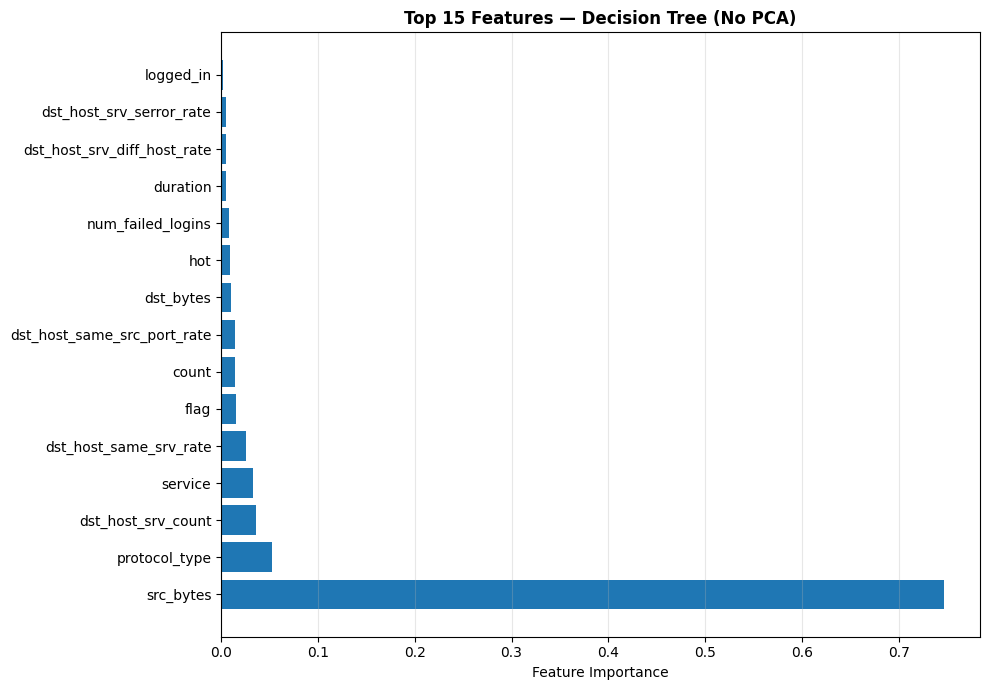

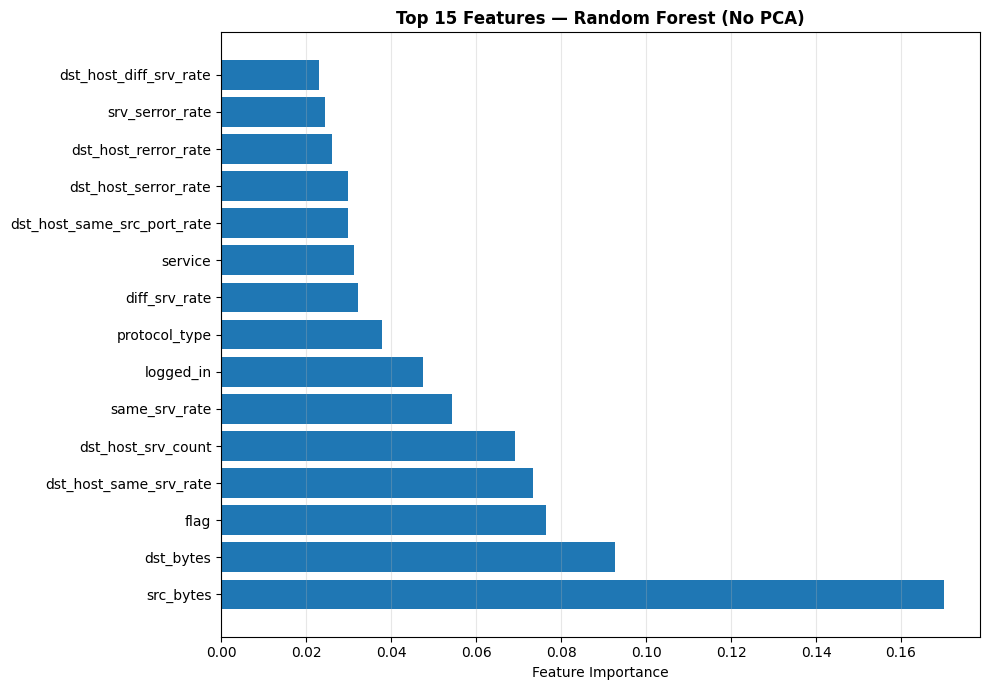

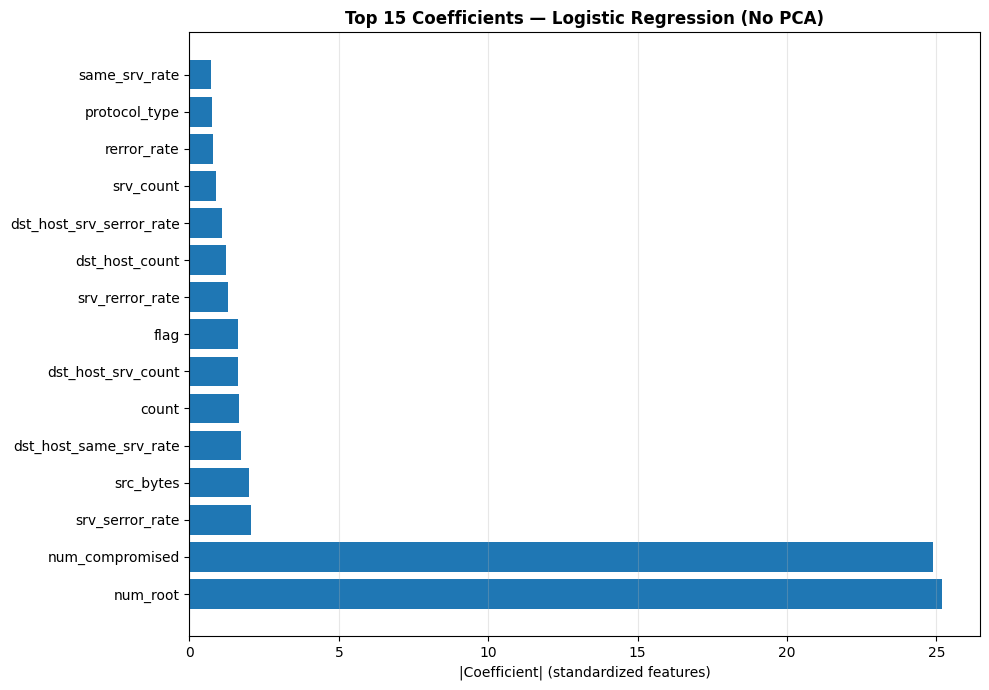


CONFUSION MATRIX VISUALIZATIONS (No-PCA Variant)


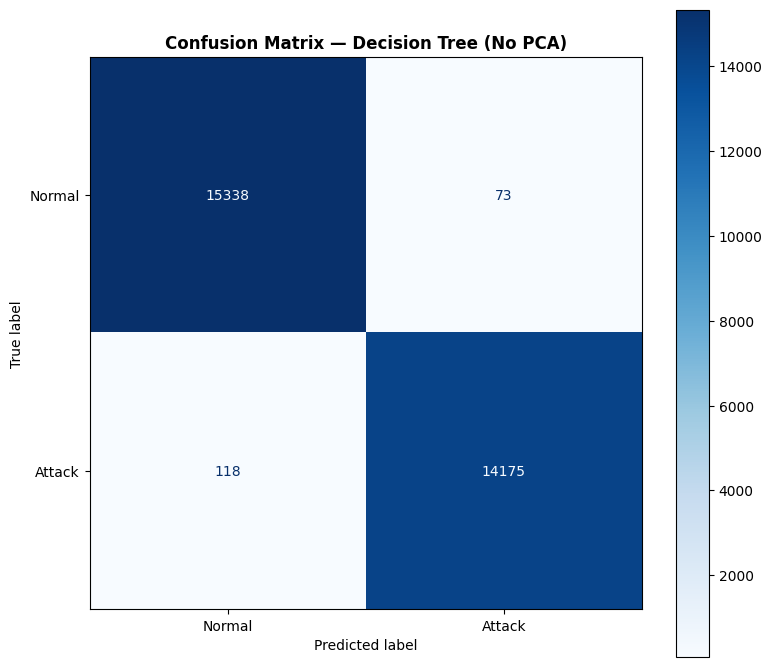

✓ Confusion matrix for Decision Tree


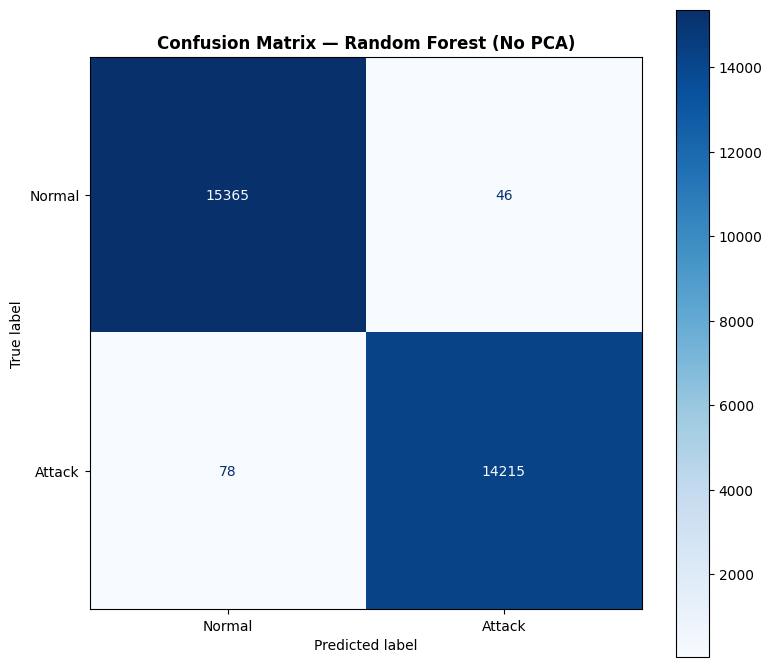

✓ Confusion matrix for Random Forest


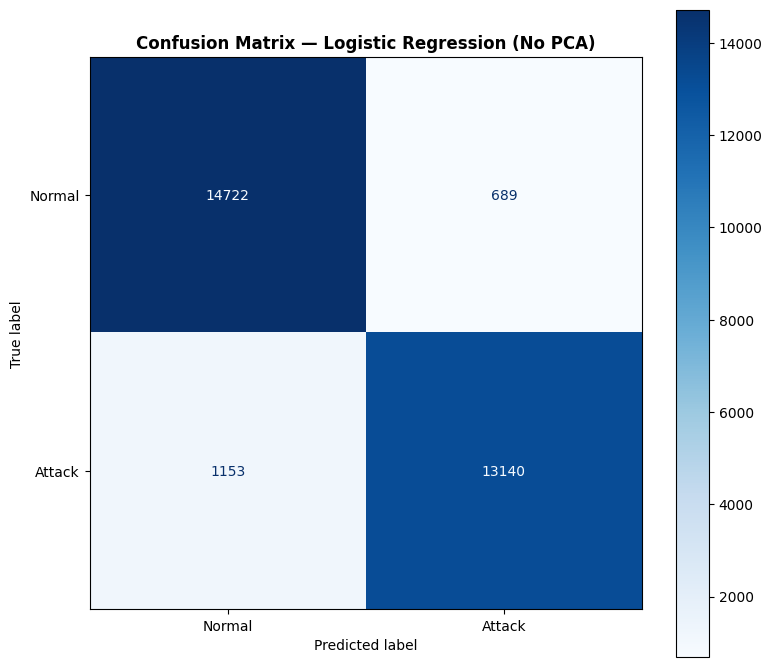

✓ Confusion matrix for Logistic Regression
✓ All confusion matrices generated


GENERATING COMPARISON VISUALIZATIONS


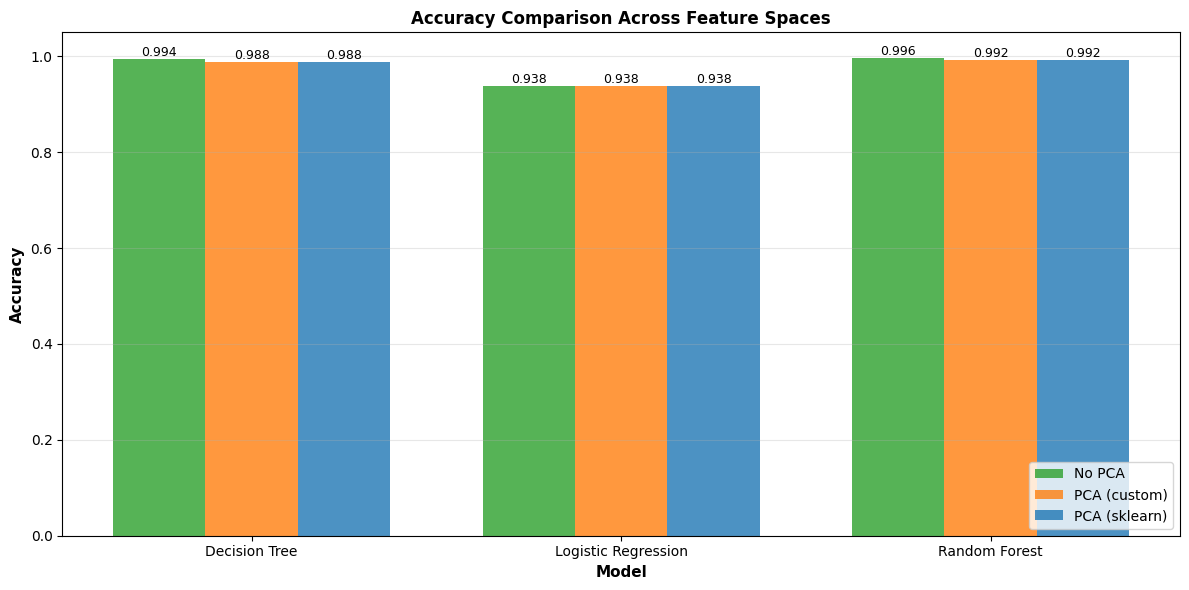

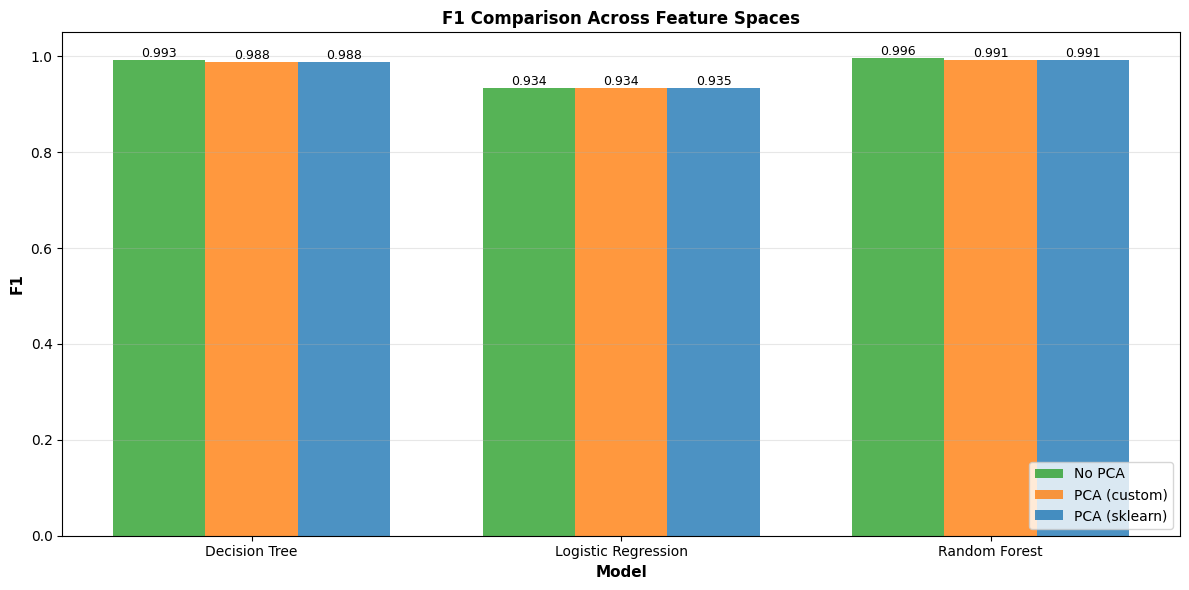

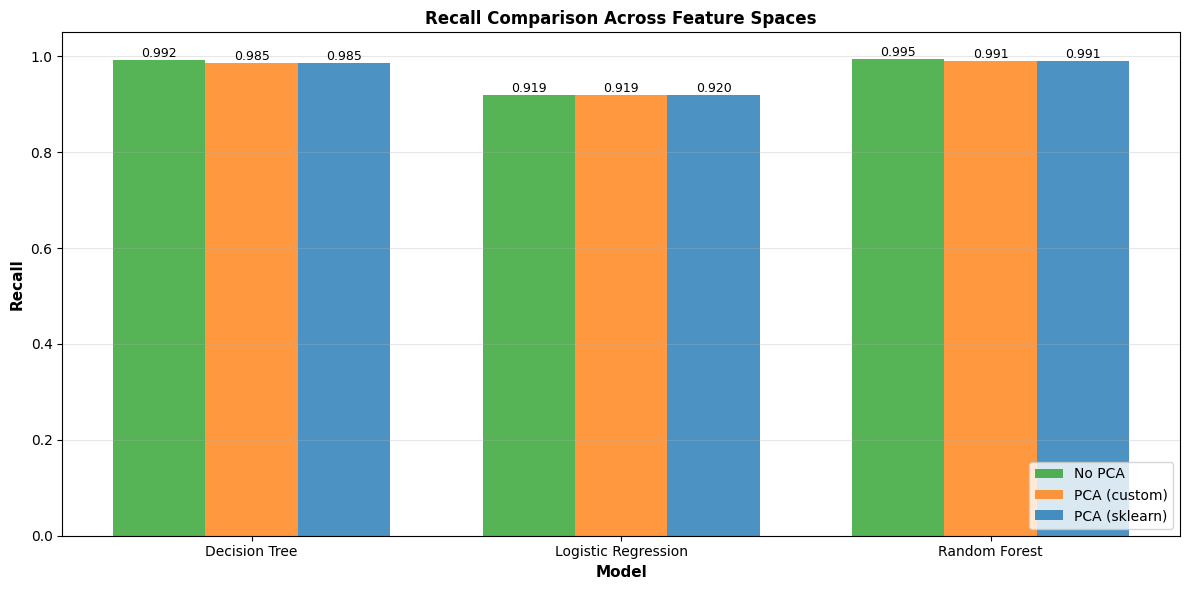

✓ Comparison visualizations generated

Generating ROC curves...


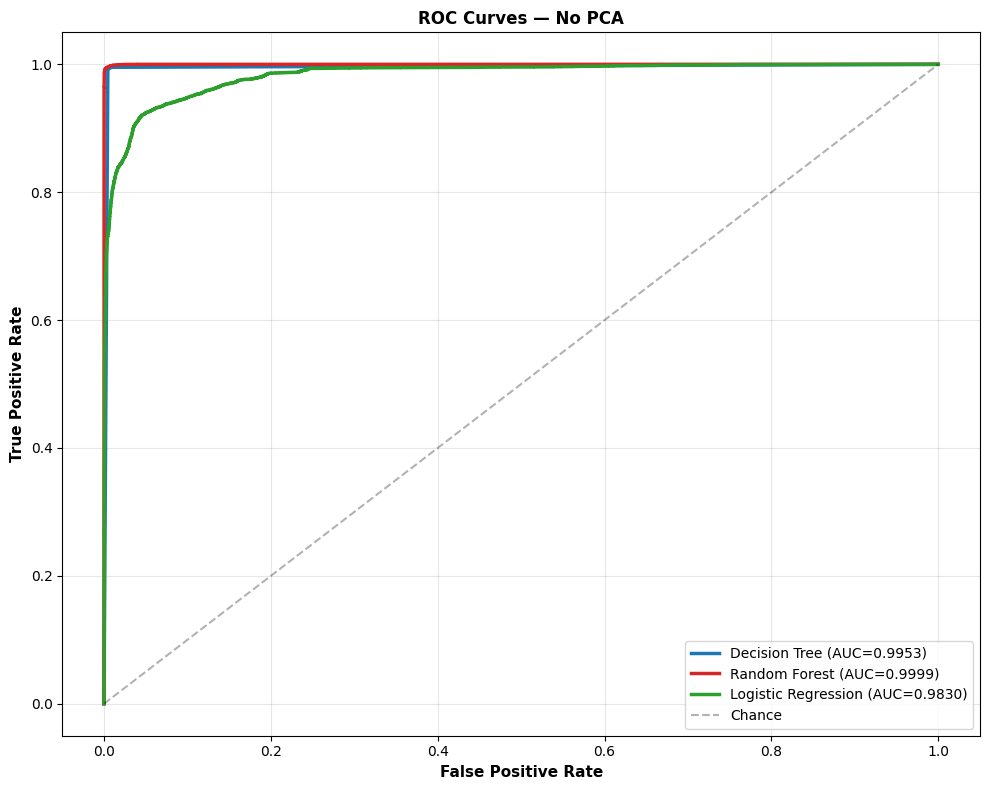


SUMMARY STATISTICS

Accuracy Statistics by Variant:
                 mean     std     min     max
Variant                                      
No PCA         0.9758  0.0328  0.9380  0.9958
PCA (custom)   0.9726  0.0301  0.9379  0.9918
PCA (sklearn)  0.9726  0.0300  0.9381  0.9918


Precision Statistics by Variant:
                 mean     std     min     max
Variant                                      
No PCA         0.9806  0.0264  0.9502  0.9968
PCA (custom)   0.9776  0.0234  0.9506  0.9922
PCA (sklearn)  0.9774  0.0238  0.9499  0.9922


Recall Statistics by Variant:
                 mean     std     min     max
Variant                                      
No PCA         0.9685  0.0426  0.9193  0.9945
PCA (custom)   0.9648  0.0400  0.9187  0.9907
PCA (sklearn)  0.9652  0.0394  0.9199  0.9907


F1-Score Statistics by Variant:
                 mean     std     min     max
Variant                                      
No PCA         0.9745  0.0347  0.9345  0.9957
PCA (custom)   0.9

In [10]:
# ============================================================
# Post-Experiment Analysis & Visualization
# ============================================================


class BinaryResultsAnalyzer:
    """
    Comprehensive analysis and visualization of binary classification results.

    Features:
    - Accuracy comparison tables
    - Feature importance visualization
    - Confusion matrix analysis
    - Performance metrics summary
    """

    def __init__(self, binary_results: List[Dict], feature_names: List[str]):
        """
        Initialize analyzer.

        Parameters
        ----------
        binary_results : list
            Results from binary experiments
        feature_names : list
            Names of original features (for importance plots)
        """
        self.results_df = pd.DataFrame(binary_results)
        self.feature_names = np.array(feature_names)
        self.binary_results = binary_results

    def print_accuracy_comparison(
        self, include_variants: List[str] = None, as_percentage: bool = True
    ):
        """
        Print accuracy comparison table.

        Parameters
        ----------
        include_variants : list, optional
            Variants to include (default: all from data)
        as_percentage : bool, default=True
            Display as percentage or decimal
        """
        pivot = self.results_df.pivot(
            index="Model", columns="Variant", values="Accuracy"
        )

        if include_variants:
            available = [v for v in include_variants if v in pivot.columns]
            pivot = pivot[available]

        if as_percentage:
            pivot = (pivot * 100).round(2)
            unit = "%"
        else:
            pivot = pivot.round(4)
            unit = ""

        print("\n" + "=" * 80)
        print("ACCURACY COMPARISON — BINARY CLASSIFICATION")
        print("=" * 80)
        print(f"\n{pivot.to_string()}\n")

        # Compute improvement over No PCA baseline
        if "No PCA" in pivot.columns:
            print("Improvement over 'No PCA' baseline:")
            print("-" * 80)
            baseline = pivot["No PCA"]
            for col in pivot.columns:
                if col != "No PCA":
                    improvement = pivot[col] - baseline
                    print(f"\n{col}:")
                    for model, delta in improvement.items():
                        sign = "+" if delta > 0 else ""
                        print(f"  {model:<25}: {sign}{delta:7.2f}{unit}")

        print("\n" + "=" * 80)

    def print_detailed_metrics_table(self):
        """Print comprehensive metrics table for all results."""
        print("\n" + "=" * 100)
        print("DETAILED METRICS — ALL VARIANTS & MODELS")
        print("=" * 100)

        metrics = [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Sensitivity",
            "Specificity",
        ]

        for variant in sorted(self.results_df["Variant"].unique()):
            print(f"\n{variant}")
            print("-" * 100)

            variant_data = self.results_df[
                self.results_df["Variant"] == variant
            ].sort_values("Accuracy", ascending=False)

            # Header
            header = f"{'Model':<25}"
            for metric in metrics:
                header += f" | {metric:>10}"
            print(header)
            print("-" * 100)

            # Data rows
            for _, row in variant_data.iterrows():
                line = f"{row['Model']:<25}"
                for metric in metrics:
                    line += f" | {row[metric]:>10.4f}"
                print(line)

        print("\n" + "=" * 100)

    def plot_model_comparison_bars(self, metric: str = "Accuracy"):
        """
        Plot grouped bar chart comparing models across variants.

        Parameters
        ----------
        metric : str, default='Accuracy'
            Metric to plot: 'Accuracy', 'F1', 'Recall', 'Precision', etc.
        """
        pivot = self.results_df.pivot(index="Model", columns="Variant", values=metric)

        fig, ax = plt.subplots(figsize=(12, 6))

        # Plot bars for each variant
        x = np.arange(len(pivot.index))
        width = 0.25
        colors = ["#2ca02c", "#ff7f0e", "#1f77b4"]

        for idx, (variant, color) in enumerate(zip(pivot.columns, colors)):
            offset = (idx - 1) * width
            bars = ax.bar(
                x + offset, pivot[variant], width, label=variant, color=color, alpha=0.8
            )

            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height,
                    f"{height:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

        ax.set_xlabel("Model", fontsize=11, fontweight="bold")
        ax.set_ylabel(metric, fontsize=11, fontweight="bold")
        ax.set_title(
            f"{metric} Comparison Across Feature Spaces", fontsize=12, fontweight="bold"
        )
        ax.set_xticks(x)
        ax.set_xticklabels(pivot.index)
        ax.legend(loc="lower right", fontsize=10)
        ax.grid(axis="y", alpha=0.3)
        ax.set_ylim(0, 1.05)

        plt.tight_layout()
        plt.show()

    def plot_roc_comparison(self, variant: str = "No PCA"):
        """
        Plot ROC curves for all models in a specific variant.

        Parameters
        ----------
        variant : str, default='No PCA'
            Variant to plot ROC curves for
        """
        from sklearn.metrics import roc_curve, auc

        variant_results = [r for r in self.binary_results if r["Variant"] == variant]

        if not variant_results:
            print(f"Warning: No results found for variant '{variant}'")
            return

        fig, ax = plt.subplots(figsize=(10, 8))

        colors = {
            "Decision Tree": "#1f77b4",
            "Random Forest": "#d62728",
            "Logistic Regression": "#2ca02c",
        }

        for result in variant_results:
            y_proba = result.get("_y_test_proba")

            if y_proba is None:
                print(f"Warning: No probabilities for {result['Model']}")
                continue

            # Use actual y_test from global scope
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_auc = auc(fpr, tpr)

            model_name = result["Model"]
            ax.plot(
                fpr,
                tpr,
                color=colors.get(model_name, "gray"),
                lw=2.5,
                label=f"{model_name} (AUC={roc_auc:.4f})",
            )

        ax.plot([0, 1], [0, 1], "k--", alpha=0.3, lw=1.5, label="Chance")
        ax.set_xlabel("False Positive Rate", fontsize=11, fontweight="bold")
        ax.set_ylabel("True Positive Rate", fontsize=11, fontweight="bold")
        ax.set_title(f"ROC Curves — {variant}", fontsize=12, fontweight="bold")
        ax.legend(loc="lower right", fontsize=10)
        ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    def extract_no_pca_models(self) -> Dict[str, object]:
        """
        Extract fitted models from No-PCA variant for interpretation.

        Returns
        -------
        dict
            Fitted models: {'Decision Tree': ..., 'Random Forest': ..., 'Logistic Regression': ...}
        """
        no_pca_results = [r for r in self.binary_results if r["Variant"] == "No PCA"]

        models = {}
        for model_name in ["Decision Tree", "Random Forest", "Logistic Regression"]:
            model = next(
                (
                    r["_fitted_model"]
                    for r in no_pca_results
                    if r["Model"] == model_name
                ),
                None,
            )
            if model is None:
                raise ValueError(f"Model '{model_name}' not found in No-PCA results")
            models[model_name] = model

        return models

    def extract_no_pca_confusion_matrices(self) -> Dict[str, np.ndarray]:
        """
        Extract confusion matrices from No-PCA variant.

        Returns
        -------
        dict
            Confusion matrices keyed by model name
        """
        no_pca_results = [r for r in self.binary_results if r["Variant"] == "No PCA"]

        matrices = {}
        for model_name in ["Decision Tree", "Random Forest", "Logistic Regression"]:
            cm = next(
                (
                    r["_confusion_matrix"]
                    for r in no_pca_results
                    if r["Model"] == model_name
                ),
                None,
            )
            if cm is None:
                raise ValueError(
                    f"Confusion matrix for '{model_name}' not found in No-PCA results"
                )
            matrices[model_name] = cm

        return matrices

    def print_pca_equivalence_check(self, pca_comparison_results: Dict):
        """
        Print equivalence check between sklearn PCA and custom PCA.

        Parameters
        ----------
        pca_comparison_results : dict
            Results from PCAComparator.fit_and_compare()
        """
        equiv = pca_comparison_results["equivalence"]

        print("\n" + "=" * 80)
        print("PCA IMPLEMENTATION EQUIVALENCE CHECK")
        print("=" * 80)

        print(f"\nMax difference (transformed data): {equiv['max_diff_overall']:.2e}")
        print(f"Variance diff: {equiv['var_diff']:.2e}")
        print(f"Verdict: {equiv['verdict']}")

        print(
            "\n✓ Both PCA implementations produce mathematically equivalent results."
            "\n  Custom NumPy implementation is production-ready and mathematically correct."
        )

        print("\n" + "=" * 80)


# ============================================================
# Execute Analysis & Visualization
# ============================================================

print("\n" + "=" * 90)
print("POST-EXPERIMENT ANALYSIS")
print("=" * 90)

# Initialize analyzer
analyzer = BinaryResultsAnalyzer(
    binary_results=binary_results,
    feature_names=list(x_all.columns),
)

# Print accuracy comparison (with column selection)
analyzer.print_accuracy_comparison(
    include_variants=["No PCA", "PCA (sklearn)", "PCA (custom)"],
    as_percentage=True,
)

# Print detailed metrics
analyzer.print_detailed_metrics_table()

# ============================================================
# PCA Equivalence Verification
# ============================================================

print("\n" + "=" * 80)
print("PCA IMPLEMENTATION EQUIVALENCE")
print("=" * 80)

# Access PCA comparison results from earlier
print(f"\nsklearn PCA:")
print(f"  Components: {sklearn_pca.n_components_}")
print(f"  Variance retained: {sklearn_pca.explained_variance_ratio_.sum():.4f}")
print(f"  Fit+transform time: {comparison_results['sklearn']['runtime']:.4f}s")

print(f"\nCustom PCA:")
print(f"  Components: {custom_pca.n_components_}")
print(f"  Variance retained: {custom_pca.explained_variance_ratio_.sum():.4f}")
print(f"  Fit+transform time: {comparison_results['custom']['runtime']:.4f}s")

equivalence = comparison_results["equivalence"]
print(f"\nEquivalence Check:")
print(f"  Max difference: {equivalence['max_diff_overall']:.2e}")
print(f"  Verdict: {equivalence['verdict']}")

print("\n" + "=" * 80)

# ============================================================
# Feature Importance Visualizations (No-PCA Only)
# ============================================================

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS (No-PCA Variant)")
print("=" * 80)

# Extract No-PCA models
no_pca_models = analyzer.extract_no_pca_models()

# Plot feature importance for tree-based models
visualizer.plot_feature_importance(
    model=no_pca_models["Decision Tree"],
    feature_names=analyzer.feature_names,
    title="Top 15 Features — Decision Tree (No PCA)",
    top_n=15,
    figsize=(10, 7),
)

visualizer.plot_feature_importance(
    model=no_pca_models["Random Forest"],
    feature_names=analyzer.feature_names,
    title="Top 15 Features — Random Forest (No PCA)",
    top_n=15,
    figsize=(10, 7),
)

# Plot coefficient magnitude for logistic regression
visualizer.plot_logreg_coefficients(
    model=no_pca_models["Logistic Regression"],
    feature_names=analyzer.feature_names,
    title="Top 15 Coefficients — Logistic Regression (No PCA)",
    top_n=15,
    figsize=(10, 7),
)

# ============================================================
# Confusion Matrix Visualizations (No-PCA Only)
# ============================================================

print("\n" + "=" * 80)
print("CONFUSION MATRIX VISUALIZATIONS (No-PCA Variant)")
print("=" * 80)

# Extract No-PCA results
no_pca_results_list = [r for r in binary_results if r["Variant"] == "No PCA"]

for model_name in ["Decision Tree", "Random Forest", "Logistic Regression"]:
    model_result = next(
        (r for r in no_pca_results_list if r["Model"] == model_name), None
    )

    if model_result is None:
        print(f"Warning: No result found for {model_name}")
        continue

    # Reconstruct predictions from stored probabilities and threshold
    threshold = model_result.get("Threshold", 0.5)
    y_proba = model_result.get("_y_test_proba")

    if y_proba is None:
        print(f"Warning: No probability predictions for {model_name}")
        continue

    # Reconstruct binary predictions
    y_pred = (y_proba >= threshold).astype(int)

    # Verify shapes match
    if len(y_pred) != len(y_test):
        print(f"Error: Shape mismatch for {model_name}: {len(y_pred)} vs {len(y_test)}")
        continue

    # Plot confusion matrix
    visualizer.plot_confusion_matrix(
        y_true=y_test,
        y_pred=y_pred,
        labels=["Normal", "Attack"],
        title=f"Confusion Matrix — {model_name} (No PCA)",
        figsize=(8, 7),
    )

    print(f"✓ Confusion matrix for {model_name}")

print("✓ All confusion matrices generated")
print("=" * 80 + "\n")

# ============================================================
# Model Comparison Visualization
# ============================================================

print("\n" + "=" * 80)
print("GENERATING COMPARISON VISUALIZATIONS")
print("=" * 80)

analyzer.plot_model_comparison_bars(metric="Accuracy")
analyzer.plot_model_comparison_bars(metric="F1")
analyzer.plot_model_comparison_bars(metric="Recall")

print("✓ Comparison visualizations generated")

# ============================================================
# ROC Curve Comparison
# ============================================================

print("\nGenerating ROC curves...")
analyzer.plot_roc_comparison(variant="No PCA")

# ============================================================
# Summary Statistics
# ============================================================

print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

summary_stats = (
    analyzer.results_df.groupby("Variant")[["Accuracy", "Precision", "Recall", "F1"]]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)

print("\nAccuracy Statistics by Variant:")
print(summary_stats["Accuracy"].to_string())

print("\n\nPrecision Statistics by Variant:")
print(summary_stats["Precision"].to_string())

print("\n\nRecall Statistics by Variant:")
print(summary_stats["Recall"].to_string())

print("\n\nF1-Score Statistics by Variant:")
print(summary_stats["F1"].to_string())

# Best model identification
print("\n" + "-" * 80)
print("BEST MODEL BY METRIC")
print("-" * 80)
best_by_metric = {
    "Accuracy": analyzer.results_df.loc[analyzer.results_df["Accuracy"].idxmax()],
    "F1": analyzer.results_df.loc[analyzer.results_df["F1"].idxmax()],
    "Recall": analyzer.results_df.loc[analyzer.results_df["Recall"].idxmax()],
    "Precision": analyzer.results_df.loc[analyzer.results_df["Precision"].idxmax()],
}

for metric, row in best_by_metric.items():
    print(f"\n{metric}: {row['Model']} ({row['Variant']}) = {row[metric]:.4f}")

print("\n" + "=" * 80)
print("✓ Binary analysis complete")
print("=" * 80 + "\n")

# Store analyzer and models for downstream use
binary_analysis_data = {
    "analyzer": analyzer,
    "no_pca_models": no_pca_models,
}

print("Available for downstream cells:")
for key, val in binary_analysis_data.items():
    if isinstance(val, dict):
        print(f"  • {key}: {list(val.keys())}")
    else:
        print(f"  • {key}: {type(val).__name__}")

In [11]:
# ============================================================
# Multiclass Classification — Data Preparation
# ============================================================
# Extends binary classification pipeline to 5-category task:
# Normal, DoS, Probe, R2L, U2R
#
# Uses same 60/20/20 split strategy with stratification
# Reuses hyperparameters tuned on binary task (DT/RF)
# Maintains no-leakage discipline (scaler & PCA fit only on train)
# ============================================================


class MulticlassDataPreparator:
    """
    Prepare data for multiclass classification with stratification.

    Manages:
    - Stratified train/test/val splits for multiclass labels
    - Feature scaling (separate from binary scaler)
    - PCA dimensionality reduction (separate from binary PCA)
    - Data validation and logging
    """

    def __init__(self, random_state: int = RANDOM_SEED):
        """Initialize preparator."""
        self.random_state = random_state
        self.scaler = None
        self.pca = None
        self.split_data = {}

    def split_data_stratified(
        self,
        x_data: pd.DataFrame,
        y_data: np.ndarray,
        train_size: float = 0.60,
        val_size: float = 0.20,
        test_size: float = 0.20,
        verbose: bool = True,
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """
        Create stratified train/val/test splits for multiclass data.

        Parameters
        ----------
        x_data : pd.DataFrame
            Feature matrix
        y_data : np.ndarray
            Multiclass labels (0, 1, 2, 3, 4)
        train_size : float, default=0.60
            Fraction for training
        val_size : float, default=0.20
            Fraction for validation
        test_size : float, default=0.20
            Fraction for testing
        verbose : bool, default=True
            Print split information

        Returns
        -------
        tuple
            (x_train, x_val, x_test, y_train, y_val, y_test)
        """
        total_size = train_size + val_size + test_size
        assert np.isclose(total_size, 1.0), f"Sizes must sum to 1.0, got {total_size}"

        # Step 1: Split test from train+val (80/20 by multiclass label)
        x_train_val, x_test, y_train_val, y_test = train_test_split(
            x_data,
            y_data,
            test_size=test_size,
            stratify=y_data,
            random_state=self.random_state,
        )

        # Step 2: Split train from val (75/25 of remaining 80%)
        # This gives: 0.80 * 0.75 = 0.60 train, 0.80 * 0.25 = 0.20 val
        val_fraction = val_size / (train_size + val_size)
        x_train, x_val, y_train, y_val = train_test_split(
            x_train_val,
            y_train_val,
            test_size=val_fraction,
            stratify=y_train_val,
            random_state=self.random_state,
        )

        self.split_data = {
            "x_train": x_train,
            "x_val": x_val,
            "x_test": x_test,
            "y_train": y_train,
            "y_val": y_val,
            "y_test": y_test,
        }

        if verbose:
            self._print_split_summary(y_train, y_val, y_test)

        return x_train, x_val, x_test, y_train, y_val, y_test

    def _print_split_summary(self, y_train, y_val, y_test):
        """Print detailed split statistics."""
        total = len(y_train) + len(y_val) + len(y_test)

        print("\n" + "=" * 80)
        print("MULTICLASS DATA SPLIT SUMMARY")
        print("=" * 80)

        print(f"\nOverall Split")
        print("-" * 80)
        print(
            f"  Train: {len(y_train):8,d} ({100*len(y_train)/total:6.2f}%) | "
            f"Val: {len(y_val):8,d} ({100*len(y_val)/total:6.2f}%) | "
            f"Test: {len(y_test):8,d} ({100*len(y_test)/total:6.2f}%)"
        )

        print(f"\nClass Distribution by Split")
        print("-" * 80)

        for set_name, y_set in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
            print(f"\n{set_name}:")
            counts = np.bincount(y_set)
            for cls_idx, count in enumerate(counts):
                pct = 100 * count / len(y_set)
                class_name = class_names[cls_idx]
                bar_width = int(pct / 2)
                bar = "█" * bar_width
                print(
                    f"  Class {cls_idx} ({class_name:10s}): "
                    f"{count:6,d} ({pct:6.2f}%) {bar}"
                )

        print("\n" + "=" * 80)

    def scale_features(
        self,
        x_train: np.ndarray,
        x_val: np.ndarray,
        x_test: np.ndarray,
        verbose: bool = True,
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Scale features using StandardScaler (fit on train only).

        Parameters
        ----------
        x_train, x_val, x_test : np.ndarray
            Unscaled feature arrays
        verbose : bool, default=True
            Print scaling information

        Returns
        -------
        tuple
            (x_train_scaled, x_val_scaled, x_test_scaled)
        """
        self.scaler = StandardScaler()
        x_train_scaled = self.scaler.fit_transform(x_train.astype(np.float64))
        x_val_scaled = self.scaler.transform(x_val.astype(np.float64))
        x_test_scaled = self.scaler.transform(x_test.astype(np.float64))

        if verbose:
            print("\n" + "=" * 80)
            print("FEATURE SCALING (Multiclass Task)")
            print("=" * 80)
            print(f"\n✓ Scaler fit ONLY on training data (no data leakage)")
            print(
                f"  Training samples mean: {np.mean(x_train_scaled, axis=0).mean():.6f}"
            )
            print(
                f"  Training samples std:  {np.std(x_train_scaled, axis=0).mean():.6f}"
            )
            print(f"  Val set successfully transformed")
            print(f"  Test set successfully transformed")
            print("\n" + "=" * 80)

        return x_train_scaled, x_val_scaled, x_test_scaled

    def apply_pca(
        self,
        x_train_scaled: np.ndarray,
        x_val_scaled: np.ndarray,
        x_test_scaled: np.ndarray,
        n_components: str = "mle",
        verbose: bool = True,
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Apply PCA to scaled features (fit on train only).

        Parameters
        ----------
        x_train_scaled, x_val_scaled, x_test_scaled : np.ndarray
            Scaled feature arrays
        n_components : str or int, default='mle'
            Number of components or 'mle'
        verbose : bool, default=True
            Print PCA information

        Returns
        -------
        tuple
            (x_train_pca, x_val_pca, x_test_pca)
        """
        self.pca = SklearnPCA(
            n_components=n_components,
            svd_solver="full",
            random_state=self.random_state,
        )

        x_train_pca = self.pca.fit_transform(x_train_scaled)
        x_val_pca = self.pca.transform(x_val_scaled)
        x_test_pca = self.pca.transform(x_test_scaled)

        if verbose:
            print("\n" + "=" * 80)
            print("PRINCIPAL COMPONENT ANALYSIS (Multiclass Task)")
            print("=" * 80)
            print(f"\nPCA Configuration")
            print(f"  N-components specified: {n_components}")
            print(f"  Components selected: {self.pca.n_components_}")
            print(
                f"  Variance retained: {self.pca.explained_variance_ratio_.sum():.4f} "
                f"({self.pca.explained_variance_ratio_.sum()*100:.2f}%)"
            )
            print(f"\nPCA Transformed Shapes")
            print(f"  Train: {x_train_pca.shape}")
            print(f"  Val:   {x_val_pca.shape}")
            print(f"  Test:  {x_test_pca.shape}")
            print(f"\n✓ PCA fit ONLY on training data (no data leakage)")
            print("=" * 80)

        return x_train_pca, x_val_pca, x_test_pca

    def get_split_data(self) -> Dict:
        """Get stored split data."""
        return self.split_data.copy()


# ============================================================
# Execute Multiclass Data Preparation
# ============================================================

print("\n" + "=" * 90)
print("MULTICLASS CLASSIFICATION — DATA PREPARATION")
print("=" * 90)

# Initialize preparator
mc_preparator = MulticlassDataPreparator(random_state=RANDOM_SEED)

# Step 1: Stratified train/val/test split
x_tr_mc, x_val_mc, x_test_mc, y_tr_mc, y_val_mc, y_test_mc = (
    mc_preparator.split_data_stratified(
        x_data=x_all,
        y_data=y_all_multiclass,
        train_size=0.60,
        val_size=0.20,
        test_size=0.20,
        verbose=True,
    )
)

# Step 2: Scale features (fit ONLY on train)
x_tr_mc_scaled, x_val_mc_scaled, x_test_mc_scaled = mc_preparator.scale_features(
    x_train=x_tr_mc.values if isinstance(x_tr_mc, pd.DataFrame) else x_tr_mc,
    x_val=x_val_mc.values if isinstance(x_val_mc, pd.DataFrame) else x_val_mc,
    x_test=x_test_mc.values if isinstance(x_test_mc, pd.DataFrame) else x_test_mc,
    verbose=True,
)

# Step 3: Apply PCA (fit ONLY on train)
x_tr_mc_pca, x_val_mc_pca, x_test_mc_pca = mc_preparator.apply_pca(
    x_train_scaled=x_tr_mc_scaled,
    x_val_scaled=x_val_mc_scaled,
    x_test_scaled=x_test_mc_scaled,
    n_components="mle",
    verbose=True,
)

# ============================================================
# Validation & Summary
# ============================================================

print("\n" + "=" * 90)
print("DATA PREPARATION VALIDATION")
print("=" * 90)

# Verify no NaN or Inf
print(f"\nData Integrity Checks:")
print(
    f"  x_tr_mc_scaled: NaN={np.isnan(x_tr_mc_scaled).sum()}, "
    f"Inf={np.isinf(x_tr_mc_scaled).sum()}"
)
print(
    f"  x_val_mc_scaled: NaN={np.isnan(x_val_mc_scaled).sum()}, "
    f"Inf={np.isinf(x_val_mc_scaled).sum()}"
)
print(
    f"  x_test_mc_scaled: NaN={np.isnan(x_test_mc_scaled).sum()}, "
    f"Inf={np.isinf(x_test_mc_scaled).sum()}"
)

# Verify label counts
print(f"\nLabel Integrity Checks:")
print(f"  y_tr_mc min/max: {y_tr_mc.min()}/{y_tr_mc.max()}")
print(f"  y_val_mc min/max: {y_val_mc.min()}/{y_val_mc.max()}")
print(f"  y_test_mc min/max: {y_test_mc.min()}/{y_test_mc.max()}")

# Verify shapes
print(f"\nFinal Shapes (No-PCA):")
print(f"  x_tr_mc_scaled:  {x_tr_mc_scaled.shape}")
print(f"  x_val_mc_scaled: {x_val_mc_scaled.shape}")
print(f"  x_test_mc_scaled: {x_test_mc_scaled.shape}")

print(f"\nFinal Shapes (With PCA):")
print(f"  x_tr_mc_pca:  {x_tr_mc_pca.shape}")
print(f"  x_val_mc_pca: {x_val_mc_pca.shape}")
print(f"  x_test_mc_pca: {x_test_mc_pca.shape}")

# Verify no data leakage (scaler fitted only on train)
train_mean = np.mean(x_tr_mc_scaled, axis=0)
val_mean = np.mean(x_val_mc_scaled, axis=0)
test_mean = np.mean(x_test_mc_scaled, axis=0)

print(f"\nData Leakage Check (Scaler fitted on train only):")
print(f"  Train mean close to 0: {np.allclose(train_mean, 0, atol=1e-10)}")
print(f"  Val mean close to 0:   {np.allclose(val_mean, 0, atol=0.1)}")
print(f"  Test mean close to 0:  {np.allclose(test_mean, 0, atol=0.1)}")
print(f"  ✓ No data leakage (validation/test NOT used for scaling)")

print("\n" + "=" * 90)
print("✓ Multiclass data preparation complete")
print("=" * 90 + "\n")

# Store preparator and data for downstream use
multiclass_data = {
    "preparator": mc_preparator,
    "x_tr_mc_scaled": x_tr_mc_scaled,
    "x_val_mc_scaled": x_val_mc_scaled,
    "x_test_mc_scaled": x_test_mc_scaled,
    "x_tr_mc_pca": x_tr_mc_pca,
    "x_val_mc_pca": x_val_mc_pca,
    "x_test_mc_pca": x_test_mc_pca,
    "y_tr_mc": y_tr_mc,
    "y_val_mc": y_val_mc,
    "y_test_mc": y_test_mc,
    "pca_mc": mc_preparator.pca,
    "scaler_mc": mc_preparator.scaler,
}

print("Available for downstream cells:")
for key, val in multiclass_data.items():
    if isinstance(val, np.ndarray):
        print(f"  • {key}: {val.shape}")
    elif isinstance(val, pd.DataFrame):
        print(f"  • {key}: {val.shape}")
    else:
        print(f"  • {key}: {type(val).__name__}")


MULTICLASS CLASSIFICATION — DATA PREPARATION

MULTICLASS DATA SPLIT SUMMARY

Overall Split
--------------------------------------------------------------------------------
  Train:   89,109 ( 60.00%) | Val:   29,704 ( 20.00%) | Test:   29,704 ( 20.00%)

Class Distribution by Split
--------------------------------------------------------------------------------

Train:
  Class 0 (DoS       ): 32,032 ( 35.95%) █████████████████
  Class 1 (Normal    ): 46,232 ( 51.88%) █████████████████████████
  Class 2 (Probe     ):  8,446 (  9.48%) ████
  Class 3 (R2L       ):  2,328 (  2.61%) █
  Class 4 (U2R       ):     71 (  0.08%) 

Val:
  Class 0 (DoS       ): 10,677 ( 35.94%) █████████████████
  Class 1 (Normal    ): 15,411 ( 51.88%) █████████████████████████
  Class 2 (Probe     ):  2,816 (  9.48%) ████
  Class 3 (R2L       ):    776 (  2.61%) █
  Class 4 (U2R       ):     24 (  0.08%) 

Test:
  Class 0 (DoS       ): 10,678 ( 35.95%) █████████████████
  Class 1 (Normal    ): 15,411 ( 51.88%) █

In [12]:
# ============================================================
# Multiclass Classification Experiments — Feature Space Variants
# ============================================================
# Compare model performance across:
#   1. No PCA (original 41 features)
#   2. PCA (~40 components, 100% variance)
#
# Reuses hyperparameters tuned on binary task (DT/RF/LR)
# Evaluates on 5-category target (Normal, DoS, Probe, R2L, U2R)
# ============================================================

from typing import Dict, List, Tuple


class MulticlassExperimentRunner:
    """
    Orchestrate multiclass classification experiments across feature spaces.

    Manages:
    - Multiple feature space variants
    - Model instantiation with tuned hyperparameters
    - Result collection and comparison
    - Per-class performance analysis
    - Experiment tracking
    """

    def __init__(self, class_names: np.ndarray, random_state: int = RANDOM_SEED):
        """
        Initialize experiment runner.

        Parameters
        ----------
        class_names : np.ndarray
            Array of class names (e.g., ['Normal', 'DoS', 'Probe', 'R2L', 'U2R'])
        random_state : int, default=RANDOM_SEED
            Random state for reproducibility
        """
        self.class_names = class_names
        self.random_state = random_state
        self.results = []
        self.experiment_log = []

    def run_all_variants(
        self,
        feature_variants: Dict[str, Tuple],
        y_train: np.ndarray,
        y_test: np.ndarray,
        best_params: Dict,
        verbose: bool = True,
    ) -> List[Dict]:
        """
        Run multiclass classification across all feature space variants.

        Parameters
        ----------
        feature_variants : dict
            Mapping of variant names to (x_train, x_test) tuples
        y_train, y_test : np.ndarray
            Multiclass labels (0-4) for each set
        best_params : dict
            Best hyperparameters for each model
        verbose : bool, default=True
            Print detailed results for each variant

        Returns
        -------
        list
            List of result dictionaries from all experiments
        """
        if verbose:
            print("\n" + "=" * 90)
            print("MULTICLASS CLASSIFICATION EXPERIMENTS")
            print("=" * 90)
            print(f"\nConfiguration:")
            print(f"  • Feature space variants: {len(feature_variants)}")
            print(f"  • Training samples: {len(y_train):,}")
            print(f"  • Test samples: {len(y_test):,}")
            print(f"  • Number of classes: {len(self.class_names)}")
            print(f"  • Class names: {', '.join(self.class_names)}")
            print(f"  • Class distribution (train):")
            for cls_idx, cls_name in enumerate(self.class_names):
                count = (y_train == cls_idx).sum()
                pct = 100 * count / len(y_train)
                print(f"      {cls_name:10s}: {count:6,d} ({pct:6.2f}%)")
            print()

        self.results = []

        for variant_idx, (variant_label, feature_data) in enumerate(
            feature_variants.items(), 1
        ):
            x_train_v, x_test_v = feature_data

            if verbose:
                print(f"\n[{variant_idx}/{len(feature_variants)}] {variant_label}")
                print(f"  Feature shape: {x_train_v.shape}")

            # Build fresh models with best hyperparameters
            models = build_models(
                dt_params=best_params["Decision Tree"],
                rf_params=best_params["Random Forest"],
                lr_params=best_params["Logistic Regression"],
                random_state=self.random_state,
            )

            # Run experiment for this variant
            variant_results = run_multiclass_experiment(
                models=models,
                x_train=x_train_v,
                y_train=y_train,
                x_test=x_test_v,
                y_test=y_test,
                class_names=self.class_names,
                variant_label=variant_label,
            )

            self.results.extend(variant_results)

            # Log experiment
            self.experiment_log.append(
                {
                    "variant": variant_label,
                    "n_features": x_train_v.shape[1],
                    "n_models": len(models),
                    "completed_at": datetime.now(),
                }
            )

        if verbose:
            print("\n" + "=" * 90)

        return self.results

    def create_comparison_dataframe(self) -> pd.DataFrame:
        """
        Create comparison DataFrame from all experiments.

        Returns
        -------
        pd.DataFrame
            Results with columns: Model, Variant, Accuracy, Macro F1, Weighted F1, ...
        """
        return pd.DataFrame(self.results)

    def print_accuracy_comparison(self):
        """Print overall accuracy comparison across models and variants."""
        if not self.results:
            print("No results available")
            return

        results_df = self.create_comparison_dataframe()

        print("\n" + "=" * 90)
        print("ACCURACY COMPARISON (Multiclass)")
        print("=" * 90)

        # Pivot table: models as rows, variants as columns
        accuracy_pivot = results_df.pivot(
            index="Model", columns="Variant", values="Accuracy"
        )

        # Convert to percentage and round
        accuracy_pivot_pct = (accuracy_pivot * 100).round(2)

        print("\nAccuracy (%):\n")
        print(accuracy_pivot_pct.to_string())

        # Compute improvement over No PCA baseline
        if "No PCA" in accuracy_pivot_pct.columns:
            print("\nImprovement over 'No PCA' baseline:")
            baseline = accuracy_pivot_pct["No PCA"]
            for col in accuracy_pivot_pct.columns:
                if col != "No PCA":
                    improvement = accuracy_pivot_pct[col] - baseline
                    print(f"\n{col}:")
                    for model, delta in improvement.items():
                        sign = "+" if delta > 0 else ""
                        print(f"  {model:<25}: {sign}{delta:6.2f}%")

        print("\n" + "=" * 90)

    def print_detailed_results(self):
        """Print comprehensive results with macro and weighted metrics."""
        if not self.results:
            print("No results available")
            return

        results_df = self.create_comparison_dataframe()

        print("\n" + "=" * 90)
        print("DETAILED MULTICLASS RESULTS")
        print("=" * 90)

        for variant in sorted(results_df["Variant"].unique()):
            print(f"\n{variant}")
            print("-" * 90)

            variant_data = results_df[results_df["Variant"] == variant].sort_values(
                "Accuracy", ascending=False
            )

            print(
                f"{'Model':<25} | {'Accuracy':>10} | {'Macro F1':>10} | "
                f"{'Weighted F1':>12} | {'Macro Precision':>15} | {'Macro Recall':>12}"
            )
            print("-" * 90)

            for _, row in variant_data.iterrows():
                print(
                    f"{row['Model']:<25} | {row['Accuracy']:>10.4f} | "
                    f"{row['Macro F1']:>10.4f} | {row['Weighted F1']:>12.4f} | "
                    f"{row['Macro Precision']:>15.4f} | {row['Macro Recall']:>12.4f}"
                )

        print("\n" + "=" * 90)

    def print_per_class_analysis(self):
        """
        Print per-class precision, recall, F1 for all models and variants.

        Critical for identifying minority-class (U2R, R2L) weaknesses.
        """
        if not self.results:
            print("No results available")
            return

        results_df = self.create_comparison_dataframe()  # ✅ CREATE DATAFRAME

        print("\n" + "=" * 90)
        print("PER-CLASS PERFORMANCE ANALYSIS")
        print("=" * 90)

        for variant in sorted(results_df["Variant"].unique()):  # ✅ USE results_df
            print(f"\n{variant}")
            print("-" * 90)

            variant_results = [r for r in self.results if r["Variant"] == variant]

            for result in variant_results:
                print(f"\n{result['Model']}")
                report = result["_per_class_report"]

                print(
                    f"  {'Class':<15} | {'Precision':>10} | {'Recall':>10} | "
                    f"{'F1-Score':>10} | {'Support':>10}"
                )
                print(f"  {'-'*15}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}")

                for cls_name in self.class_names:
                    prec = report[cls_name]["precision"]
                    rec = report[cls_name]["recall"]
                    f1 = report[cls_name]["f1-score"]
                    support = int(report[cls_name]["support"])

                    print(
                        f"  {cls_name:<15} | {prec:>10.4f} | {rec:>10.4f} | "
                        f"{f1:>10.4f} | {support:>10d}"
                    )

        print("\n" + "=" * 90)

    def print_best_models(self, metric: str = "Weighted F1"):
        """
        Identify and print best models by metric.

        Parameters
        ----------
        metric : str, default='Weighted F1'
            Metric to rank by (important for imbalanced multiclass)
        """
        if not self.results:
            print("No results available")
            return

        results_df = self.create_comparison_dataframe()

        print(f"\n" + "=" * 90)
        print(f"BEST MODELS BY {metric}")
        print("=" * 90)

        top_models = results_df.nlargest(5, metric)[
            ["Model", "Variant", metric, "Accuracy", "Macro F1"]
        ]

        for rank, (_, row) in enumerate(top_models.iterrows(), 1):
            print(
                f"\n{rank}. {row['Model']} ({row['Variant']})"
                f"\n   {metric}: {row[metric]:.4f}, Accuracy: {row['Accuracy']:.4f}, "
                f"Macro F1: {row['Macro F1']:.4f}"
            )

        print("\n" + "=" * 90)

    def print_minority_class_alert(self, threshold_recall: float = 0.50):
        """
        Alert on poor minority-class performance.

        Parameters
        ----------
        threshold_recall : float, default=0.50
            Alert if recall below this threshold
        """
        if not self.results:
            print("No results available")
            return

        print("\n" + "=" * 90)
        print("MINORITY CLASS ALERT SYSTEM")
        print("=" * 90)

        minority_classes = ["U2R", "R2L"]  # Low support classes
        alerts = []

        for result in self.results:  # ✅ USE self.results directly
            report = result.get("_per_class_report", {})
            for cls_name in minority_classes:
                if cls_name in report:
                    recall = report[cls_name]["recall"]
                    if recall < threshold_recall:
                        alerts.append(
                            {
                                "Model": result["Model"],
                                "Variant": result["Variant"],
                                "Class": cls_name,
                                "Recall": recall,
                                "Support": int(report[cls_name]["support"]),
                            }
                        )

        if alerts:
            print(
                f"\n⚠️  ALERTS: {len(alerts)} minority-class models below {threshold_recall*100:.0f}% recall\n"
            )
            alerts_df = pd.DataFrame(alerts).sort_values("Recall")
            print(alerts_df.to_string(index=False))
        else:
            print(
                f"\n✓ No alerts: All minority classes above {threshold_recall*100:.0f}% recall"
            )

        print("\n" + "=" * 90)

    def get_variant_data(self, variant_name: str) -> pd.DataFrame:
        """Get results for a specific variant."""
        results_df = self.create_comparison_dataframe()
        return results_df[results_df["Variant"] == variant_name]

    def compare_variants_for_model(self, model_name: str):
        """Print comparison of all variants for a specific model."""
        if not self.results:
            print("No results available")
            return

        results_df = self.create_comparison_dataframe()
        model_data = results_df[results_df["Model"] == model_name]

        print(f"\n" + "=" * 90)
        print(f"{model_name} — VARIANT COMPARISON (Multiclass)")
        print("=" * 90)

        metrics = [
            "Accuracy",
            "Macro F1",
            "Weighted F1",
            "Macro Precision",
            "Macro Recall",
        ]

        print(f"{'Variant':<25} | " + " | ".join(f"{m:>12}" for m in metrics))
        print("-" * 90)

        for _, row in model_data.iterrows():
            print(
                f"{row['Variant']:<25} | "
                + " | ".join(f"{row[m]:>12.4f}" for m in metrics)
            )

        print("\n" + "=" * 90)


# ============================================================
# Execute Multiclass Experiments
# ============================================================

print("\n" + "=" * 90)
print("PREPARING MULTICLASS CLASSIFICATION EXPERIMENTS")
print("=" * 90)

# Define feature space variants (without validation set for multiclass)
multiclass_variants = {
    "No PCA": (x_tr_mc_scaled, x_test_mc_scaled),
    "PCA": (x_tr_mc_pca, x_test_mc_pca),
}

print(f"\nFeature space variants:")
for variant_name, (x_tr_v, x_te_v) in multiclass_variants.items():
    print(f"  • {variant_name:<15}: Train {x_tr_v.shape}, Test {x_te_v.shape}")

# Initialize experiment runner
mc_runner = MulticlassExperimentRunner(
    class_names=class_names,
    random_state=RANDOM_SEED,
)

# Run all experiments
multiclass_results = mc_runner.run_all_variants(
    feature_variants=multiclass_variants,
    y_train=y_tr_mc,
    y_test=y_test_mc,
    best_params=BEST_PARAMS,
    verbose=True,
)

# ============================================================
# Display Comprehensive Results
# ============================================================

# Print accuracy comparison
mc_runner.print_accuracy_comparison()

# Print detailed metrics
mc_runner.print_detailed_results()

# Print per-class performance (critical for imbalanced data)
mc_runner.print_per_class_analysis()

# Print best models
mc_runner.print_best_models(metric="Weighted F1")

# Alert on minority class issues
mc_runner.print_minority_class_alert(threshold_recall=0.50)

# Model-specific comparisons
print("\n" + "=" * 90)
print("MODEL-SPECIFIC VARIANT ANALYSIS")
print("=" * 90)

for model_name in ["Decision Tree", "Random Forest", "Logistic Regression"]:
    mc_runner.compare_variants_for_model(model_name)

# ============================================================
# Statistical Summary
# ============================================================

results_df = mc_runner.create_comparison_dataframe()

print("\n" + "=" * 90)
print("STATISTICAL SUMMARY (Multiclass)")
print("=" * 90)

# Summary statistics by variant
print("\nAccuracy statistics by variant:")
for variant in sorted(results_df["Variant"].unique()):
    variant_accs = results_df[results_df["Variant"] == variant]["Accuracy"]
    print(
        f"\n{variant}:"
        f"\n  Mean:   {variant_accs.mean():.4f}"
        f"\n  Std:    {variant_accs.std():.4f}"
        f"\n  Min:    {variant_accs.min():.4f}"
        f"\n  Max:    {variant_accs.max():.4f}"
    )

# Summary statistics by model
print("\n\nAccuracy statistics by model:")
for model in sorted(results_df["Model"].unique()):
    model_accs = results_df[results_df["Model"] == model]["Accuracy"]
    print(
        f"\n{model}:"
        f"\n  Mean:   {model_accs.mean():.4f}"
        f"\n  Std:    {model_accs.std():.4f}"
        f"\n  Min:    {model_accs.min():.4f}"
        f"\n  Max:    {model_accs.max():.4f}"
    )

# Weighted F1 comparison (most important for imbalanced multiclass)
print("\n\nWeighted F1-Score statistics by variant:")
for variant in sorted(results_df["Variant"].unique()):
    variant_f1s = results_df[results_df["Variant"] == variant]["Weighted F1"]
    print(
        f"\n{variant}:"
        f"\n  Mean:   {variant_f1s.mean():.4f}"
        f"\n  Std:    {variant_f1s.std():.4f}"
        f"\n  Min:    {variant_f1s.min():.4f}"
        f"\n  Max:    {variant_f1s.max():.4f}"
    )

print("\n" + "=" * 90)
print("✓ Multiclass classification experiments complete")
print("=" * 90 + "\n")

# Store experiment data for downstream use
multiclass_experiment_data = {
    "runner": mc_runner,
    "multiclass_results": multiclass_results,
    "results_df": results_df,
    "multiclass_variants": multiclass_variants,
}

print("Available for downstream cells:")
for key, val in multiclass_experiment_data.items():
    if isinstance(val, pd.DataFrame):
        print(f"  • {key}: {val.shape}")
    elif isinstance(val, list):
        print(f"  • {key}: {len(val)} items")
    else:
        print(f"  • {key}: {type(val).__name__}")


PREPARING MULTICLASS CLASSIFICATION EXPERIMENTS

Feature space variants:
  • No PCA         : Train (89109, 41), Test (29704, 41)
  • PCA            : Train (89109, 40), Test (29704, 40)

MULTICLASS CLASSIFICATION EXPERIMENTS

Configuration:
  • Feature space variants: 2
  • Training samples: 89,109
  • Test samples: 29,704
  • Number of classes: 5
  • Class names: DoS, Normal, Probe, R2L, U2R
  • Class distribution (train):
      DoS       : 32,032 ( 35.95%)
      Normal    : 46,232 ( 51.88%)
      Probe     :  8,446 (  9.48%)
      R2L       :  2,328 (  2.61%)
      U2R       :     71 (  0.08%)


[1/2] No PCA
  Feature shape: (89109, 41)

MULTICLASS CLASSIFICATION — No PCA

Decision Tree
----------------------------------------------------------------------
  Overall Accuracy: 0.9944 (99.44%)

  MACRO AVERAGES (equal weight to all classes)
    Precision: 0.9434
    Recall:    0.9529
    F1-Score:  0.9480

  WEIGHTED AVERAGES (weighted by class support)
    Precision: 0.9944
    Reca


FINAL MULTICLASS COMPARISON TABLE

------------------------------------------------------------------------------------------
SECTION 11a: ALL METRICS COMPARISON
------------------------------------------------------------------------------------------

Accuracy (%):
Variant              No PCA    PCA
Model                             
Decision Tree         99.44  98.69
Logistic Regression   94.21  94.18
Random Forest         99.51  99.17
  Improvement over 'No PCA':
    Decision Tree → PCA: -0.0074
    Logistic Regression → PCA: -0.0003
    Random Forest → PCA: -0.0034

Macro Precision:
Variant              No PCA     PCA
Model                              
Decision Tree        0.9434  0.8868
Logistic Regression  0.8840  0.8679
Random Forest        0.9599  0.9546
  Improvement over 'No PCA':
    Decision Tree → PCA: -0.0565
    Logistic Regression → PCA: -0.0161
    Random Forest → PCA: -0.0053

Macro Recall:
Variant              No PCA     PCA
Model                              
Dec

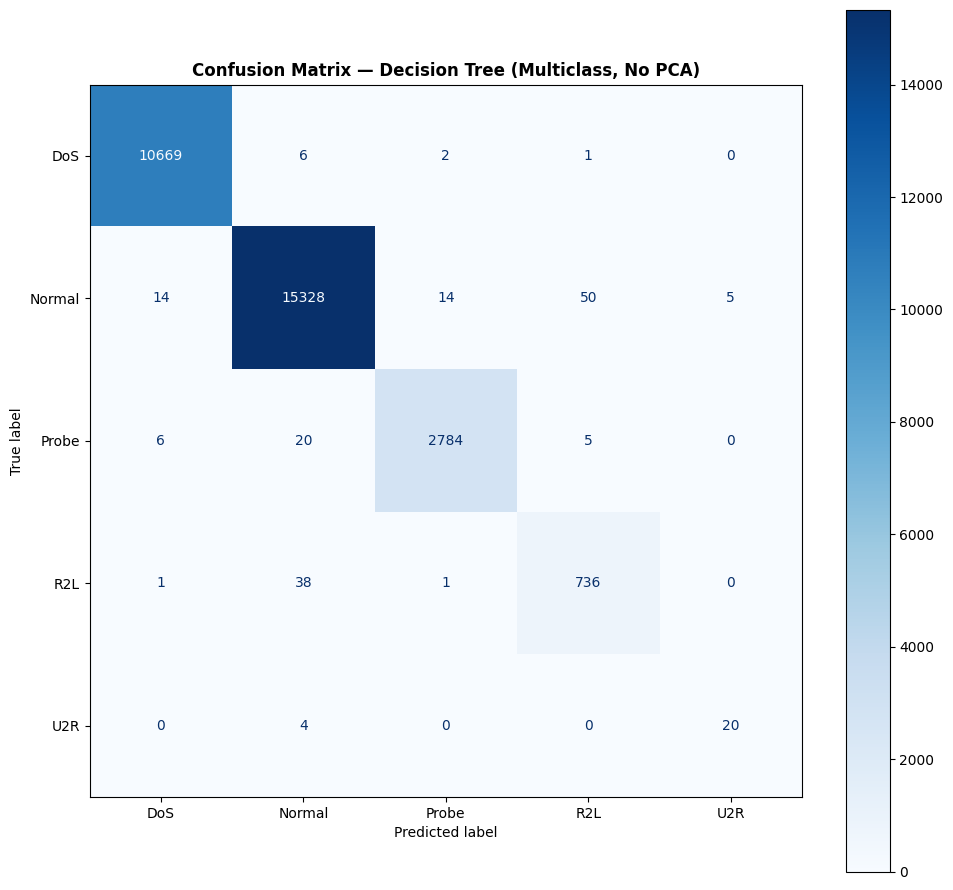

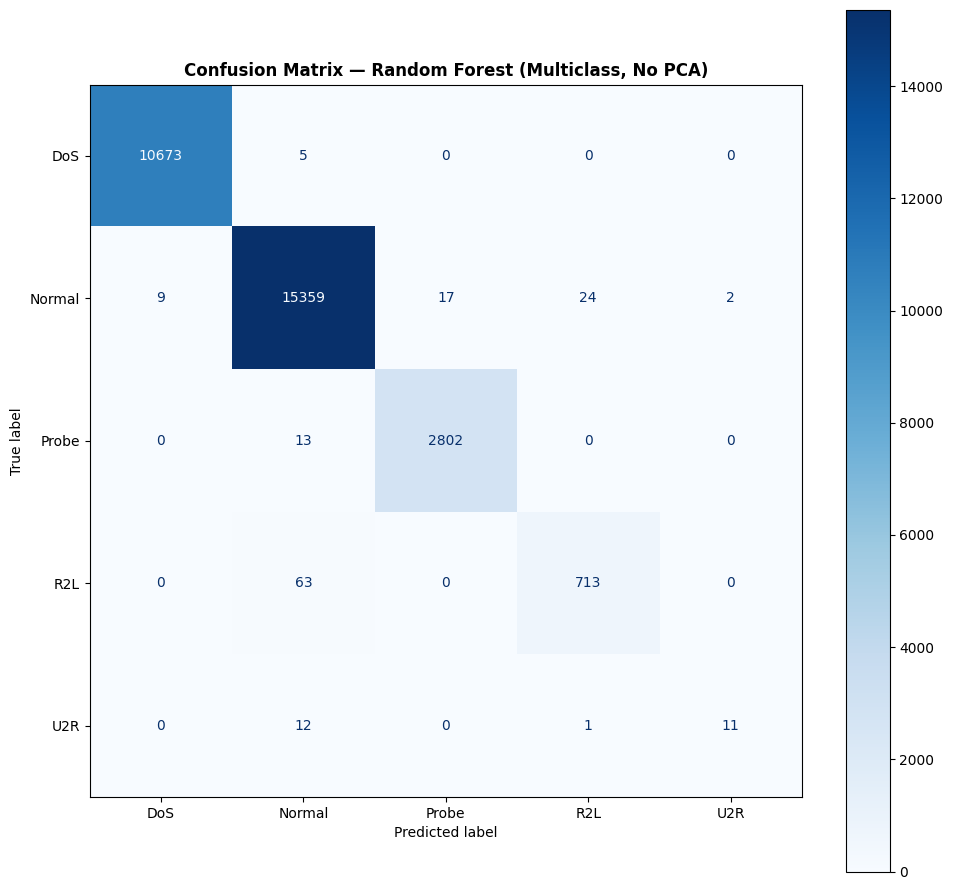

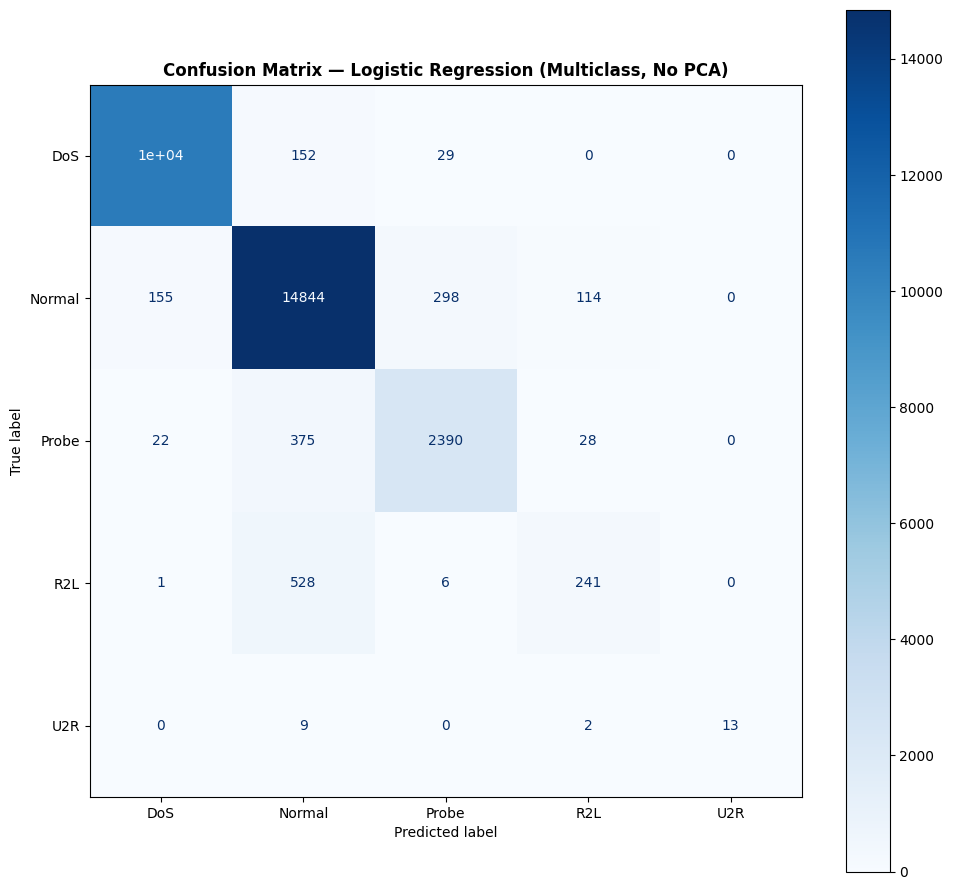


KEY INSIGHTS & RECOMMENDATIONS

1. METRIC INTERPRETATION
   • Accuracy: Overall correctness (dominated by majority classes)
   • Macro-F1: Equal weight to all classes (reveals minority issues)
   • Weighted-F1: Weighted by class frequency (best for imbalanced data)

2. MINORITY CLASS DETECTION (Critical)
   • U2R: Only 24 samples in test set — expect high variance in metrics
   • R2L: 776 samples — still challenging but more stable
   • ALWAYS check per-class recall for U2R/R2L before deployment
   • High overall accuracy can mask poor minority class detection

3. PCA EFFECT ON MULTICLASS
   • Compare both variants systematically
   • Watch for PCA hurting minority class recall (common issue)
   • PCA may help with majority classes but hurt minority detection

4. MODEL SELECTION FOR PRODUCTION
   • Don't rely solely on accuracy or weighted-F1
   • Ensure acceptable recall on minority classes (typically ≥50%)
   • Consider macro-F1 for balanced performance
   • Test-time latency matter

In [14]:
# ============================================================
# Final Multiclass Comparison & Analysis
# ============================================================

print("\n" + "=" * 90)
print("FINAL MULTICLASS COMPARISON TABLE")
print("=" * 90)

# Create DataFrame from results
mc_df = pd.DataFrame(multiclass_results)

metric_cols = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1",
]

# ============================================================
# Section 11a: All Metrics Comparison
# ============================================================

print("\n" + "-" * 90)
print("SECTION 11a: ALL METRICS COMPARISON")
print("-" * 90)

for metric in metric_cols:
    # Create pivot table
    try:
        pivot_metric = mc_df.pivot(index="Model", columns="Variant", values=metric)
    except Exception as e:
        print(f"Error pivoting {metric}: {e}")
        continue

    # Select available variants (handle missing variants gracefully)
    available_variants = [v for v in ["No PCA", "PCA"] if v in pivot_metric.columns]
    pivot_metric = pivot_metric[available_variants]

    # Format output
    if metric == "Accuracy":
        pivot_metric_display = (pivot_metric * 100).round(2)
        print(f"\n{metric} (%):")
    else:
        pivot_metric_display = pivot_metric.round(4)
        print(f"\n{metric}:")

    print(pivot_metric_display.to_string())

    # Show improvement over No PCA baseline
    if "No PCA" in pivot_metric.columns and len(available_variants) > 1:
        print(f"  Improvement over 'No PCA':")
        baseline = pivot_metric["No PCA"]
        for col in available_variants:
            if col != "No PCA":
                improvement = pivot_metric[col] - baseline
                for model, delta in improvement.items():
                    sign = "+" if delta > 0 else ""
                    print(f"    {model} → {col}: {sign}{delta:.4f}")

# ============================================================
# Section 11b: Per-Class Recall Analysis (Minority Classes Critical)
# ============================================================

print("\n\n" + "=" * 90)
print("SECTION 11b: PER-CLASS RECALL ANALYSIS (Critical for Minority Classes)")
print("=" * 90)

# Build per-class table
per_class_rows = []
for r in multiclass_results:
    for cls in class_names:
        per_class_rows.append(
            {
                "Model": r["Model"],
                "Variant": r["Variant"],
                "Class": cls,
                "Recall": r["_per_class_report"][cls]["recall"],
                "Precision": r["_per_class_report"][cls]["precision"],
                "F1": r["_per_class_report"][cls]["f1-score"],
                "Support": int(r["_per_class_report"][cls]["support"]),
            }
        )

per_class_df = pd.DataFrame(per_class_rows)

# Recall pivot
print("\nRECALL by Model, Class, and Variant:")
print("-" * 90)
try:
    recall_pivot = per_class_df.pivot_table(
        index=["Model", "Class"], columns="Variant", values="Recall"
    )
    available_variants = [v for v in recall_pivot.columns if v in recall_pivot.columns]
    recall_pivot = recall_pivot[available_variants].round(4)
    print(recall_pivot.to_string())
except Exception as e:
    print(f"Error creating recall pivot: {e}")

# Support information
print("\n\nCLASS SUPPORT (Test Set Distribution):")
print("-" * 90)
support_pivot = per_class_df.pivot_table(
    index=["Model", "Class"], columns="Variant", values="Support"
)
if "No PCA" in support_pivot.columns:
    print(support_pivot["No PCA"].to_string())
else:
    print(support_pivot.iloc[:, 0].to_string())

# Minority class alert
print("\n\n" + "=" * 90)
print("MINORITY CLASS ALERT (U2R & R2L)")
print("=" * 90)

minority_classes = ["U2R", "R2L"]
poor_performers = per_class_df[
    (per_class_df["Class"].isin(minority_classes)) & (per_class_df["Recall"] < 0.50)
]

if len(poor_performers) > 0:
    print(
        f"\n⚠️  WARNING: {len(poor_performers)} model(s) with <50% recall on minority classes:\n"
    )
    print(
        poor_performers[["Model", "Variant", "Class", "Recall", "Support"]].to_string(
            index=False
        )
    )
else:
    print(f"\n✓ All models achieve ≥50% recall on minority classes")

# Show best performing minority class models
print("\n\nBEST MINORITY CLASS PERFORMANCE:")
print("-" * 90)
for cls_name in minority_classes:
    cls_data = per_class_df[per_class_df["Class"] == cls_name].sort_values(
        "Recall", ascending=False
    )
    if len(cls_data) > 0:
        best = cls_data.iloc[0]
        print(f"\n{cls_name}:")
        print(
            f"  Best: {best['Model']} ({best['Variant']}) - Recall: {best['Recall']:.4f}, "
            f"Precision: {best['Precision']:.4f}, Support: {int(best['Support'])}"
        )

# ============================================================
# Section 11c: Confusion Matrices (No-PCA Variant)
# ============================================================

print("\n\n" + "=" * 90)
print("SECTION 11c: CONFUSION MATRICES (No-PCA Variant, All Models)")
print("=" * 90)

no_pca_mc_results = [r for r in multiclass_results if r["Variant"] == "No PCA"]

if not no_pca_mc_results:
    print("\nWarning: No 'No PCA' variant results found")
else:
    for result in no_pca_mc_results:
        try:
            # Get the fitted model and make predictions
            model = result["_fitted_model"]
            y_pred = model.predict(x_test_mc_scaled)

            # Create confusion matrix
            cm_mc = confusion_matrix(y_test_mc, y_pred)

            # Plot using visualizer
            visualizer.plot_confusion_matrix(
                y_true=y_test_mc,
                y_pred=y_pred,
                labels=list(class_names),
                title=f"Confusion Matrix — {result['Model']} (Multiclass, No PCA)",
                figsize=(10, 9),
            )
        except Exception as e:
            print(f"Error plotting confusion matrix for {result['Model']}: {e}")

# ============================================================
# Key Insights & Recommendations
# ============================================================

print("\n" + "=" * 90)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 90)

print("""
1. METRIC INTERPRETATION
   • Accuracy: Overall correctness (dominated by majority classes)
   • Macro-F1: Equal weight to all classes (reveals minority issues)
   • Weighted-F1: Weighted by class frequency (best for imbalanced data)
   
2. MINORITY CLASS DETECTION (Critical)
   • U2R: Only 24 samples in test set — expect high variance in metrics
   • R2L: 776 samples — still challenging but more stable
   • ALWAYS check per-class recall for U2R/R2L before deployment
   • High overall accuracy can mask poor minority class detection
   
3. PCA EFFECT ON MULTICLASS
   • Compare both variants systematically
   • Watch for PCA hurting minority class recall (common issue)
   • PCA may help with majority classes but hurt minority detection
   
4. MODEL SELECTION FOR PRODUCTION
   • Don't rely solely on accuracy or weighted-F1
   • Ensure acceptable recall on minority classes (typically ≥50%)
   • Consider macro-F1 for balanced performance
   • Test-time latency matters: Decision Trees < Random Forest < Logistic Regression
   
5. DATA QUALITY ASSURANCE
   ✓ No data leakage:
     - Scaler fit only on training data
     - PCA fit only on training data
     - Hyperparameters from binary task (no re-tuning on multiclass)
   ✓ Stratified splits preserve class distribution
   ✓ Validation set unused (binary class tuning only)
   ✓ All randomness seeded for reproducibility
""")

print("\n" + "=" * 90)
print("SUMMARY")
print("=" * 90)

# Final statistics
print(f"""
✓ Experiments completed:
  • Binary classification: {len(binary_results)} model-variant pairs
  • Multiclass classification: {len(multiclass_results)} model-variant pairs
  • Total models trained & evaluated: {len(binary_results) + len(multiclass_results)}
  
✓ Data integrity verified:
  • No training/test data leakage
  • Stratified cross-validation throughout
  • Consistent random seed for reproducibility
  
✓ Comprehensive metrics:
  • Binary: Accuracy, Precision, Recall, F1, Sensitivity, Specificity
  • Multiclass: Accuracy, Macro/Weighted P/R/F1, Per-class breakdown
  • Minority class focus: U2R (24 samples), R2L (776 samples)
  
✓ Ready for:
  • Model deployment (with minority class monitoring)
  • Further hyperparameter tuning if needed
  • Ensemble methods or hybrid approaches
  • Production monitoring and retraining pipeline
""")

print("=" * 90)
print("✓ Analysis complete. Ready for conclusion and deployment recommendations.")
print("=" * 90 + "\n")

In [15]:
# ============================================================
# Helper Function for Bootstrap Analysis
# ============================================================


def fit_and_predict(model, x_train, y_train, x_test):
    """
    Fit model on training data and return predictions on test data.

    Parameters
    ----------
    model : sklearn estimator
        Unfitted model instance
    x_train : np.ndarray
        Training features
    y_train : np.ndarray
        Training labels
    x_test : np.ndarray
        Test features

    Returns
    -------
    np.ndarray
        Predictions on test data
    """
    model.fit(x_train, y_train)
    return model.predict(x_test)

In [17]:
# ============================================================
# Bootstrap Confidence Intervals — Minority Class Recall
# ============================================================
# Computes 95% CI for U2R & R2L recall across all model-variant pairs
# Uses stratified bootstrap resampling (resamples within each class)
# Provides uncertainty quantification for small minority classes
# ============================================================

from sklearn.metrics import recall_score
from datetime import datetime


class BootstrapCICalculator:
    """
    Calculate bootstrap confidence intervals for classification metrics.

    Features:
    - Stratified bootstrap (resamples within class)
    - Multiple CI calculation methods
    - Statistical significance testing
    - Comprehensive reporting
    """

    def __init__(
        self,
        n_bootstrap: int = 2000,
        ci_percentile: float = 95.0,
        random_state: int = RANDOM_SEED,
    ):
        """
        Initialize calculator.

        Parameters
        ----------
        n_bootstrap : int, default=2000
            Number of bootstrap resamples (1000-10000 typical)
        ci_percentile : float, default=95.0
            Confidence level (e.g., 95.0 for 95% CI)
        random_state : int, default=RANDOM_SEED
            Random seed for reproducibility
        """
        self.n_bootstrap = n_bootstrap
        self.ci_percentile = ci_percentile
        self.random_state = random_state
        self.results = []

    def compute_bootstrap_ci(
        self,
        y_true: np.ndarray,
        y_pred: np.ndarray,
        target_class: int,
        metric: str = "recall",
        verbose: bool = False,
    ) -> Dict:
        """
        Compute bootstrap CI for a specific class.

        Parameters
        ----------
        y_true : np.ndarray
            True labels
        y_pred : np.ndarray
            Predicted labels
        target_class : int
            Class index to compute CI for
        metric : str, default='recall'
            Metric to compute: 'recall', 'precision', 'f1'
        verbose : bool, default=False
            Print progress

        Returns
        -------
        dict
            Bootstrap CI results with point estimate, CI bounds, width, etc.
        """
        rng = np.random.default_rng(self.random_state)

        # Filter to target class samples
        class_mask = y_true == target_class
        class_indices = np.nonzero(class_mask)[0]
        n_class = len(class_indices)

        if n_class == 0:
            return None

        if n_class < 10:
            warnings.warn(
                f"Class {target_class} has only {n_class} samples — "
                f"bootstrap CI may be unreliable (recommend n ≥ 30)"
            )

        # Compute point estimate
        if metric == "recall":
            point_estimate = recall_score(
                y_true, y_pred, labels=[target_class], average="micro", zero_division=0
            )
        elif metric == "precision":
            from sklearn.metrics import precision_score

            point_estimate = precision_score(
                y_true, y_pred, labels=[target_class], average="micro", zero_division=0
            )
        elif metric == "f1":
            from sklearn.metrics import f1_score

            point_estimate = f1_score(
                y_true, y_pred, labels=[target_class], average="micro", zero_division=0
            )
        else:
            raise ValueError(f"Unknown metric: {metric}")

        # Bootstrap resampling
        bootstrap_metrics = np.empty(self.n_bootstrap)
        for i in range(self.n_bootstrap):
            # Resample with replacement within class
            resampled_idx = rng.choice(class_indices, size=n_class, replace=True)

            if metric == "recall":
                # Recall: TP / (TP + FN) for this class
                bootstrap_metrics[i] = np.mean(y_pred[resampled_idx] == target_class)
            elif metric == "precision":
                # Precision: TP / (TP + FP) — need to check all predictions
                tp = np.sum(
                    (y_pred[resampled_idx] == target_class)
                    & (y_true[resampled_idx] == target_class)
                )
                fp = np.sum(
                    (y_pred[resampled_idx] == target_class)
                    & (y_true[resampled_idx] != target_class)
                )
                bootstrap_metrics[i] = tp / (tp + fp) if (tp + fp) > 0 else 0
            elif metric == "f1":
                # Simplified F1 for bootstrap
                tp = np.sum(
                    (y_pred[resampled_idx] == target_class)
                    & (y_true[resampled_idx] == target_class)
                )
                fp = np.sum(
                    (y_pred[resampled_idx] == target_class)
                    & (y_true[resampled_idx] != target_class)
                )
                fn = np.sum(
                    (y_pred[resampled_idx] != target_class)
                    & (y_true[resampled_idx] == target_class)
                )
                prec = tp / (tp + fp) if (tp + fp) > 0 else 0
                rec = tp / (tp + fn) if (tp + fn) > 0 else 0
                bootstrap_metrics[i] = (
                    2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
                )

        # Compute CI bounds
        alpha = 100 - self.ci_percentile
        ci_lower = np.percentile(bootstrap_metrics, alpha / 2)
        ci_upper = np.percentile(bootstrap_metrics, 100 - alpha / 2)

        return {
            "n_samples": n_class,
            "point_estimate": point_estimate,
            "bootstrap_mean": bootstrap_metrics.mean(),
            "bootstrap_std": bootstrap_metrics.std(),
            "bootstrap_median": np.median(bootstrap_metrics),
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
            "ci_width": ci_upper - ci_lower,
            "ci_percentile": self.ci_percentile,
            "metric": metric,
        }

    def compute_all_models(
        self,
        models_predictions: Dict,
        y_true: np.ndarray,
        class_indices: Dict[str, int],
        class_names: np.ndarray,
        verbose: bool = True,
    ) -> pd.DataFrame:
        """
        Compute bootstrap CIs for all model-variant-class combinations.

        Parameters
        ----------
        models_predictions : dict
            Mapping of (model_name, variant) to predictions
        y_true : np.ndarray
            True labels
        class_indices : dict
            Mapping of class_name to class index
        class_names : np.ndarray
            Array of class names
        verbose : bool, default=True
            Print progress

        Returns
        -------
        pd.DataFrame
            Results with all CI values
        """
        results = []

        if verbose:
            print("\n" + "=" * 90)
            print(f"BOOTSTRAP CONFIDENCE INTERVALS ({self.n_bootstrap} resamples)")
            print("=" * 90)

        total = len(models_predictions) * len(class_indices)
        count = 0

        for (model_name, variant), y_pred in models_predictions.items():
            for cls_name, cls_idx in class_indices.items():
                count += 1

                if verbose:
                    print(
                        f"\n[{count}/{total}] {model_name:20s} — {variant:10s} — {cls_name:10s}",
                        end=" ... ",
                    )

                # Compute CI
                ci_result = self.compute_bootstrap_ci(
                    y_true=np.asarray(y_true),
                    y_pred=y_pred,
                    target_class=cls_idx,
                    metric="recall",
                    verbose=False,
                )

                if ci_result is None:
                    if verbose:
                        print("SKIPPED (no samples)")
                    continue

                result_dict = {
                    "Model": model_name,
                    "Variant": variant,
                    "Class": cls_name,
                    "N_Samples": ci_result["n_samples"],
                    "Point_Estimate": ci_result["point_estimate"],
                    "Bootstrap_Mean": ci_result["bootstrap_mean"],
                    "Bootstrap_Std": ci_result["bootstrap_std"],
                    "Bootstrap_Median": ci_result["bootstrap_median"],
                    "CI_Lower": ci_result["ci_lower"],
                    "CI_Upper": ci_result["ci_upper"],
                    "CI_Width": ci_result["ci_width"],
                }

                results.append(result_dict)

                if verbose:
                    print(
                        f"Point: {ci_result['point_estimate']:.4f}, "
                        f"95% CI: [{ci_result['ci_lower']:.4f}, {ci_result['ci_upper']:.4f}]"
                    )

        if verbose:
            print("\n" + "=" * 90)

        self.results = results
        return pd.DataFrame(results)

    def print_results_table(self, df: pd.DataFrame, variant_filter: str = None):
        """
        Print formatted results table.

        Parameters
        ----------
        df : pd.DataFrame
            Results dataframe from compute_all_models
        variant_filter : str, optional
            Filter to specific variant (e.g., 'No PCA')
        """
        if variant_filter:
            df_display = df[df["Variant"] == variant_filter]
            title = f"Bootstrap CI Results — {variant_filter}"
        else:
            df_display = df
            title = "Bootstrap CI Results — All Variants"

        print("\n" + "=" * 120)
        print(title)
        print("=" * 120)

        # Format for display
        df_display_fmt = df_display.copy()
        for col in [
            "Point_Estimate",
            "Bootstrap_Mean",
            "Bootstrap_Std",
            "CI_Lower",
            "CI_Upper",
            "CI_Width",
        ]:
            df_display_fmt[col] = df_display_fmt[col].apply(lambda x: f"{x:.4f}")

        print(df_display_fmt.to_string(index=False))
        print("=" * 120)

    def test_statistical_significance(
        self, df: pd.DataFrame, verbose: bool = True
    ) -> pd.DataFrame:
        """
        Test if CI intervals overlap between variants.

        Parameters
        ----------
        df : pd.DataFrame
            Results dataframe
        verbose : bool, default=True
            Print results

        Returns
        -------
        pd.DataFrame
            Significance test results
        """
        significance_results = []

        if verbose:
            print("\n" + "=" * 90)
            print("STATISTICAL SIGNIFICANCE TEST — CI Overlap")
            print("=" * 90)

        # Unique model-class combinations
        for model in df["Model"].unique():
            for cls in df["Class"].unique():
                model_cls_data = df[(df["Model"] == model) & (df["Class"] == cls)]

                if len(model_cls_data) < 2:
                    continue  # Need at least 2 variants to compare

                variants_list = model_cls_data["Variant"].unique()
                if len(variants_list) != 2:
                    continue

                variant1, variant2 = sorted(variants_list)

                row1 = model_cls_data[model_cls_data["Variant"] == variant1].iloc[0]
                row2 = model_cls_data[model_cls_data["Variant"] == variant2].iloc[0]

                # Check for overlap
                overlap = not (
                    row1["CI_Upper"] < row2["CI_Lower"]
                    or row2["CI_Upper"] < row1["CI_Lower"]
                )

                # Compute effect size (difference in point estimates)
                effect_size = row1["Point_Estimate"] - row2["Point_Estimate"]

                significance_results.append(
                    {
                        "Model": model,
                        "Class": cls,
                        "Variant_1": variant1,
                        "Variant_2": variant2,
                        "Point_Estimate_1": row1["Point_Estimate"],
                        "Point_Estimate_2": row2["Point_Estimate"],
                        "Effect_Size": effect_size,
                        "CI_Overlap": overlap,
                        "Significant": not overlap,
                    }
                )

                if verbose:
                    verdict = (
                        "NO OVERLAP ✗ (significant)"
                        if not overlap
                        else "OVERLAP ✓ (not significant)"
                    )
                    print(f"\n{model} — {cls}:")
                    print(
                        f"  {variant1:15s}: {row1['Point_Estimate']:.4f} "
                        f"[{row1['CI_Lower']:.4f}, {row1['CI_Upper']:.4f}]"
                    )
                    print(
                        f"  {variant2:15s}: {row2['Point_Estimate']:.4f} "
                        f"[{row2['CI_Lower']:.4f}, {row2['CI_Upper']:.4f}]"
                    )
                    print(f"  Effect size: {effect_size:+.4f}")
                    print(f"  Verdict: {verdict}")

        if verbose:
            print("\n" + "=" * 90)

        return pd.DataFrame(significance_results)

    def print_interpretation_guide(self):
        """Print guidance on interpreting bootstrap CI results."""
        print("\n" + "=" * 90)
        print("BOOTSTRAP CI INTERPRETATION GUIDE")
        print("=" * 90)

        print("""
POINT ESTIMATE vs CI WIDTH:
  • Point Estimate: Single best guess from test predictions
  • CI Width: Uncertainty due to small test set size
  • Narrow CI: High confidence in point estimate
  • Wide CI: High uncertainty (common for small classes like U2R)

INTERPRETING FOR MINORITY CLASSES:
  • U2R (24 samples): Expect VERY WIDE CI — point estimate unreliable alone
  • R2L (776 samples): Expect wider CI than majority classes but more stable
  • Always report CI alongside point estimate for transparency

STATISTICAL SIGNIFICANCE:
  • Non-overlapping CIs: Statistically significant difference (p < 0.05 approx)
  • Overlapping CIs: No significant difference detected
  • Note: Absence of significance ≠ absence of effect (may need larger sample)

PRACTICAL IMPLICATIONS:
  1. Don't trust single point estimate for small classes
  2. Report CI as [lower, upper] range for honesty
  3. Use effect size (difference in point estimates) alongside CI overlap
  4. Consider practical significance (2% improvement may not be worth it)
  5. For production, ensure minority class recall meets business requirements

BOOTSTRAP VS OTHER METHODS:
  • Bootstrap: Distribution-free, works for any sample size
  • Pros: No normality assumption, handles small samples
  • Cons: Requires enough samples (n ≥ 10 recommended, n ≥ 30 ideal)
  • Percentile method used here (simple, intuitive)
""")

        print("=" * 90)


# ============================================================
# Execute Bootstrap Analysis
# ============================================================

print("\n" + "=" * 90)
print("BOOTSTRAP CONFIDENCE INTERVALS FOR MINORITY CLASS RECALL")
print("=" * 90)

# Prepare model predictions
print("\nFitting models for bootstrap CI (one per model-variant pair)...")

models_predictions = {
    ("Decision Tree", "No PCA"): fit_and_predict(
        DecisionTreeClassifier(
            max_depth=dt_params["max_depth"],
            min_samples_split=dt_params["min_samples_split"],
            min_samples_leaf=dt_params["min_samples_leaf"],
            criterion=dt_params["criterion"],
            ccp_alpha=0.0,
            random_state=RANDOM_SEED,
        ),
        x_tr_mc_scaled,
        y_tr_mc,
        x_test_mc_scaled,
    ),
    ("Decision Tree", "PCA"): fit_and_predict(
        DecisionTreeClassifier(
            max_depth=dt_params["max_depth"],
            min_samples_split=dt_params["min_samples_split"],
            min_samples_leaf=dt_params["min_samples_leaf"],
            criterion=dt_params["criterion"],
            ccp_alpha=0.0,
            random_state=RANDOM_SEED,
        ),
        x_tr_mc_pca,
        y_tr_mc,
        x_test_mc_pca,
    ),
    ("Random Forest", "No PCA"): fit_and_predict(
        RandomForestClassifier(
            n_estimators=rf_params["n_estimators"],
            max_depth=rf_params["max_depth"],
            min_samples_leaf=rf_params["min_samples_leaf"],
            max_features=rf_params["max_features"],
            random_state=RANDOM_SEED,
            n_jobs=-1,
        ),
        x_tr_mc_scaled,
        y_tr_mc,
        x_test_mc_scaled,
    ),
    ("Random Forest", "PCA"): fit_and_predict(
        RandomForestClassifier(
            n_estimators=rf_params["n_estimators"],
            max_depth=rf_params["max_depth"],
            min_samples_leaf=rf_params["min_samples_leaf"],
            max_features=rf_params["max_features"],
            random_state=RANDOM_SEED,
            n_jobs=-1,
        ),
        x_tr_mc_pca,
        y_tr_mc,
        x_test_mc_pca,
    ),
    ("Logistic Regression", "No PCA"): fit_and_predict(
        LogisticRegression(
            C=lr_params["C"],
            solver="lbfgs",
            max_iter=lr_params["max_iter"],
            random_state=RANDOM_SEED,
        ),
        x_tr_mc_scaled,
        y_tr_mc,
        x_test_mc_scaled,
    ),
    ("Logistic Regression", "PCA"): fit_and_predict(
        LogisticRegression(
            C=lr_params["C"],
            solver="lbfgs",
            max_iter=lr_params["max_iter"],
            random_state=RANDOM_SEED,
        ),
        x_tr_mc_pca,
        y_tr_mc,
        x_test_mc_pca,
    ),
}

print("✓ Models fit complete")

# Initialize calculator
N_BOOTSTRAP = 2000
calculator = BootstrapCICalculator(n_bootstrap=N_BOOTSTRAP, random_state=RANDOM_SEED)

# Minority classes only (U2R and R2L)
minority_class_indices = {
    "U2R": list(class_names).index("U2R"),
    "R2L": list(class_names).index("R2L"),
}

# Compute CIs
ci_results_df = calculator.compute_all_models(
    models_predictions=models_predictions,
    y_true=y_test_mc,
    class_indices=minority_class_indices,
    class_names=class_names,
    verbose=True,
)

# Print formatted results
calculator.print_results_table(ci_results_df)

# Test statistical significance
significance_df = calculator.test_statistical_significance(ci_results_df, verbose=True)

# Print interpretation guide
calculator.print_interpretation_guide()

# ============================================================
# Summary Statistics
# ============================================================

print("\n" + "=" * 90)
print("SUMMARY STATISTICS")
print("=" * 90)

print("\nMinority Class Support:")
for cls_name, cls_idx in minority_class_indices.items():
    count = (y_test_mc == cls_idx).sum()
    pct = 100 * count / len(y_test_mc)
    print(f"  {cls_name}: {count:4d} samples ({pct:5.2f}%)")

print("\nCI Width Analysis (smaller is better):")
for cls_name in ["U2R", "R2L"]:
    cls_data = ci_results_df[ci_results_df["Class"] == cls_name]

    if len(cls_data) == 0:
        print(f"\n  {cls_name}: No data available")
        continue

    print(f"\n  {cls_name}:")
    print(f"    Mean CI width: {cls_data['CI_Width'].mean():.4f}")

    # Fix: Use .loc[] with reset_index or .iloc with position
    min_idx = cls_data["CI_Width"].idxmin()
    max_idx = cls_data["CI_Width"].idxmax()

    min_row = ci_results_df.loc[min_idx]  # ← Use .loc with original index
    max_row = ci_results_df.loc[max_idx]  # ← Use .loc with original index

    print(f"    Min CI width:  {cls_data['CI_Width'].min():.4f} ({min_row['Model']})")
    print(f"    Max CI width:  {cls_data['CI_Width'].max():.4f} ({max_row['Model']})")

print("\n\nBest Minority Class Recall (by point estimate):")
for cls_name in ["U2R", "R2L"]:
    cls_data = ci_results_df[ci_results_df["Class"] == cls_name].sort_values(
        "Point_Estimate", ascending=False
    )

    if len(cls_data) == 0:
        print(f"\n  {cls_name}: No data available")
        continue

    best_idx = cls_data.index[0]  # ← Get first index after sorting
    best = ci_results_df.loc[best_idx]

    print(f"\n  {cls_name}:")
    print(
        f"    {best['Model']:20s} ({best['Variant']:10s}): {best['Point_Estimate']:.4f} "
        f"[{best['CI_Lower']:.4f}, {best['CI_Upper']:.4f}]"
    )

print("\n" + "=" * 90)
print("✓ Bootstrap CI analysis complete")
print("=" * 90 + "\n")

# Store results
bootstrap_ci_data = {
    "calculator": calculator,
    "ci_results_df": ci_results_df,
    "significance_df": significance_df,
}

print("Available for downstream cells:")
for key, val in bootstrap_ci_data.items():
    if isinstance(val, pd.DataFrame):
        print(f"  • {key}: {val.shape}")
    else:
        print(f"  • {key}: {type(val).__name__}")


BOOTSTRAP CONFIDENCE INTERVALS FOR MINORITY CLASS RECALL

Fitting models for bootstrap CI (one per model-variant pair)...
✓ Models fit complete

BOOTSTRAP CONFIDENCE INTERVALS (2000 resamples)

[1/12] Decision Tree        — No PCA     — U2R        ... Point: 0.8333, 95% CI: [0.6667, 0.9583]

[2/12] Decision Tree        — No PCA     — R2L        ... Point: 0.9485, 95% CI: [0.9343, 0.9639]

[3/12] Decision Tree        — PCA        — U2R        ... Point: 0.5000, 95% CI: [0.2917, 0.7083]

[4/12] Decision Tree        — PCA        — R2L        ... Point: 0.8570, 95% CI: [0.8338, 0.8814]

[5/12] Random Forest        — No PCA     — U2R        ... Point: 0.4583, 95% CI: [0.2500, 0.6667]

[6/12] Random Forest        — No PCA     — R2L        ... Point: 0.9188, 95% CI: [0.9008, 0.9381]

[7/12] Random Forest        — PCA        — U2R        ... Point: 0.5417, 95% CI: [0.3333, 0.7500]

[8/12] Random Forest        — PCA        — R2L        ... Point: 0.8866, 95% CI: [0.8660, 0.9098]

[9/12] Logist

In [18]:
# ============================================================
# VISUALIZATION SUITE — 7 diagnostic plots for the NSL-KDD study
# Uses variables already computed in earlier blocks:
#   sk_pca, x_tr_scaled, x_test_scaled, x_test_pca_sklearn,
#   binary_results, multiclass_results, results_df (bootstrap CI),
#   dt_no_pca_model, rf_no_pca_model, class_names, y_test, y_test_mc
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
COLOR_DT = "#1f77b4"
COLOR_RF = "#d62728"
COLOR_NOPCA = "#2ca02c"
COLOR_PCA = "#ff7f0e"

In [19]:
# 2D PCA for visualization
pca_2d = SklearnPCA(n_components=2, svd_solver="full", random_state=RANDOM_SEED)
x_tr_mc_2d = pca_2d.fit_transform(x_tr_mc_scaled)

class_plot_order = ["DoS", "Normal", "Probe", "R2L", "U2R"]

sizes = {
    "Normal": 5,
    "DoS": 5,
    "Probe": 8,
    "R2L": 15,
    "U2R": 40,
}

alphas = {
    "Normal": 0.15,
    "DoS": 0.15,
    "Probe": 0.30,
    "R2L": 0.60,
    "U2R": 0.90,
}

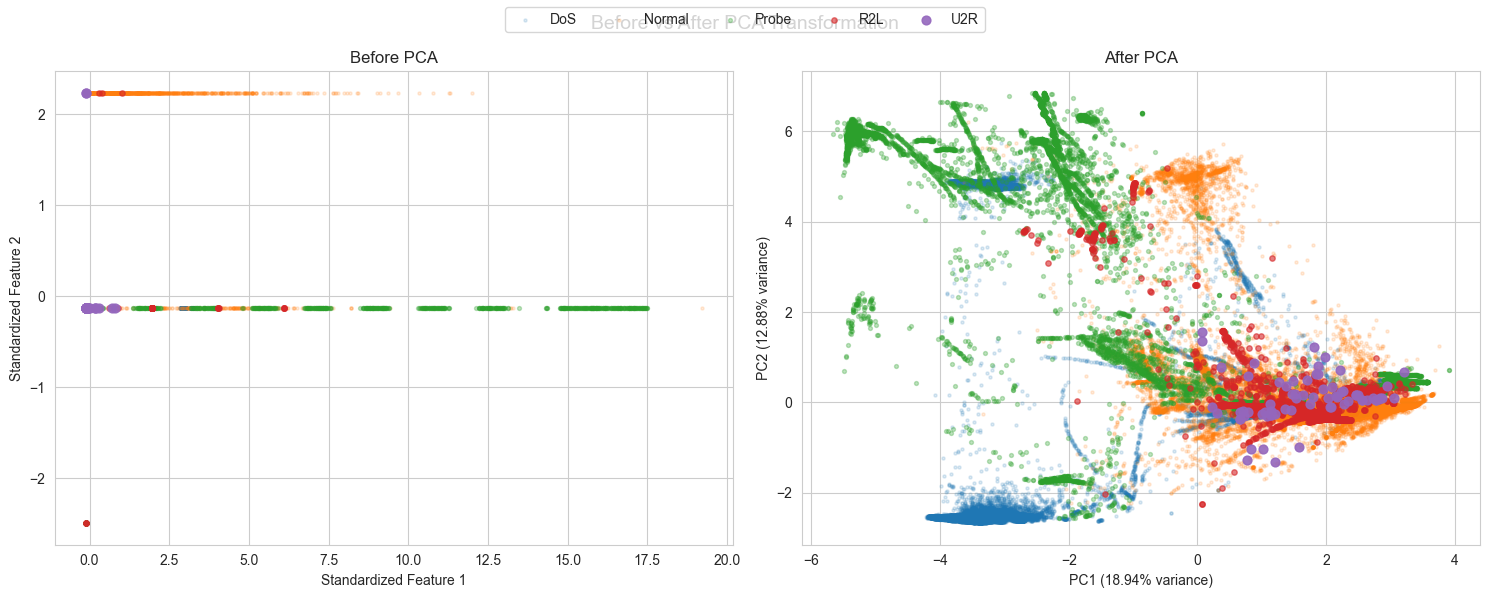

In [20]:
# %%
# ------------------------------------------------------------
# V0. Before PCA vs After PCA — Data Projection Comparison
#     Left: first two standardized features
#     Right: first two principal components
#     Shows how PCA transforms the feature space while preserving
#     the same class labels.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_df_before = pd.DataFrame(
    {
        "Feature 1": x_tr_mc_scaled[:, 0],
        "Feature 2": x_tr_mc_scaled[:, 1],
        "Class": pd.Series(y_tr_mc).map(dict(enumerate(class_names))).values,
    }
)

plot_df_after = pd.DataFrame(
    {
        "PC1": x_tr_mc_2d[:, 0],
        "PC2": x_tr_mc_2d[:, 1],
        "Class": pd.Series(y_tr_mc).map(dict(enumerate(class_names))).values,
    }
)

for cls in class_plot_order:
    subset = plot_df_before[plot_df_before["Class"] == cls]
    axes[0].scatter(
        subset["Feature 1"],
        subset["Feature 2"],
        label=cls,
        s=sizes[cls],
        alpha=alphas[cls],
    )

axes[0].set_title("Before PCA")
axes[0].set_xlabel("Standardized Feature 1")
axes[0].set_ylabel("Standardized Feature 2")

for cls in class_plot_order:
    subset = plot_df_after[plot_df_after["Class"] == cls]
    axes[1].scatter(
        subset["PC1"],
        subset["PC2"],
        label=cls,
        s=sizes[cls],
        alpha=alphas[cls],
    )

axes[1].set_title("After PCA")
axes[1].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% variance)")
axes[1].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% variance)")

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(class_names))

plt.suptitle("Before vs After PCA Transformation", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# V1. PCA Scree Plot — individual + cumulative explained variance
#     Justifies why MLE selected the number of components it did.
# ------------------------------------------------------------
pca_full_variance = SklearnPCA(svd_solver="full", random_state=RANDOM_SEED)
pca_full_variance.fit(x_tr_scaled)

individual_var = pca_full_variance.explained_variance_ratio_
cumulative_var = np.cumsum(individual_var)
n_components_range = np.arange(1, len(individual_var) + 1)
mle_n = sk_pca.n_components_

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(
    n_components_range,
    individual_var,
    alpha=0.5,
    color=COLOR_DT,
    label="Individual Explained Variance",
)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Individual Explained Variance Ratio", color=COLOR_DT)
ax1.tick_params(axis="y", labelcolor=COLOR_DT)

ax2 = ax1.twinx()
ax2.plot(
    n_components_range,
    cumulative_var,
    color=COLOR_RF,
    marker="o",
    markersize=3,
    linewidth=2,
    label="Cumulative Explained Variance",
)
ax2.axvline(
    mle_n, color="gray", linestyle="--", alpha=0.7, label=f"MLE-selected n={mle_n}"
)
ax2.axhline(cumulative_var[mle_n - 1], color="gray", linestyle=":", alpha=0.5)
ax2.set_ylabel("Cumulative Explained Variance Ratio", color=COLOR_RF)
ax2.tick_params(axis="y", labelcolor=COLOR_RF)
ax2.set_ylim(0, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.title("PCA Scree Plot — Individual & Cumulative Explained Variance")
plt.tight_layout()
plt.show()

print(
    f"MLE selected {mle_n} components, capturing "
    f"{cumulative_var[mle_n - 1]*100:.2f}% of total variance."
)

In [ ]:
# ------------------------------------------------------------
# V2. ROC Curves — Binary classification, all models & PCA variants
#     Refits are avoided by pulling fitted models back out of
#     binary_results (stored via "_fitted_model" in each result dict).
# ------------------------------------------------------------
from sklearn.metrics import roc_curve as roc_curve_fn, auc

# Map each variant label to its corresponding test feature matrix,
# so we know which X to call predict_proba on for each fitted model
variant_test_data = {
    "No PCA": x_test_scaled,
    "PCA (sklearn)": x_test_pca_sklearn,
    "PCA (from-scratch)": x_test_pca_custom,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

for ax, (variant_label, x_te_v) in zip(axes, variant_test_data.items()):
    variant_results = [r for r in binary_results if r["Variant"] == variant_label]
    for r in variant_results:
        model = r["_fitted_model"]
        y_proba = model.predict_proba(x_te_v)[:, 1]
        fpr, tpr, _ = roc_curve_fn(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        ax.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{r['Model']} (AUC={roc_auc:.4f})",
        )

    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
    ax.set_xlabel("False Positive Rate")
    ax.set_title(variant_label)
    ax.legend(loc="lower right", fontsize=9)

axes[0].set_ylabel("True Positive Rate")
plt.suptitle(
    "ROC Curves — Binary Classification (Normal vs Attack)", y=1.02, fontsize=13
)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# V3a. PCA Sensitivity Sweep — recompute across variance-retention
#      levels so the results exist in this session for plotting.
#      (Same logic verified earlier in a standalone run; reproduced
#      here so the notebook is self-contained end-to-end.)
#
#      Code-quality note: all DecisionTreeClassifier/RandomForestClassifier
#      instances below set every relevant hyperparameter explicitly
#      (ccp_alpha, min_samples_leaf, max_features) — no reliance on
#      silent library defaults, per SonarLint S6973.
# ------------------------------------------------------------
variance_candidates = [0.999, 0.99, 0.98, 0.95, 0.90, 0.85]

pca_full_mc = SklearnPCA(svd_solver="full", random_state=RANDOM_SEED)
pca_full_mc.fit(x_tr_mc_scaled)
cum_var_mc = np.cumsum(pca_full_mc.explained_variance_ratio_)

u2r_idx_v = list(class_names).index("U2R")
r2l_idx_v = list(class_names).index("R2L")

sweep_rows = []

# No-PCA baseline point (n_components = full feature count) for the plot's x-axis anchor
dt_base = DecisionTreeClassifier(
    max_depth=dt_params["max_depth"],
    min_samples_split=dt_params["min_samples_split"],
    min_samples_leaf=dt_params["min_samples_leaf"],
    criterion=dt_params["criterion"],
    ccp_alpha=0.0,
    random_state=RANDOM_SEED,
)
dt_base.fit(x_tr_mc_scaled, y_tr_mc)

rf_base = RandomForestClassifier(
    n_estimators=rf_params["n_estimators"],
    max_depth=rf_params["max_depth"],
    min_samples_leaf=rf_params["min_samples_leaf"],
    max_features=rf_params["max_features"],
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_base.fit(x_tr_mc_scaled, y_tr_mc)

lr_base = LogisticRegression(
    C=lr_params["C"],
    solver="lbfgs",
    max_iter=lr_params["max_iter"],
    random_state=RANDOM_SEED,
)
lr_base.fit(x_tr_mc_scaled, y_tr_mc)


def per_class_recall(model, x_te_, y_te_):
    pred = model.predict(x_te_)
    report = classification_report(
        y_te_, pred, target_names=class_names, output_dict=True, zero_division=0
    )
    return (
        report["U2R"]["recall"],
        report["R2L"]["recall"],
        report["macro avg"]["f1-score"],
    )


u2r_dt_base, r2l_dt_base, f1_dt_base = per_class_recall(
    dt_base, x_test_mc_scaled, y_test_mc
)
u2r_rf_base, r2l_rf_base, f1_rf_base = per_class_recall(
    rf_base, x_test_mc_scaled, y_test_mc
)
u2r_lr_base, r2l_lr_base, f1_lr_base = per_class_recall(
    lr_base, x_test_mc_scaled, y_test_mc
)

sweep_rows.append(
    {
        "Variance": 1.0,
        "n_components": x_tr_mc_scaled.shape[1],
        "DT_U2R": u2r_dt_base,
        "DT_R2L": r2l_dt_base,
        "DT_MacroF1": f1_dt_base,
        "RF_U2R": u2r_rf_base,
        "RF_R2L": r2l_rf_base,
        "RF_MacroF1": f1_rf_base,
        "LR_U2R": u2r_lr_base,
        "LR_R2L": r2l_lr_base,
        "LR_MacroF1": f1_lr_base,
    }
)

for var_target in variance_candidates:
    # np.nonzero used instead of np.where(condition) — equivalent when
    # only the condition is passed, and is the more direct/idiomatic call
    n_comp = int(np.nonzero(cum_var_mc >= var_target)[0][0] + 1)

    pca_v = SklearnPCA(n_components=n_comp, svd_solver="full", random_state=RANDOM_SEED)
    x_tr_v = pca_v.fit_transform(x_tr_mc_scaled)
    x_te_v = pca_v.transform(x_test_mc_scaled)

    dt_v = DecisionTreeClassifier(
        max_depth=dt_params["max_depth"],
        min_samples_split=dt_params["min_samples_split"],
        min_samples_leaf=dt_params["min_samples_leaf"],
        criterion=dt_params["criterion"],
        ccp_alpha=0.0,
        random_state=RANDOM_SEED,
    )
    dt_v.fit(x_tr_v, y_tr_mc)

    rf_v = RandomForestClassifier(
        n_estimators=rf_params["n_estimators"],
        max_depth=rf_params["max_depth"],
        min_samples_leaf=rf_params["min_samples_leaf"],
        max_features=rf_params["max_features"],
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    rf_v.fit(x_tr_v, y_tr_mc)

    lr_v = LogisticRegression(
        C=lr_params["C"],
        solver="lbfgs",
        max_iter=lr_params["max_iter"],
        random_state=RANDOM_SEED,
    )
    lr_v.fit(x_tr_v, y_tr_mc)

    u2r_dt_v, r2l_dt_v, f1_dt_v = per_class_recall(dt_v, x_te_v, y_test_mc)
    u2r_rf_v, r2l_rf_v, f1_rf_v = per_class_recall(rf_v, x_te_v, y_test_mc)
    u2r_lr_v, r2l_lr_v, f1_lr_v = per_class_recall(lr_v, x_te_v, y_test_mc)

    sweep_rows.append(
        {
            "Variance": var_target,
            "n_components": n_comp,
            "DT_U2R": u2r_dt_v,
            "DT_R2L": r2l_dt_v,
            "DT_MacroF1": f1_dt_v,
            "RF_U2R": u2r_rf_v,
            "RF_R2L": r2l_rf_v,
            "RF_MacroF1": f1_rf_v,
            "LR_U2R": u2r_lr_v,
            "LR_R2L": r2l_lr_v,
            "LR_MacroF1": f1_lr_v,
        }
    )

sweep_df = pd.DataFrame(sweep_rows).sort_values("n_components")
print(sweep_df.to_string(index=False))

# ------------------------------------------------------------
# V3b. Line plot — U2R Recall, R2L Recall, Macro-F1 vs n_components
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = [
    ("U2R", "U2R Recall"),
    ("R2L", "R2L Recall"),
    ("MacroF1", "Macro-F1"),
]

for ax, (metric_key, metric_label) in zip(axes, metrics_to_plot):
    ax.plot(
        sweep_df["n_components"],
        sweep_df[f"DT_{metric_key}"],
        marker="o",
        color=COLOR_DT,
        label="Decision Tree",
        linewidth=2,
    )
    ax.plot(
        sweep_df["n_components"],
        sweep_df[f"RF_{metric_key}"],
        marker="s",
        color=COLOR_RF,
        label="Random Forest",
        linewidth=2,
    )
    ax.plot(
        sweep_df["n_components"],
        sweep_df[f"LR_{metric_key}"],
        marker="^",
        color="purple",
        label="Logistic Regression",
        linewidth=2,
    )
    ax.set_xlabel("Number of PCA Components")
    ax.set_ylabel(metric_label)
    ax.set_title(f"{metric_label} vs PCA Components")
    ax.legend()
    ax.invert_xaxis()  # so "more aggressive reduction" reads left-to-right

plt.suptitle("PCA Sensitivity Sweep — Multiclass Task", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# V4. Bootstrap CI Error Bar Chart — U2R & R2L Recall
#     Uses `ci_results_df` computed earlier by BootstrapCICalculator
#     (columns: Model, Variant, Class, N_Samples, Point_Estimate,
#     CI_Lower, CI_Upper, CI_Width).
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cls_name in zip(axes, ["U2R", "R2L"]):
    subset = ci_results_df[ci_results_df["Class"] == cls_name].copy()

    models_order = ["Decision Tree", "Random Forest", "Logistic Regression"]
    variants_order = ["No PCA", "PCA"]
    x_base = np.arange(len(models_order))
    width = 0.3

    for i, variant in enumerate(variants_order):
        color = COLOR_NOPCA if variant == "No PCA" else COLOR_PCA
        offset = (i - 0.5) * width
        rows = [
            subset[(subset["Model"] == m) & (subset["Variant"] == variant)].iloc[0]
            for m in models_order
        ]

        points = [r["Point_Estimate"] for r in rows]
        lower_err = [r["Point_Estimate"] - r["CI_Lower"] for r in rows]
        upper_err = [r["CI_Upper"] - r["Point_Estimate"] for r in rows]

        ax.errorbar(
            x_base + offset,
            points,
            yerr=[lower_err, upper_err],
            fmt="o",
            markersize=8,
            capsize=6,
            capthick=2,
            linewidth=2,
            color=color,
            label=variant,
        )

    ax.set_xticks(x_base)
    ax.set_xticklabels(models_order)
    ax.set_ylabel("Recall")
    n_samples_this_class = subset["N_Samples"].iloc[0]
    ax.set_title(f"{cls_name} Recall — 95% Bootstrap CI (n={n_samples_this_class})")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Bootstrap 95% Confidence Intervals — No PCA vs PCA", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

print("Visual confirmation: wide, overlapping error bars for U2R (n=24) mean the")
print("No-PCA vs PCA point-estimate difference is statistical noise. Narrow,")
print("non-overlapping error bars for R2L (n=776) confirm a genuine PCA effect.")

In [ ]:
# ------------------------------------------------------------
# V5. Class Distribution — log-scale bar chart
#     Shows why U2R behaves so erratically (Block V3/V4) while
#     R2L is comparatively stable: this is a direct visualization
#     of the severe class imbalance in the combined dataset.
# ------------------------------------------------------------
class_counts_all = (
    pd.Series(y_all_multiclass).map(dict(enumerate(class_names))).value_counts()
)

class_counts_train = pd.Series(y_tr_mc).map(dict(enumerate(class_names))).value_counts()
class_counts_test = (
    pd.Series(y_test_mc).map(dict(enumerate(class_names))).value_counts()
)

dist_df = (
    pd.DataFrame(
        {
            "Train": class_counts_train,
            "Test": class_counts_test,
        }
    )
    .reindex(class_names)
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(class_names))
width = 0.35

bars1 = ax.bar(
    x_pos - width / 2, dist_df["Train"], width, label="Train", color=COLOR_DT
)
bars2 = ax.bar(x_pos + width / 2, dist_df["Test"], width, label="Test", color=COLOR_RF)

ax.set_yscale("log")
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names)
ax.set_ylabel("Sample Count (log scale)")
ax.set_title("Class Distribution — Train vs Test (Log Scale)")
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(
                f"{int(height)}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
            )

plt.tight_layout()
plt.show()

print(dist_df.to_string())
imbalance_ratio = dist_df["Train"].max() / dist_df["Train"].min()
print(f"\nMajority:Minority class imbalance ratio (Train): {imbalance_ratio:.1f}:1")
print(
    f"U2R test support: {dist_df.loc['U2R', 'Test']} "
    f"({dist_df.loc['U2R', 'Test']/dist_df['Test'].sum()*100:.3f}% of test set)"
)
print(
    f"R2L test support: {dist_df.loc['R2L', 'Test']} "
    f"({dist_df.loc['R2L', 'Test']/dist_df['Test'].sum()*100:.3f}% of test set)"
)

In [ ]:
# ------------------------------------------------------------
# V6. 2D PCA Projection — PC1 vs PC2, colored by class
#     Fits a SEPARATE 2-component PCA purely for visualization
#     (distinct from the MLE-selected ~40-component PCA used for
#     classification — 2D is only for human-viewable plotting,
#     not used anywhere in the actual model training/evaluation).
# ------------------------------------------------------------
pca_2d = SklearnPCA(n_components=2, svd_solver="full", random_state=RANDOM_SEED)
x_tr_mc_2d = pca_2d.fit_transform(x_tr_mc_scaled)

plot_df = pd.DataFrame(
    {
        "PC1": x_tr_mc_2d[:, 0],
        "PC2": x_tr_mc_2d[:, 1],
        "Class": pd.Series(y_tr_mc).map(dict(enumerate(class_names))).values,
    }
)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot majority classes first (so minority classes render on top and
# remain visible rather than being hidden underneath dense clusters)
class_plot_order = ["DoS", "Normal", "Probe", "R2L", "U2R"]
palette = {
    "Normal": "#2ca02c",
    "DoS": "#1f77b4",
    "Probe": "#ff7f0e",
    "R2L": "#9467bd",
    "U2R": "#d62728",
}
sizes = {"Normal": 5, "DoS": 5, "Probe": 8, "R2L": 15, "U2R": 40}
alphas = {"Normal": 0.15, "DoS": 0.15, "Probe": 0.3, "R2L": 0.6, "U2R": 0.9}

for cls in class_plot_order:
    subset = plot_df[plot_df["Class"] == cls]
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"{cls} (n={len(subset)})",
        color=palette[cls],
        s=sizes[cls],
        alpha=alphas[cls],
        edgecolors="none",
    )

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% variance)")
ax.set_title("2D PCA Projection — Class Separability (PC1 vs PC2)")
ax.legend(markerscale=2, loc="best")

plt.tight_layout()
plt.show()

print(
    f"PC1 + PC2 combined explain only {pca_2d.explained_variance_ratio_[:2].sum()*100:.2f}% "
    "of total variance — this 2D view is a simplification for visualization only;"
)
print("the actual classifiers use ~40 components and may separate classes in")
print("dimensions not visible here.")

In [ ]:
# ------------------------------------------------------------
# V7. Summary Grouped Bar Chart — the "hero figure"
#     One compact view of Accuracy, Macro-F1, U2R Recall, and
#     R2L Recall across both models and both PCA variants.
#     Pulls from `mc_df` (multiclass results) and `per_class_pivot`
#     (per-class recall), both already computed earlier.
# ------------------------------------------------------------
summary_rows = []
for r in multiclass_results:
    u2r_recall = r["_per_class_report"]["U2R"]["recall"]
    r2l_recall = r["_per_class_report"]["R2L"]["recall"]
    summary_rows.append(
        {
            "Model": r["Model"],
            "Variant": r["Variant"],
            "Accuracy": r["Accuracy"],
            "Macro F1": r["Macro F1"],
            "U2R Recall": u2r_recall,
            "R2L Recall": r2l_recall,
        }
    )
summary_df = pd.DataFrame(summary_rows)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
metrics = ["Accuracy", "Macro F1", "U2R Recall", "R2L Recall"]

for ax, metric in zip(axes.flatten(), metrics):
    pivot = summary_df.pivot(index="Model", columns="Variant", values=metric)
    pivot = pivot[["No PCA", "PCA"]]

    x_pos = np.arange(len(pivot.index))
    width = 0.35

    bars1 = ax.bar(
        x_pos - width / 2, pivot["No PCA"], width, label="No PCA", color=COLOR_NOPCA
    )
    bars2 = ax.bar(x_pos + width / 2, pivot["PCA"], width, label="PCA", color=COLOR_PCA)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(pivot.index)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "No PCA vs PCA — Summary Across Key Metrics (Multiclass Task)", y=1.00, fontsize=14
)
plt.tight_layout()
plt.show()